## 1. 유가, 천연가스(일별)

### 1. WTF, 브랜트유, 천연가스 가격 - eai api

In [2]:
import os
import requests
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta

# EIA API KEY 설정
# Windows 예: setx EIA_API_KEY "발급받은키"
# Colab/Jupyter에서는 아래 줄에 직접 넣어도 됨
API_KEY = os.getenv("EIA_API_KEY", "REZ92XBso7scuQbQ2may0Lf0CoTJZHRAsXGOxKCY")

BASE_URL = "https://api.eia.gov/v2/seriesid"

# EIA legacy series id
SERIES = {
    "WTI": "PET.RWTC.D",             # WTI - Cushing, Oklahoma, daily
    "Brent": "PET.RBRTE.D",         # Europe Brent Spot Price FOB, daily
    "Natural Gas": "NG.RNGWHHD.D",  # Henry Hub Natural Gas Spot Price, daily

    # EIA OpenData에서 확정 시리즈 ID 확인 후 넣기
    # 예: "Dubai": "확인된_시리즈_ID"
}

end_date = date.today()
start_date = end_date - relativedelta(years=5)


def fetch_eia_series(series_name, series_id, api_key):
    url = f"{BASE_URL}/{series_id}"

    params = {
        "api_key": api_key,
        "start": start_date.strftime("%Y-%m-%d"),
        "end": end_date.strftime("%Y-%m-%d"),
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    js = r.json()

    # API v2 seriesid 응답 처리
    if "response" in js and "data" in js["response"]:
        data = js["response"]["data"]
        df = pd.DataFrame(data)

        if df.empty:
            return pd.DataFrame()

        value_col = "value" if "value" in df.columns else df.columns[-1]

        df = df.rename(columns={
            "period": "date",
            value_col: "value",
        })

        df["indicator"] = series_name
        df["series_id"] = series_id
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

        unit_cols = [c for c in df.columns if "unit" in c.lower()]
        df["unit"] = df[unit_cols[0]] if unit_cols else None

        return df[["date", "indicator", "value", "unit", "series_id"]]

    raise ValueError(f"Unexpected response format: {js.keys()}")


dfs = []

for name, sid in SERIES.items():
    print(f"Fetching {name}: {sid}")
    df_one = fetch_eia_series(name, sid, API_KEY)
    dfs.append(df_one)

long_df = pd.concat(dfs, ignore_index=True)

# 혹시 API start/end가 일부 적용 안 되는 경우를 대비해 로컬에서도 5년 필터
long_df = long_df[
    (long_df["date"] >= pd.Timestamp(start_date)) &
    (long_df["date"] <= pd.Timestamp(end_date))
].copy()

long_df = long_df.sort_values(["indicator", "date"]).reset_index(drop=True)

# wide 형태: 날짜별 컬럼
wide_df = long_df.pivot_table(
    index="date",
    columns="indicator",
    values="value",
    aggfunc="first"
).reset_index()

print(long_df.head())
print(wide_df.head())

Fetching WTI: PET.RWTC.D
Fetching Brent: PET.RBRTE.D
Fetching Natural Gas: NG.RNGWHHD.D
        date indicator  value   unit    series_id
0 2021-06-25     Brent  76.45  $/BBL  PET.RBRTE.D
1 2021-06-28     Brent  74.78  $/BBL  PET.RBRTE.D
2 2021-06-29     Brent  75.38  $/BBL  PET.RBRTE.D
3 2021-06-30     Brent  76.94  $/BBL  PET.RBRTE.D
4 2021-07-01     Brent  76.69  $/BBL  PET.RBRTE.D
indicator       date  Brent  Natural Gas    WTI
0         2021-06-25  76.45         3.40  74.21
1         2021-06-28  74.78         3.62  72.98
2         2021-06-29  75.38         3.75  73.14
3         2021-06-30  76.94         3.79  73.52
4         2021-07-01  76.69         3.76  75.33


### 주말 데이터 존재 여부

In [3]:
import pandas as pd

long_df["date"] = pd.to_datetime(long_df["date"]).dt.normalize()

weekend_df = long_df[
    long_df["date"].dt.weekday.isin([5, 6])
].copy()

print("주말 행 수:", len(weekend_df))
print("주말에 값이 있는 행 수:", weekend_df["value"].notna().sum())

weekend_check = (
    weekend_df
    .assign(has_value=weekend_df["value"].notna())
    .groupby("indicator")
    .agg(
        weekend_rows=("date", "count"),
        weekend_dates=("date", "nunique"),
        weekend_value_count=("has_value", "sum"),
    )
    .reset_index()
)

weekend_check["all_weekend_values_empty"] = (
    weekend_check["weekend_value_count"] == 0
)

weekend_check

주말 행 수: 0
주말에 값이 있는 행 수: 0


,indicator,weekend_rows,weekend_dates,weekend_value_count,all_weekend_values_empty


###  평일 기준 모든 날짜 데이터가 있는지 확인

In [4]:
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

# 날짜 타입 정리
long_df["date"] = pd.to_datetime(long_df["date"]).dt.normalize()

# 미국 영업일 기준: 월~금 - 미국 연방공휴일
us_bday = CustomBusinessDay(calendar=USFederalHolidayCalendar())

expected_dates = pd.date_range(
    start=pd.Timestamp(start_date),
    end=pd.Timestamp(end_date),
    freq="B"
)

expected_dates = pd.Series(expected_dates, name="date")

check_results = []

for indicator, g in long_df.groupby("indicator"):
    actual_dates = (
        g.dropna(subset=["value"])["date"]
        .drop_duplicates()
        .sort_values()
    )

    missing_dates = expected_dates[
        ~expected_dates.isin(actual_dates)
    ]

    extra_dates = actual_dates[
        ~actual_dates.isin(expected_dates)
    ]

    check_results.append({
        "indicator": indicator,
        "expected_workdays": len(expected_dates),
        "actual_dates_with_value": len(actual_dates),
        "missing_count": len(missing_dates),
        "extra_count": len(extra_dates),
        "is_complete": len(missing_dates) == 0
    })

    print(f"\n[{indicator}]")
    print(f"예상 영업일 수: {len(expected_dates)}")
    print(f"실제 값 있는 날짜 수: {len(actual_dates)}")
    print(f"누락 날짜 수: {len(missing_dates)}")
    print(f"완전 여부: {len(missing_dates) == 0}")

    if len(missing_dates) > 0:
        print("누락 날짜 예시:")
        print(missing_dates.head(20).dt.strftime("%Y-%m-%d").to_list())

check_df = pd.DataFrame(check_results)
check_df


[Brent]
예상 영업일 수: 1305
실제 값 있는 날짜 수: 1257
누락 날짜 수: 48
완전 여부: False
누락 날짜 예시:
['2021-08-30', '2021-12-27', '2021-12-28', '2022-04-15', '2022-04-18', '2022-05-02', '2022-06-02', '2022-08-29', '2022-09-19', '2022-10-25', '2022-12-13', '2022-12-26', '2022-12-27', '2023-01-02', '2023-03-07', '2023-04-07', '2023-04-10', '2023-05-01', '2023-05-08', '2023-05-29']

[Natural Gas]
예상 영업일 수: 1305
실제 값 있는 날짜 수: 1244
누락 날짜 수: 61
완전 여부: False
누락 날짜 예시:
['2021-07-05', '2021-09-06', '2021-11-25', '2021-11-26', '2021-12-24', '2022-01-17', '2022-02-21', '2022-04-15', '2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05', '2022-10-10', '2022-11-24', '2022-12-26', '2023-01-02', '2023-01-16', '2023-02-20', '2023-04-07', '2023-05-29']

[WTI]
예상 영업일 수: 1305
실제 값 있는 날짜 수: 1242
누락 날짜 수: 63
완전 여부: False
누락 날짜 예시:
['2021-07-05', '2021-09-06', '2021-11-25', '2021-11-26', '2021-12-24', '2022-01-17', '2022-02-21', '2022-04-15', '2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05', '2022-10-25', '2022-11-24', '20

,indicator,expected_workdays,actual_dates_with_value,missing_count,extra_count,is_complete
0,Brent,1305,1257,48,0,False
1,Natural Gas,1305,1244,61,0,False
2,WTI,1305,1242,63,0,False


### 2. 유가, 천연가스 - oil price api(사용량 제한 o, 14일마다 사용량 초기화)

In [5]:
import os
import time
import requests
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("OILPRICE_API_KEY", "OILPRICEAPI_KEY_입력")

if not API_KEY or "입력" in API_KEY:
    raise ValueError("OilPriceAPI KEY를 실제 값으로 입력해야 합니다.")

BASE = "https://api.oilpriceapi.com/v1"
HEADERS = {
    "Authorization": f"Token {API_KEY}",
    "Accept": "application/json",
}

end_date = date.today()
start_date = end_date - relativedelta(years=5)

start_str = start_date.strftime("%Y-%m-%d")
end_str = end_date.strftime("%Y-%m-%d")


def get_json(url, params=None):
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)

    if r.status_code != 200:
        print("status_code:", r.status_code)
        print("url:", r.url)
        print("response:", r.text[:500])

    r.raise_for_status()
    return r.json(), r.headers


def list_commodities(search=None, category=None):
    params = {}

    if search:
        params["search"] = search

    if category:
        params["category"] = category

    js, _ = get_json(f"{BASE}/commodities", params=params)

    data = js.get("data", {})
    commodities = data.get("commodities", data if isinstance(data, list) else [])

    return commodities


def find_commodity_code(keyword):
    commodities = list_commodities(search=keyword)

    rows = []
    for c in commodities:
        rows.append({
            "code": c.get("code"),
            "name": c.get("name") or c.get("description"),
            "category": c.get("category"),
            "active": c.get("active"),
        })

    found_df = pd.DataFrame(rows)

    if len(found_df) > 0:
        display(found_df)

    # Dubai가 들어간 활성 코드 우선 선택
    for _, row in found_df.iterrows():
        code = str(row["code"])
        name = str(row["name"]).lower()

        if keyword.lower() in code.lower() or keyword.lower() in name:
            return code

    return None


dubai_code = find_commodity_code("dubai")

if dubai_code is None:
    # 문서/사이트상 Dubai Crude 제공은 명시되어 있으나,
    # 실제 계정/플랜에서 검색 결과가 안 나올 경우 후보 코드로 시도
    dubai_code = "DUBAI_CRUDE_USD"

SERIES = {
    "Dubai": dubai_code,
    "WTI": "WTI_USD",
    "Brent": "BRENT_CRUDE_USD",
    "Natural Gas": "NATURAL_GAS_USD",
}

print("사용할 코드:")
for k, v in SERIES.items():
    print(k, "=>", v)


def normalize_prices(js, indicator, code):
    data = js.get("data", {})

    if isinstance(data, dict):
        prices = data.get("prices", [])
    elif isinstance(data, list):
        prices = data
    else:
        prices = []

    df = pd.DataFrame(prices)

    if df.empty:
        return pd.DataFrame(columns=[
            "date", "indicator", "code", "price",
            "currency", "type", "source", "created_at"
        ])

    date_col = "created_at" if "created_at" in df.columns else "date"
    price_col = "price" if "price" in df.columns else "value"

    df["created_at"] = df[date_col]
    df["date"] = pd.to_datetime(df[date_col], errors="coerce").dt.date
    df["price"] = pd.to_numeric(df[price_col], errors="coerce")
    df["indicator"] = indicator
    df["code"] = code

    for col in ["currency", "type", "source"]:
        if col not in df.columns:
            df[col] = None

    return df[[
        "date", "indicator", "code", "price",
        "currency", "type", "source", "created_at"
    ]]


def fetch_historical(indicator, code, interval="1d", per_page=100):
    all_rows = []
    page = 1
    total_pages = 1

    while page <= total_pages:
        url = f"{BASE}/prices/historical"

        params = {
            "by_code": code,
            "start_date": start_str,
            "end_date": end_str,
            "interval": interval,
            "page": page,
            "per_page": per_page,
        }

        try:
            js, headers = get_json(url, params=params)

        except requests.HTTPError as e:
            # 일부 계정/문서 버전에서 historical 대신 past_year만 열려 있을 수 있어 fallback
            if page == 1:
                fallback_url = f"{BASE}/prices/past_year"
                fallback_params = {
                    "by_code": code,
                    "start_date": start_str,
                    "end_date": end_str,
                    "interval": interval,
                    "page": page,
                    "per_page": per_page,
                }
                js, headers = get_json(fallback_url, params=fallback_params)
            else:
                raise e

        df_page = normalize_prices(js, indicator, code)

        if len(df_page) > 0:
            all_rows.append(df_page)

        total_pages = int(headers.get("X-Total-Pages", "1") or 1)

        print(f"{indicator} page {page}/{total_pages} rows={len(df_page)}")

        page += 1
        time.sleep(0.2)

    if not all_rows:
        return pd.DataFrame(columns=[
            "date", "indicator", "code", "price",
            "currency", "type", "source", "created_at"
        ])

    return pd.concat(all_rows, ignore_index=True)


dfs = []

for indicator, code in SERIES.items():
    print(f"\nFetching {indicator}: {code}")

    try:
        df_one = fetch_historical(indicator, code, interval="1d")
        dfs.append(df_one)

    except requests.HTTPError:
        print(f"{indicator} 조회 실패. code={code}")
        continue

long_df = pd.concat(dfs, ignore_index=True)

long_df["date"] = pd.to_datetime(long_df["date"])
long_df = long_df[
    (long_df["date"] >= pd.Timestamp(start_str)) &
    (long_df["date"] <= pd.Timestamp(end_str))
].copy()

long_df = (
    long_df
    .drop_duplicates(subset=["date", "indicator", "code"])
    .sort_values(["indicator", "date"])
    .reset_index(drop=True)
)

wide_df = (
    long_df
    .pivot_table(
        index="date",
        columns="indicator",
        values="price",
        aggfunc="first"
    )
    .reset_index()
)

print("\nlong_df")
display(long_df.head())

print("\nwide_df")
display(wide_df.head())

# long_df.to_csv("oilpriceapi_energy_prices_5y_long.csv", index=False, encoding="utf-8-sig")
# wide_df.to_csv("oilpriceapi_energy_prices_5y_wide.csv", index=False, encoding="utf-8-sig")

,code,name,category,active
0,US_RIG_COUNT,US Rig Count,drilling_intelligence,None
1,CANADA_RIG_COUNT,Canada Rig Count,drilling_intelligence,None
2,INTERNATIONAL_RIG_COUNT,International Rig Count,drilling_intelligence,None
3,PERMIAN_FRAC_SPREADS,Permian Basin Frac Spreads (Discontinued),drilling_intelligence,None
4,EAGLEFORD_FRAC_SPREADS,Eagle Ford Frac Spreads (Discontinued),drilling_intelligence,None
...,...,...,...,...
456,CFTC_COT_WTI_COMM_LONG,WTI Commercial Long Positions,positioning,None
457,CFTC_COT_WTI_COMM_SHORT,WTI Commercial Short Positions,positioning,None
458,CONGRESS_ENERGY_BUYS,Congressional Energy Stock Purchases,positioning,None
459,CONGRESS_ENERGY_SELLS,Congressional Energy Stock Sales,positioning,None


사용할 코드:
Dubai => DUBAI_CRUDE_USD
WTI => WTI_USD
Brent => BRENT_CRUDE_USD
Natural Gas => NATURAL_GAS_USD

Fetching Dubai: DUBAI_CRUDE_USD
Dubai page 1/6 rows=100
Dubai page 2/6 rows=100
Dubai page 3/6 rows=100
Dubai page 4/6 rows=100
Dubai page 5/6 rows=100
Dubai page 6/6 rows=95

Fetching WTI: WTI_USD
WTI page 1/19 rows=100
WTI page 2/19 rows=100
WTI page 3/19 rows=100
WTI page 4/19 rows=100
WTI page 5/19 rows=100
WTI page 6/19 rows=100
WTI page 7/19 rows=100
WTI page 8/19 rows=100
WTI page 9/19 rows=100
WTI page 10/19 rows=100
WTI page 11/19 rows=100
WTI page 12/19 rows=100
WTI page 13/19 rows=100
WTI page 14/19 rows=100
WTI page 15/19 rows=100
WTI page 16/19 rows=100
WTI page 17/19 rows=100
WTI page 18/19 rows=100
WTI page 19/19 rows=18

Fetching Brent: BRENT_CRUDE_USD
Brent page 1/19 rows=100
Brent page 2/19 rows=100
Brent page 3/19 rows=100
Brent page 4/19 rows=100
Brent page 5/19 rows=100
Brent page 6/19 rows=100
Brent page 7/19 rows=100
Brent page 8/19 rows=100
Brent page 9/19 ro

,date,indicator,code,price,currency,type,source,created_at
0,2021-06-25,Brent,BRENT_CRUDE_USD,75.62,USD,daily_average,aggregated,2021-06-25T00:00:00.000Z
1,2021-06-26,Brent,BRENT_CRUDE_USD,75.92,USD,daily_average,aggregated,2021-06-26T00:00:00.000Z
2,2021-06-27,Brent,BRENT_CRUDE_USD,75.84,USD,daily_average,aggregated,2021-06-27T00:00:00.000Z
3,2021-06-28,Brent,BRENT_CRUDE_USD,75.23,USD,daily_average,aggregated,2021-06-28T00:00:00.000Z
4,2021-06-29,Brent,BRENT_CRUDE_USD,74.44,USD,daily_average,aggregated,2021-06-29T00:00:00.000Z



wide_df


indicator,date,Brent,Dubai,Natural Gas,WTI
0,2021-06-25,75.62,NaN,3.40,73.56
1,2021-06-26,75.92,NaN,NaN,73.97
2,2021-06-27,75.84,NaN,NaN,73.98
3,2021-06-28,75.23,NaN,3.62,73.51
4,2021-06-29,74.44,NaN,3.75,72.91


### 데이터 결측 확인

In [6]:
import pandas as pd

# 날짜 정리
long_df["date"] = pd.to_datetime(long_df["date"]).dt.normalize()

# 분석 기간
check_start = long_df["date"].min()
check_end = long_df["date"].max()

print("확인 기간:", check_start.date(), "~", check_end.date())

확인 기간: 2021-06-25 ~ 2026-06-24


### 주말 데이터 존재 여부

In [7]:
weekend_df = long_df[
    long_df["date"].dt.weekday.isin([5, 6])  # 토=5, 일=6
].copy()

weekend_summary = (
    weekend_df
    .groupby("indicator")
    .agg(
        weekend_rows=("date", "count"),
        weekend_dates=("date", "nunique"),
        weekend_price_count=("price", lambda x: x.notna().sum()),
        weekend_missing_price_count=("price", lambda x: x.isna().sum()),
        first_weekend_date=("date", "min"),
        last_weekend_date=("date", "max"),
    )
    .reset_index()
)

weekend_summary["has_weekend_data"] = weekend_summary["weekend_rows"] > 0
weekend_summary["has_weekend_price"] = weekend_summary["weekend_price_count"] > 0

weekend_summary

,indicator,weekend_rows,weekend_dates,weekend_price_count,weekend_missing_price_count,first_weekend_date,last_weekend_date,has_weekend_data,has_weekend_price
0,Brent,515,515,515,0,2021-06-26,2026-06-21,True,True
1,Dubai,87,87,87,0,2024-06-01,2026-06-21,True,True
2,Natural Gas,259,259,259,0,2023-12-30,2026-06-21,True,True
3,WTI,516,516,516,0,2021-06-26,2026-06-21,True,True


### 주말 데이터가 존재하므로 모든 날짜로 결측 확인

In [8]:
import pandas as pd

# 날짜 정리
long_df["date"] = pd.to_datetime(long_df["date"]).dt.normalize()

# 가능하면 원래 조회 기간 기준 사용
# start_date, end_date 변수가 앞 코드에 있으면 그대로 사용
check_start = pd.Timestamp(start_date).normalize()
check_end = pd.Timestamp(end_date).normalize()

# 모든 날짜 기준: 주말 포함
expected_dates = pd.date_range(
    start=check_start,
    end=check_end,
    freq="D"
)

expected_dates = pd.Series(expected_dates, name="date")

missing_rows = []
check_rows = []

for indicator, g in long_df.groupby("indicator"):
    actual_dates = (
        g[g["price"].notna()]["date"]
        .drop_duplicates()
        .sort_values()
    )

    missing_dates = expected_dates[
        ~expected_dates.isin(actual_dates)
    ]

    check_rows.append({
        "indicator": indicator,
        "expected_total_days": len(expected_dates),
        "actual_dates_with_price": actual_dates.nunique(),
        "missing_date_count": len(missing_dates),
        "is_complete_all_dates": len(missing_dates) == 0,
        "first_missing_date": missing_dates.min() if len(missing_dates) > 0 else pd.NaT,
        "last_missing_date": missing_dates.max() if len(missing_dates) > 0 else pd.NaT,
    })

    if len(missing_dates) > 0:
        temp = pd.DataFrame({
            "indicator": indicator,
            "missing_date": missing_dates
        })

        temp["weekday"] = temp["missing_date"].dt.day_name()
        temp["is_weekend"] = temp["missing_date"].dt.weekday.isin([5, 6])

        missing_rows.append(temp)

check_all_dates_df = pd.DataFrame(check_rows)

if missing_rows:
    missing_all_dates_df = pd.concat(missing_rows, ignore_index=True)
else:
    missing_all_dates_df = pd.DataFrame(
        columns=["indicator", "missing_date", "weekday", "is_weekend"]
    )

check_all_dates_df

,indicator,expected_total_days,actual_dates_with_price,missing_date_count,is_complete_all_dates,first_missing_date,last_missing_date
0,Brent,1827,1817,10,False,2025-08-10,2026-06-25
1,Dubai,1827,595,1232,False,2021-06-25,2026-06-25
2,Natural Gas,1827,1535,292,False,2021-06-26,2026-06-25
3,WTI,1827,1818,9,False,2025-08-10,2026-06-25


두바이유 거의 비어있음

## 2. OECD 원유 재고(월별) - eia api 사용
iea 사이트에 최신 유가 재고 정보가 존재하지만 api는 Enterprise 또는 Global Enterprise licence 고객에게만 제공  
csv로 사이트에서 직접 다운받아야함

In [9]:
import os
import requests
import pandas as pd
from datetime import date
from pathlib import Path
from dateutil.relativedelta import relativedelta
from dotenv import load_dotenv

# .env 로드
load_dotenv()

EIA_API_KEY = os.getenv("EIA_API_KEY", "").strip()

if not EIA_API_KEY:
    raise ValueError(".env에서 EIA_API_KEY를 찾지 못했습니다.")

# OECD petroleum and other liquids stocks, monthly
SERIES_ID = "INTL.5-5-OECD-MBBL.M"

BASE_URL = f"https://api.eia.gov/v2/seriesid/{SERIES_ID}"

end_date = date.today()
start_date = end_date - relativedelta(years=5)

# 월별 데이터라 YYYY-MM 형식 권장
start_str = start_date.strftime("%Y-%m")
end_str = end_date.strftime("%Y-%m")

params = {
    "api_key": EIA_API_KEY,
    "start": start_str,
    "end": end_str,
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "length": 5000,
}

r = requests.get(BASE_URL, params=params, timeout=30)

if r.status_code != 200:
    print("status_code:", r.status_code)
    print("url:", r.url)
    print("response:", r.text[:500])

r.raise_for_status()

js = r.json()

data = js.get("response", {}).get("data", [])

df = pd.DataFrame(data)

if df.empty:
    raise ValueError("조회된 데이터가 없습니다. API KEY 또는 SERIES_ID를 확인하세요.")

display(df.head())
print(df.columns)

,period,productId,productName,activityId,activityName,countryRegionId,countryRegionName,countryRegionTypeId,countryRegionTypeName,dataFlagId,dataFlagDescription,unitName,value,unit
0,2026-02,5,Petroleum and other liquids,5,"Stocks, OECD",OECD,OECD,r,Region,NaN,NaN,millions barrels,4041.829653,MBBL
1,2026-01,5,Petroleum and other liquids,5,"Stocks, OECD",OECD,OECD,r,Region,NaN,NaN,millions barrels,4028.319947,MBBL
2,2025-12,5,Petroleum and other liquids,5,"Stocks, OECD",OECD,OECD,r,Region,NaN,NaN,millions barrels,4052.155147,MBBL
3,2025-11,5,Petroleum and other liquids,5,"Stocks, OECD",OECD,OECD,r,Region,NaN,NaN,millions barrels,4059.714133,MBBL
4,2025-10,5,Petroleum and other liquids,5,"Stocks, OECD",OECD,OECD,r,Region,NaN,NaN,millions barrels,4043.389077,MBBL


Index(['period', 'productId', 'productName', 'activityId', 'activityName',
       'countryRegionId', 'countryRegionName', 'countryRegionTypeId',
       'countryRegionTypeName', 'dataFlagId', 'dataFlagDescription',
       'unitName', 'value', 'unit'],
      dtype='str')


In [10]:
import pandas as pd

# period 정리
df["period"] = df["period"].astype(str)

# 조회 기준 월 범위
expected_months = pd.period_range(
    start=start_str,
    end=end_str,
    freq="M"
)

# 실제 존재하는 월
actual_months = (
    pd.to_datetime(df["period"], errors="coerce")
    .dt.to_period("M")
    .dropna()
    .drop_duplicates()
    .sort_values()
)

# 결측 월
missing_months = expected_months[
    ~expected_months.isin(actual_months)
]

print("조회 시작 월:", start_str)
print("조회 종료 월:", end_str)
print("예상 월 개수:", len(expected_months))
print("실제 월 개수:", actual_months.nunique())
print("결측 월 개수:", len(missing_months))

if len(missing_months) > 0:
    missing_month_df = pd.DataFrame({
        "missing_month": missing_months.astype(str)
    })
    display(missing_month_df)
else:
    print("결측된 월이 없습니다.")

조회 시작 월: 2021-06
조회 종료 월: 2026-06
예상 월 개수: 61
실제 월 개수: 554
결측 월 개수: 4


,missing_month
0,2026-03
1,2026-04
2,2026-05
3,2026-06


올해 3,4,5,6월이 누락

## 3. 수입물가지수 - kosis openapi
"나프타", "석유화학", "합성수지", "원목", "제재목", "식료품", "농림수산품", "섬유직물", "천연및화학섬유"

In [11]:
import os
import json
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()

ORG_ID = "301"
TBL_ID = "DT_401Y015"

def safe_json_response(r):
    print("status_code:", r.status_code)
    print("url:", r.url)
    print("preview:", r.text[:500])

    r.raise_for_status()

    try:
        data = r.json()
    except Exception:
        data = json.loads(r.text.strip())

    if isinstance(data, dict) and "err" in data:
        raise ValueError(f"KOSIS API 오류: {data}")

    return data

### 품목 코드 찾기

In [12]:
meta_url = "https://kosis.kr/openapi/statisticsData.do"

meta_params = {
    "method": "getMeta",
    "apiKey": KOSIS_API_KEY,
    "orgId": ORG_ID,
    "tblId": TBL_ID,
    "type": "ITM",
    "format": "json",
    "jsonVD": "Y",
}

r = requests.get(meta_url, params=meta_params, timeout=30)
meta_data = safe_json_response(r)

meta_df = pd.DataFrame(meta_data)

print(meta_df.shape)
print(meta_df.columns)
display(meta_df.head(30))

status_code: 200
url: https://kosis.kr/openapi/statisticsData.do?method=getMeta&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&orgId=301&tblId=DT_401Y015&type=ITM&format=json&jsonVD=Y
preview: [{"OBJ_NM_ENG":"Item code list","ITM_NM_ENG":"Import Price Indices(Basic Groups)","ITM_ID":"13103134643999","TBL_ID":"DT_401Y015","OBJ_NM":"항목","ITM_NM":"수입물가지수(기본분류)","ORG_ID":"301","OBJ_ID":"ITEM"},{"UNIT_ID":"14999301.814","OBJ_NM_ENG":"Selection of Items","UNIT_NM":"2020=100","ITM_NM_ENG":"All items","ITM_ID":"13102134643ACC_CD.*AA","TBL_ID":"DT_401Y015","OBJ_NM":"계정코드별","UNIT_ENG_NM":"2020=100","ITM_NM":"총지수","ORG_ID":"301","OBJ_ID_SN":"1","OBJ_ID":"13101134643ACC_CD"},{"OBJ_NM_ENG":"Select
(280, 13)
Index(['OBJ_NM_ENG', 'ITM_NM_ENG', 'ITM_ID', 'TBL_ID', 'OBJ_NM', 'ITM_NM',
       'ORG_ID', 'OBJ_ID', 'UNIT_ID', 'UNIT_NM', 'UNIT_ENG_NM', 'OBJ_ID_SN',
       'UP_ITM_ID'],
      dtype='str')


,OBJ_NM_ENG,ITM_NM_ENG,ITM_ID,TBL_ID,OBJ_NM,ITM_NM,ORG_ID,OBJ_ID,UNIT_ID,UNIT_NM,UNIT_ENG_NM,OBJ_ID_SN,UP_ITM_ID
0,Item code list,Import Price Indices(Basic Groups),13103134643999,DT_401Y015,항목,수입물가지수(기본분류),301,ITEM,NaN,NaN,NaN,NaN,NaN
1,Selection of Items,All items,13102134643ACC_CD.*AA,DT_401Y015,계정코드별,총지수,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,NaN
2,Selection of Items,Processed meat products ＆ dairy products,13102134643ACC_CD.30111AA,DT_401Y015,계정코드별,육가공품및낙농품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.3011AA
3,Selection of Items,Rice cakes bakery products ＆ snacks,13102134643ACC_CD.301151AA,DT_401Y015,계정코드별,떡빵및과자류,301,13101134643ACC_CD,14999301.832,2024.12=100,2024.12=100,1,13102134643ACC_CD.30115AA
4,Selection of Items,Agricultural forestry ＆ marine products,13102134643ACC_CD.1AA,DT_401Y015,계정코드별,농림수산품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.*AA
5,Selection of Items,Mining products,13102134643ACC_CD.2AA,DT_401Y015,계정코드별,광산품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.*AA
6,Selection of Items,Processed marine products,13102134643ACC_CD.30112AA,DT_401Y015,계정코드별,수산가공품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.3011AA
7,Selection of Items,Manufacturing products,13102134643ACC_CD.3AA,DT_401Y015,계정코드별,공산품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.*AA
8,Selection of Items,Agricultural forestry ＆ marine products,13102134643ACC_CD.101AA,DT_401Y015,계정코드별,농림수산품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.1AA
9,Selection of Items,Mining products,13102134643ACC_CD.201AA,DT_401Y015,계정코드별,광산품,301,13101134643ACC_CD,14999301.814,2020=100,2020=100,1,13102134643ACC_CD.2AA


In [18]:
# 최종 9개 항목 ITM_ID 확인
targets = ["나프타", "석유화학", "합성수지", "원목", "제재목", "식료품", "농림수산품", "섬유직물", "천연및화학섬유"]

pattern = "|".join(targets)
mask = meta_df["ITM_NM"].str.contains(pattern, na=False)
result = meta_df[mask][["ITM_NM", "ITM_NM_ENG", "ITM_ID", "UP_ITM_ID", "UNIT_NM"]].reset_index(drop=True)

print(f"검색된 항목 수: {len(result)}")
display(result)

검색된 항목 수: 15


,ITM_NM,ITM_NM_ENG,ITM_ID,UP_ITM_ID,UNIT_NM
0,농림수산품,Agricultural forestry ＆ marine products,13102134643ACC_CD.1AA,13102134643ACC_CD.*AA,2020=100
1,농림수산품,Agricultural forestry ＆ marine products,13102134643ACC_CD.101AA,13102134643ACC_CD.1AA,2020=100
2,음식료품,Food products ＆ beverages,13102134643ACC_CD.301AA,13102134643ACC_CD.3AA,2020=100
3,식료품,Food products,13102134643ACC_CD.3011AA,13102134643ACC_CD.301AA,2020=100
4,합성수지및합성고무,Synthetic resins ＆ synthetic rubber,13102134643ACC_CD.3052AA,13102134643ACC_CD.305AA,2020=100
5,섬유직물,Fiber fabrics,13102134643ACC_CD.30212AA,13102134643ACC_CD.3021AA,2020=100
6,합성수지및합성고무,Synthetic resins ＆ synthetic rubber,13102134643ACC_CD.30521AA,13102134643ACC_CD.3052AA,2020=100
7,원목,Log,13102134643ACC_CD.101311AA,13102134643ACC_CD.10131AA,2020=100
8,기타식료품,Other food products,13102134643ACC_CD.30117AA,13102134643ACC_CD.3011AA,2020=100
9,천연및화학섬유사,Natural ＆ chemical yarns ＆ threads,13102134643ACC_CD.302111AA,13102134643ACC_CD.30211AA,2020=100


### 3년치 데이터 조회

In [ ]:
import os
import re
import time
import requests
import json
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()

ORG_ID = "301"
TBL_ID = "DT_401Y015"   # 수입물가지수(기본분류)

TARGET_KEYWORDS = [
    "나프타",
    "석유화학",
    "합성수지",
    "원목",
    "제재목",
    "식료품",
    "농림수산품",
    "섬유직물",
    "천연및화학섬유",
]

META_URL = "https://kosis.kr/openapi/statisticsData.do"
DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def normalize_name(x: str) -> str:
    """비교용 문자열 정규화"""
    return re.sub(r"[\s\(\)\[\]ㆍ·/-]", "", str(x))


def check_kosis_error(data, url=None):
    """KOSIS 에러 응답 처리"""
    if isinstance(data, dict):
        text = str(data)
        if "err" in text.lower() or "error" in text.lower():
            raise RuntimeError(f"KOSIS API 오류: {data}\nURL: {url}")

    if isinstance(data, list) and len(data) > 0:
        first = data[0]
        if isinstance(first, dict):
            keys = {k.upper(): v for k, v in first.items()}
            if "ERR" in keys or "ERROR" in keys or "ERR_MSG" in keys:
                raise RuntimeError(f"KOSIS API 오류: {first}\nURL: {url}")


def parse_kosis_json_like(text: str):
    """
    KOSIS는 format=json이어도
    [{OBJ_ID:"ITEM",TBL_ID:"...", ...}]
    처럼 key에 따옴표가 없는 JSON-like 문자열을 반환할 수 있음.
    이를 표준 JSON으로 바꿔서 파싱.
    """
    text = text.strip()

    if not text:
        return []

    # 이미 정상 JSON이면 그대로 파싱
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # {OBJ_ID: -> {"OBJ_ID":
    # ,TBL_ID: -> ,"TBL_ID":
    fixed = re.sub(
        r'([{,]\s*)([A-Za-z_][A-Za-z0-9_]*)(\s*:)',
        r'\1"\2"\3',
        text
    )

    try:
        return json.loads(fixed)
    except json.JSONDecodeError as e:
        raise RuntimeError(
            "KOSIS 응답을 JSON으로 변환하지 못했습니다.\n"
            f"원본 일부:\n{text[:1000]}\n\n"
            f"변환 후 일부:\n{fixed[:1000]}"
        ) from e


def get_json(url, params, sleep=0.15):
    r = requests.get(url, params=params, timeout=30)

    raw = r.text.strip()

    if r.status_code != 200:
        raise RuntimeError(
            f"HTTP 오류\n"
            f"status={r.status_code}\n"
            f"url={r.url}\n"
            f"text={raw[:500]}"
        )

    # HTML 에러 페이지 방지
    if raw.startswith("<"):
        raise RuntimeError(
            f"KOSIS가 JSON이 아닌 HTML을 반환했습니다.\n"
            f"url={r.url}\n"
            f"text={raw[:500]}"
        )

    data = parse_kosis_json_like(raw)

    check_kosis_error(data, r.url)

    time.sleep(sleep)
    return data, r.url


def get_meta_items():
    """
    KOSIS 통계표설명 - 분류/항목 메타 조회.
    OBJ_ID가 ITEM이면 itmId로 쓰고,
    나머지 분류값들은 objL1, objL2 ... 로 사용한다.
    """
    params = {
        "method": "getMeta",
        "type": "ITM",
        "apiKey": KOSIS_API_KEY,
        "orgId": ORG_ID,
        "tblId": TBL_ID,
        "format": "json",
    }

    data, url = get_json(META_URL, params)
    df = pd.DataFrame(data)

    print("메타데이터 URL:")
    print(url)
    print()
    print("메타데이터 컬럼:")
    print(df.columns.tolist())

    return df


def find_stat_itm_id(meta_df):
    """
    실제 통계 항목 itmId 찾기.
    수입물가지수(기본분류) 자체는 ITEM 분류에 들어간다.
    """
    item_df = meta_df[meta_df["OBJ_ID"].astype(str).eq("ITEM")].copy()

    if item_df.empty:
        raise ValueError("OBJ_ID == 'ITEM' 행을 찾지 못했습니다.")

    # 보통 1개지만, 여러 개면 '수입물가지수'가 들어간 것을 우선 사용
    mask = item_df["ITM_NM"].astype(str).str.contains("수입물가지수", na=False)
    if mask.any():
        row = item_df[mask].iloc[0]
    else:
        row = item_df.iloc[0]

    return row["ITM_ID"], row["ITM_NM"]


def get_dimension_rows(meta_df):
    """
    ITEM이 아닌 분류값만 추출.
    OBJ_ID_SN이 1이면 objL1, 2이면 objL2에 대응.
    """
    dim_df = meta_df[~meta_df["OBJ_ID"].astype(str).eq("ITEM")].copy()

    # OBJ_ID_SN이 숫자/문자 섞여 올 수 있어서 숫자로 변환
    dim_df["OBJ_ID_SN_NUM"] = pd.to_numeric(dim_df["OBJ_ID_SN"], errors="coerce")

    return dim_df


def find_currency_code(dim_df):
    """
    원화기준 코드 찾기.
    보통 '통화계약구분코드별' 같은 분류에 존재한다.
    """
    target = normalize_name("원화기준")

    temp = dim_df.copy()
    temp["norm_name"] = temp["ITM_NM"].map(normalize_name)

    matched = temp[temp["norm_name"].eq(target)]

    if matched.empty:
        matched = temp[temp["norm_name"].str.contains(target, na=False)]

    if matched.empty:
        candidates = temp[temp["ITM_NM"].astype(str).str.contains("원화|계약통화|통화", regex=True, na=False)]
        print("원화기준 후보:")
        print(candidates[["OBJ_ID_SN", "OBJ_NM", "OBJ_ID", "ITM_ID", "ITM_NM"]].head(30))
        raise ValueError("원화기준 코드를 찾지 못했습니다.")

    row = matched.iloc[0]
    return row["OBJ_ID_SN_NUM"], row["ITM_ID"], row["ITM_NM"]


def find_item_code(dim_df, keyword):
    """
    품목/계정 코드 찾기.
    1순위: 정규화 후 정확히 일치
    2순위: 품목명에 keyword 포함
    3순위: keyword에 품목명이 포함
    """
    kw_norm = normalize_name(keyword)

    temp = dim_df.copy()
    temp["norm_name"] = temp["ITM_NM"].map(normalize_name)

    # 통화구분 분류는 제외
    temp = temp[~temp["ITM_NM"].astype(str).str.contains("원화기준|계약통화기준", regex=True, na=False)]

    exact = temp[temp["norm_name"].eq(kw_norm)]
    if not exact.empty:
        row = exact.iloc[0]
        return row["OBJ_ID_SN_NUM"], row["ITM_ID"], row["ITM_NM"]

    contains = temp[temp["norm_name"].str.contains(kw_norm, na=False)]
    if not contains.empty:
        # 너무 넓게 잡히는 경우를 줄이기 위해 가장 짧은 명칭 우선
        contains = contains.assign(name_len=contains["norm_name"].str.len())
        row = contains.sort_values("name_len").iloc[0]
        return row["OBJ_ID_SN_NUM"], row["ITM_ID"], row["ITM_NM"]

    reverse_contains = temp[temp["norm_name"].apply(lambda x: x in kw_norm)]
    if not reverse_contains.empty:
        reverse_contains = reverse_contains.assign(name_len=reverse_contains["norm_name"].str.len())
        row = reverse_contains.sort_values("name_len").iloc[-1]
        return row["OBJ_ID_SN_NUM"], row["ITM_ID"], row["ITM_NM"]

    # 못 찾았을 때 후보 출력
    candidates = temp[temp["ITM_NM"].astype(str).str.contains(keyword[:2], na=False)]
    print(f"[{keyword}] 후보:")
    print(candidates[["OBJ_ID_SN", "OBJ_NM", "OBJ_ID", "ITM_ID", "ITM_NM"]].head(50))

    raise ValueError(f"품목 코드를 찾지 못했습니다: {keyword}")


def build_obj_params(item_dim_no, item_code, currency_dim_no, currency_code):
    """
    OBJ_ID_SN_NUM 기준으로 objL1, objL2 ... 파라미터 생성.
    예: 계정코드별이 1이면 objL1, 통화구분이 2이면 objL2.
    """
    params = {}

    params[f"objL{int(item_dim_no)}"] = item_code
    params[f"objL{int(currency_dim_no)}"] = currency_code

    return params


def fetch_one_series(keyword, stat_itm_id, item_dim_no, item_code, currency_dim_no, currency_code):
    obj_params = build_obj_params(
        item_dim_no=item_dim_no,
        item_code=item_code,
        currency_dim_no=currency_dim_no,
        currency_code=currency_code,
    )

    params = {
        "method": "getList",
        "apiKey": KOSIS_API_KEY,
        "orgId": ORG_ID,
        "tblId": TBL_ID,
        "itmId": stat_itm_id,
        "prdSe": "M",
        "newEstPrdCnt": "36",   # 최근 36개월 = 3년치 월별
        "format": "json",
        **obj_params,
    }

    data, url = get_json(DATA_URL, params)
    df = pd.DataFrame(data)

    if df.empty:
        return df, url

    df["검색어"] = keyword
    df["수치값"] = pd.to_numeric(df["DT"].str.replace(",", "", regex=False), errors="coerce")
    df["수록시점"] = df["PRD_DE"]
    df["기준년월"] = pd.to_datetime(df["PRD_DE"], format="%Y%m", errors="coerce")

    return df, url


if not KOSIS_API_KEY:
    raise RuntimeError("환경변수 KOSIS_API_KEY가 비어 있습니다. .env에 KOSIS_API_KEY=발급키 를 넣어주세요.")

# 1. 메타데이터 조회
meta_df = get_meta_items()

# 2. 실제 통계 항목 itmId 찾기
stat_itm_id, stat_itm_name = find_stat_itm_id(meta_df)

# 3. 분류값 추출
dim_df = get_dimension_rows(meta_df)

# 4. 원화기준 코드 찾기
currency_dim_no, currency_code, currency_name = find_currency_code(dim_df)

print("통계 항목:", stat_itm_id, stat_itm_name)
print("통화 기준:", f"objL{int(currency_dim_no)}", currency_code, currency_name)
print()

# 5. 요청 품목별 코드 찾기 + 데이터 수집
all_data = []
matched_rows = []

for keyword in TARGET_KEYWORDS:
    item_dim_no, item_code, matched_name = find_item_code(dim_df, keyword)

    matched_rows.append({
        "검색어": keyword,
        "매칭된_KOSIS_품목명": matched_name,
        "objL번호": f"objL{int(item_dim_no)}",
        "품목코드": item_code,
        "통화기준": currency_name,
        "통화기준코드": currency_code,
    })

    df_one, request_url = fetch_one_series(
        keyword=keyword,
        stat_itm_id=stat_itm_id,
        item_dim_no=item_dim_no,
        item_code=item_code,
        currency_dim_no=currency_dim_no,
        currency_code=currency_code,
    )

    print(f"[완료] {keyword} -> {matched_name} / rows={len(df_one)}")
    all_data.append(df_one)

matched_df = pd.DataFrame(matched_rows)
result_df = pd.concat(all_data, ignore_index=True)

# 6. 필요한 컬럼만 정리
keep_cols = [
    "검색어",
    "C1_NM",
    "C2_NM",
    "ITM_NM",
    "UNIT_NM",
    "PRD_SE",
    "PRD_DE",
    "수치값",
    "LST_CHN_DE",
]

available_cols = [c for c in keep_cols if c in result_df.columns]
result_clean = result_df[available_cols].copy()

# 컬럼명 보기 좋게 변경
rename_map = {
    "C1_NM": "품목명",
    "C2_NM": "통화구분",
    "ITM_NM": "통계항목",
    "UNIT_NM": "단위",
    "PRD_SE": "주기",
    "PRD_DE": "년월",
    "LST_CHN_DE": "최종수정일",
}
result_clean = result_clean.rename(columns=rename_map)

# 7. 정렬
sort_cols = [c for c in ["검색어", "년월"] if c in result_clean.columns]
result_clean = result_clean.sort_values(sort_cols).reset_index(drop=True)

print("\n=== 매칭 결과 ===")
display(matched_df)

print("\n=== 수입물가지수 원화기준 최근 36개월 ===")
display(result_clean)

# 8. 저장
# result_clean.to_csv("kosis_import_price_index_krw_36m.csv", index=False, encoding="utf-8-sig")
# matched_df.to_csv("kosis_import_price_index_code_mapping.csv", index=False, encoding="utf-8-sig")

메타데이터 URL:
https://kosis.kr/openapi/statisticsData.do?method=getMeta&type=ITM&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&orgId=301&tblId=DT_401Y015&format=json

메타데이터 컬럼:
['OBJ_ID', 'TBL_ID', 'ORG_ID', 'OBJ_NM', 'ITM_NM_ENG', 'ITM_NM', 'ITM_ID', 'OBJ_NM_ENG', 'UNIT_ID', 'UNIT_ENG_NM', 'OBJ_ID_SN', 'UNIT_NM', 'UP_ITM_ID']
통계 항목: 13103134643999 수입물가지수(기본분류)
통화 기준: objL2 13102134643CRR_CTRT_CD.W 원화기준

[완료] 나프타 -> 나프타 / rows=36
[완료] 석유화학 -> 석유화학중간제품 / rows=36
[완료] 합성수지 -> 합성수지 / rows=36
[완료] 원목 -> 원목 / rows=36
[완료] 제재목 -> 제재목 / rows=36
[완료] 식료품 -> 식료품 / rows=36
[완료] 농림수산품 -> 농림수산품 / rows=36
[완료] 섬유직물 -> 섬유직물 / rows=36
[완료] 천연및화학섬유 -> 천연및화학섬유사 / rows=36

=== 매칭 결과 ===


,검색어,매칭된_KOSIS_품목명,objL번호,품목코드,통화기준,통화기준코드
0,나프타,나프타,objL1,13102134643ACC_CD.304121AA,원화기준,13102134643CRR_CTRT_CD.W
1,석유화학,석유화학중간제품,objL1,13102134643ACC_CD.305113AA,원화기준,13102134643CRR_CTRT_CD.W
2,합성수지,합성수지,objL1,13102134643ACC_CD.305211AA,원화기준,13102134643CRR_CTRT_CD.W
3,원목,원목,objL1,13102134643ACC_CD.101311AA,원화기준,13102134643CRR_CTRT_CD.W
4,제재목,제재목,objL1,13102134643ACC_CD.303111AA,원화기준,13102134643CRR_CTRT_CD.W
5,식료품,식료품,objL1,13102134643ACC_CD.3011AA,원화기준,13102134643CRR_CTRT_CD.W
6,농림수산품,농림수산품,objL1,13102134643ACC_CD.1AA,원화기준,13102134643CRR_CTRT_CD.W
7,섬유직물,섬유직물,objL1,13102134643ACC_CD.30212AA,원화기준,13102134643CRR_CTRT_CD.W
8,천연및화학섬유,천연및화학섬유사,objL1,13102134643ACC_CD.302111AA,원화기준,13102134643CRR_CTRT_CD.W



=== 수입물가지수 원화기준 최근 36개월 ===


,검색어,품목명,통화구분,통계항목,단위,주기,년월,수치값,최종수정일
0,나프타,나프타,원화기준,수입물가지수(기본분류),2020＝100,M,202306,156.26,2026-06-28
1,나프타,나프타,원화기준,수입물가지수(기본분류),2020＝100,M,202307,159.17,2026-06-28
2,나프타,나프타,원화기준,수입물가지수(기본분류),2020＝100,M,202308,181.31,2026-06-28
3,나프타,나프타,원화기준,수입물가지수(기본분류),2020＝100,M,202309,198.25,2026-06-28
4,나프타,나프타,원화기준,수입물가지수(기본분류),2020＝100,M,202310,198.43,2026-06-28
...,...,...,...,...,...,...,...,...,...
319,합성수지,합성수지,원화기준,수입물가지수(기본분류),2020＝100,M,202601,128.65,2026-06-28
320,합성수지,합성수지,원화기준,수입물가지수(기본분류),2020＝100,M,202602,129.33,2026-06-28
321,합성수지,합성수지,원화기준,수입물가지수(기본분류),2020＝100,M,202603,150.75,2026-06-28
322,합성수지,합성수지,원화기준,수입물가지수(기본분류),2020＝100,M,202604,154.60,2026-06-28


### 시각화

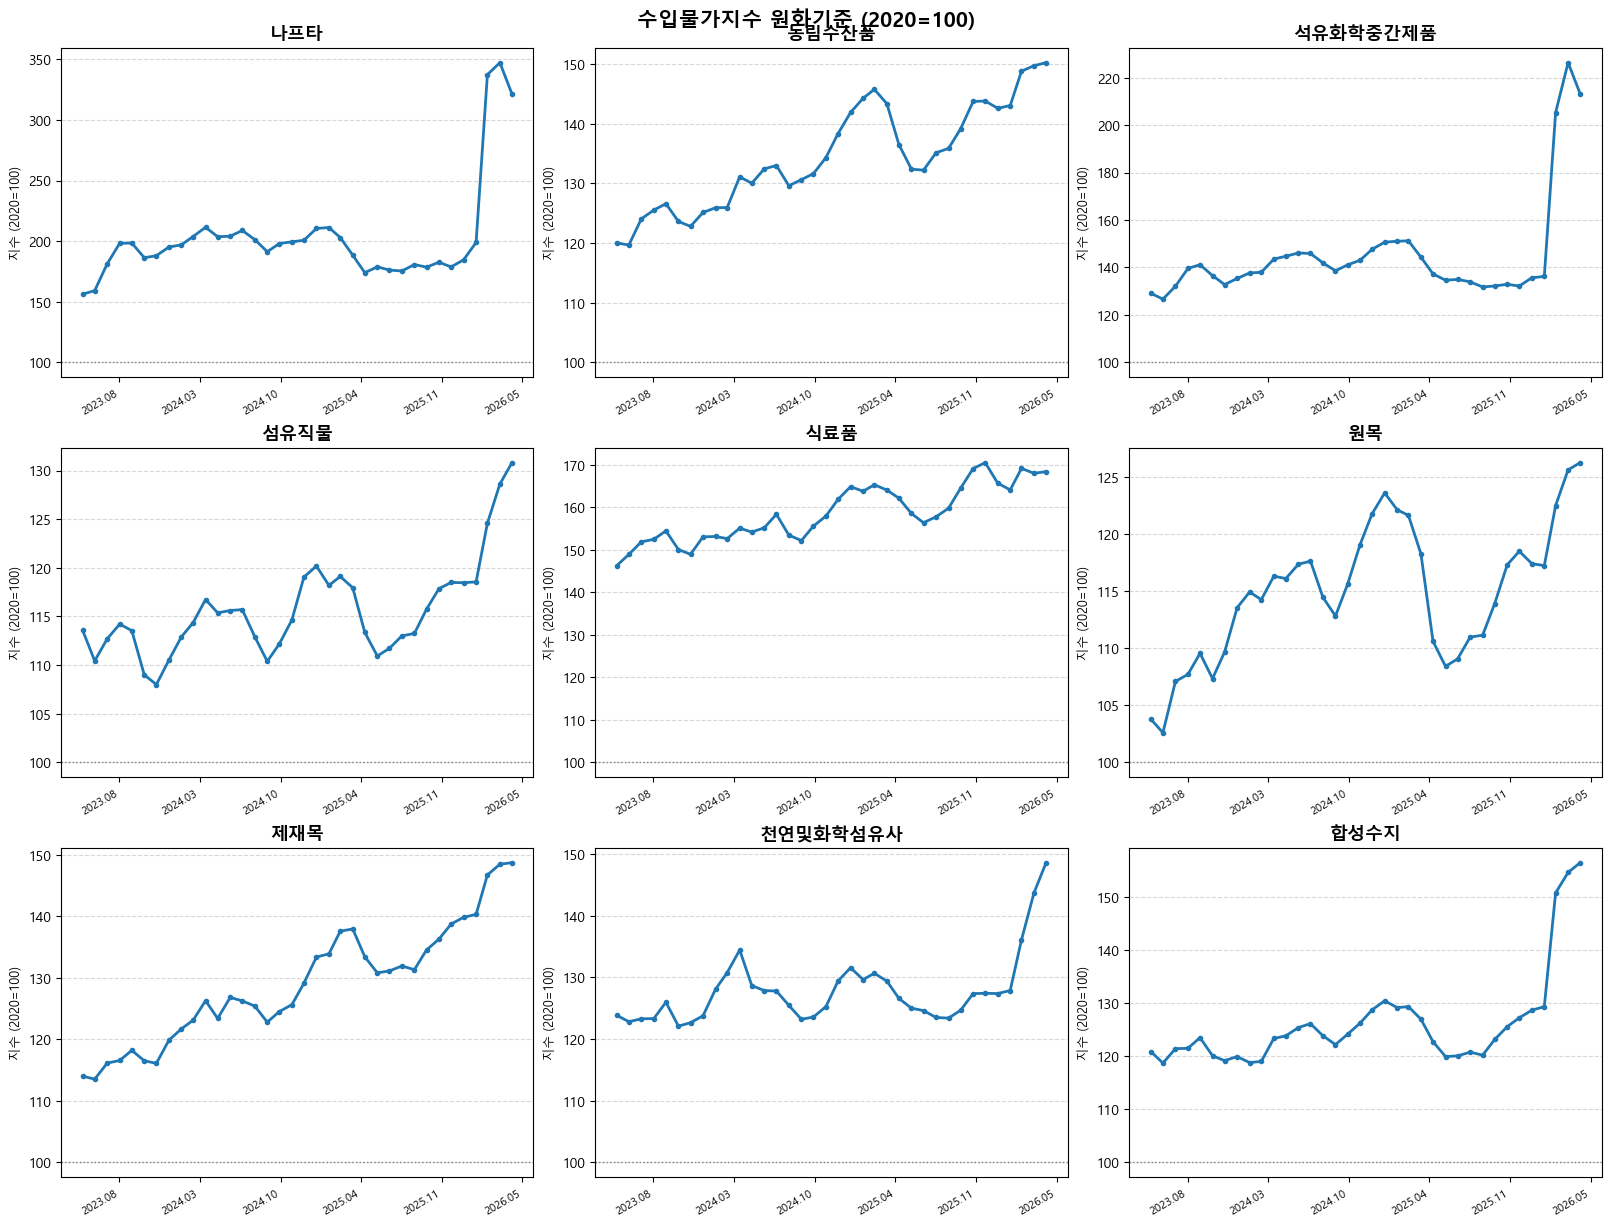

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

rcParams["font.family"] = "Malgun Gothic"
rcParams["axes.unicode_minus"] = False

df_plot = result_clean.copy()
df_plot["날짜"] = pd.to_datetime(df_plot["년월"], format="%Y%m")

items = df_plot["검색어"].unique()
n = len(items)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for i, item in enumerate(items):
    ax = axes[i]
    sub = df_plot[df_plot["검색어"] == item].sort_values("날짜")
    품목명 = sub["품목명"].iloc[0]

    ax.plot(sub["날짜"], sub["수치값"], linewidth=2, marker="o", markersize=3)
    ax.set_title(f"{품목명}", fontsize=13, fontweight="bold")
    ax.set_ylabel("지수 (2020=100)", fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y.%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.axhline(100, color="gray", linestyle=":", linewidth=1)

# 남는 빈 subplot 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("수입물가지수 원화기준 (2020=100)", fontsize=15, fontweight="bold", y=1.01)
plt.show()


## 4. 열연코일, 철근, 철스크랩

In [ ]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

SERVICE_KEY = os.getenv("DATA_GO_KR_KEY", "").strip()

if not SERVICE_KEY:
    raise RuntimeError("환경변수 DATA_GO_KR_KEY가 비어 있습니다.")


# ============================================================
# 1. 공공데이터포털 ODCLOUD API 공통 수집 함수
# ============================================================
def fetch_odcloud_all(url, service_key, per_page=1000):
    all_rows = []
    page = 1

    while True:
        params = {
            "page": page,
            "perPage": per_page,
            "serviceKey": service_key,
            "returnType": "JSON",
        }

        r = requests.get(url, params=params, timeout=30)

        try:
            data = r.json()
        except Exception:
            raise RuntimeError(
                f"JSON 파싱 실패\n"
                f"status={r.status_code}\n"
                f"url={r.url}\n"
                f"text={r.text[:500]}"
            )

        if r.status_code != 200:
            raise RuntimeError(
                f"API 호출 실패\n"
                f"status={r.status_code}\n"
                f"url={r.url}\n"
                f"response={data}"
            )

        rows = data.get("data", [])
        all_rows.extend(rows)

        total_count = data.get("totalCount", 0)

        if len(all_rows) >= total_count or not rows:
            break

        page += 1

    return pd.DataFrame(all_rows)


# ============================================================
# 2. 철근 / 철스크랩 / 열연 / 후판 / 냉연
#    산업통상부_철강원자재 가격동향
# ============================================================

STEEL_URL = (
    "https://api.odcloud.kr/api/3039951/v1/"
    "uddi:b6699de8-3b19-4ab7-8ed7-894636ad6c6d_202004071625"
)

steel_df = fetch_odcloud_all(STEEL_URL, SERVICE_KEY)

print("철강 데이터 컬럼:")
print(steel_df.columns.tolist())
print(steel_df.head())


# 날짜 처리
steel_df["기간"] = pd.to_datetime(steel_df["기간"], format="%Y-%m", errors="coerce")

# 숫자 변환
numeric_cols = [
    "철광석(달러_톤)",
    "유연탄(달러_톤)",
    "철스크랩(달러_톤)",
    "철스크랩(엔_톤)",
    "철근(천원_톤)",
    "열연(천원_톤)",
    "후판(천원_톤)",
    "냉연(천원_톤)",
]

for col in numeric_cols:
    if col in steel_df.columns:
        steel_df[col] = pd.to_numeric(steel_df[col], errors="coerce")

# 최신 데이터 기준 6년치
max_date = steel_df["기간"].max()
start_date = max_date - pd.DateOffset(years=6)

steel_6y = steel_df[
    (steel_df["기간"] >= start_date) &
    (steel_df["기간"] <= max_date)
].copy()

# 철근/열연/후판/냉연은 천원/톤 → 원/톤 변환
for col in ["철근(천원_톤)", "열연(천원_톤)", "후판(천원_톤)", "냉연(천원_톤)"]:
    if col in steel_6y.columns:
        new_col = col.replace("(천원_톤)", "(원_톤)")
        steel_6y[new_col] = steel_6y[col] * 1000

# 필요한 컬럼만 정리
steel_result = steel_6y[
    [
        "기간",
        "철스크랩(달러_톤)",
        "철스크랩(엔_톤)",
        "철근(천원_톤)",
        "철근(원_톤)",
        "열연(천원_톤)",
        "열연(원_톤)",
        "후판(천원_톤)",
        "후판(원_톤)",
        "냉연(천원_톤)",
        "냉연(원_톤)",
    ]
].sort_values("기간")

print("철강 원자재 6년치:")
display(steel_result)

steel_result.to_csv(
    "steel_raw_material_price_6y.csv",
    index=False,
    encoding="utf-8-sig"
)

철강 데이터 컬럼:
['기간', '냉연(천원_톤)', '열연(천원_톤)', '유연탄(달러_톤)', '철광석(달러_톤)', '철근(천원_톤)', '철스크랩(달러_톤)', '철스크랩(엔_톤)', '후판(천원_톤)']
        기간  냉연(천원_톤)  열연(천원_톤)  유연탄(달러_톤)  철광석(달러_톤)  철근(천원_톤)  철스크랩(달러_톤)  \
0  2025-12       850       810        199        104       661         320   
1  2025-11       850       820        195        105       658         308   
2  2025-10       850       824        191        106       687         310   
3  2025-09       850       828        194        103       686         312   
4  2025-08       846       824        194        102       699         312   

   철스크랩(엔_톤)  후판(천원_톤)  
0      40300       910  
1      39825       910  
2      37700       920  
3      36700       920  
4      37060       914  
철강 원자재 6년치:


,기간,철스크랩(달러_톤),철스크랩(엔_톤),철근(천원_톤),철근(원_톤),열연(천원_톤),열연(원_톤),후판(천원_톤),후판(원_톤),냉연(천원_톤),냉연(원_톤)
72,2019-12-01,222,22675,539,539000,698,698000,698,698000,710,710000
71,2020-01-01,243,23060,591,591000,702,702000,702,702000,716,716000
70,2020-02-01,236,19575,590,590000,710,710000,710,710000,730,730000
69,2020-03-01,229,18525,596,596000,700,700000,695,695000,740,740000
68,2020-04-01,202,17980,645,645000,675,675000,665,665000,736,736000
...,...,...,...,...,...,...,...,...,...,...,...
4,2025-08-01,312,37060,699,699000,824,824000,914,914000,846,846000
3,2025-09-01,312,36700,686,686000,828,828000,920,920000,850,850000
2,2025-10-01,310,37700,687,687000,824,824000,920,920000,850,850000
1,2025-11-01,308,39825,658,658000,820,820000,910,910000,850,850000


## 5. 관세청 수입단가
원목, 제재목, 합판, MDF, PB

In [ ]:
import os
import time
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from dotenv import load_dotenv
from dateutil.relativedelta import relativedelta
from urllib.parse import urlsplit, urlunsplit, parse_qsl, urlencode


load_dotenv()

SERVICE_KEY = os.getenv("DATA_GO_KR_KEY", "").strip()

if not SERVICE_KEY:
    raise RuntimeError("DATA_GO_KR_KEY가 비어 있습니다. .env 파일을 확인하세요.")

BASE_URL = "http://apis.data.go.kr/1220000/Itemtrade/getItemtradeList"


# ============================================================
# 1. XML 파싱
# ============================================================
def parse_itemtrade_xml(xml_text: str) -> pd.DataFrame:
    xml_text = xml_text.strip()

    if not xml_text.startswith("<"):
        raise RuntimeError(f"XML이 아닌 응답입니다:\n{xml_text[:1000]}")

    root = ET.fromstring(xml_text)

    # 공공데이터포털 인증 오류 처리
    err_msg = root.findtext(".//errMsg")
    return_auth_msg = root.findtext(".//returnAuthMsg")
    return_reason_code = root.findtext(".//returnReasonCode")

    if err_msg or return_auth_msg or return_reason_code:
        raise RuntimeError(
            "공공데이터포털 인증/파라미터 오류 가능성이 있습니다.\n"
            f"errMsg={err_msg}\n"
            f"returnAuthMsg={return_auth_msg}\n"
            f"returnReasonCode={return_reason_code}\n"
            f"response={xml_text[:1000]}"
        )

    result_code = root.findtext(".//resultCode")
    result_msg = root.findtext(".//resultMsg")

    if result_code not in [None, "00"]:
        raise RuntimeError(
            f"API 오류: resultCode={result_code}, resultMsg={result_msg}\n"
            f"response={xml_text[:1000]}"
        )

    items = root.findall(".//item")

    rows = []
    for item in items:
        rows.append({child.tag: child.text for child in item})

    return pd.DataFrame(rows)


# ============================================================
# 2. Itemtrade 단일 기간 조회
# ============================================================
def mask_service_key(url: str) -> str:
    """
    에러 출력 시 serviceKey 노출 방지
    """
    parts = urlsplit(url)
    query_pairs = parse_qsl(parts.query, keep_blank_values=True)

    masked_pairs = []
    for k, v in query_pairs:
        if k.lower() == "servicekey":
            masked_pairs.append((k, "****MASKED****"))
        else:
            masked_pairs.append((k, v))

    masked_query = urlencode(masked_pairs)
    return urlunsplit((parts.scheme, parts.netloc, parts.path, masked_query, parts.fragment))


def get_itemtrade(strt_yymm: str, end_yymm: str, hs_sgn: str) -> pd.DataFrame:
    """
    관세청_품목별 수출입실적(GW) 조회
    """
    params = {
        "serviceKey": SERVICE_KEY,
        "strtYymm": strt_yymm,
        "endYymm": end_yymm,
        "hsSgn": hs_sgn,
    }

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    r = requests.get(
        BASE_URL,
        params=params,
        headers=headers,
        timeout=30
    )

    if r.status_code != 200:
        raise RuntimeError(
            f"HTTP 오류\n"
            f"status={r.status_code}\n"
            f"url={mask_service_key(r.url)}\n"
            f"text={r.text[:1000]}"
        )

    df = parse_itemtrade_xml(r.text)

    if df.empty:
        return df

    numeric_cols = [
        "expWgt",
        "expDlr",
        "impWgt",
        "impDlr",
        "balPayments",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .replace({"None": None, "": None})
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "year" in df.columns:
        df["date"] = pd.to_datetime(df["year"], format="%Y.%m", errors="coerce")

    return df


# ============================================================
# 3. 연도별 반복 조회
# ============================================================
def fetch_itemtrade_by_years(start_year: int, end_year: int, hs_sgn: str) -> pd.DataFrame:
    dfs = []

    for year in range(start_year, end_year + 1):
        strt_yymm = f"{year}01"
        end_yymm = f"{year}12"

        print(f"조회 중: {strt_yymm} ~ {end_yymm}, HS={hs_sgn}")

        df_year = get_itemtrade(
            strt_yymm=strt_yymm,
            end_yymm=end_yymm,
            hs_sgn=hs_sgn,
        )

        if not df_year.empty:
            dfs.append(df_year)

        time.sleep(0.2)

    if not dfs:
        return pd.DataFrame()

    result = pd.concat(dfs, ignore_index=True)

    if "date" in result.columns:
        result = result.sort_values("date").reset_index(drop=True)

    return result


# ============================================================
# 4. 수입단가 계산
# ============================================================
def calc_import_unit_price(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 0으로 나누는 것 방지
    df.loc[df["impWgt"] == 0, "impWgt"] = pd.NA

    # 기본 단가: USD/kg
    df["import_unit_price_usd_per_kg"] = df["impDlr"] / df["impWgt"]

    # 보기 편한 단가: USD/ton
    df["import_unit_price_usd_per_ton"] = df["import_unit_price_usd_per_kg"] * 1000

    return df


# ============================================================
# 5. 품목군별 수집
# ============================================================
TARGET_HS = {
    "원목": "4403",
    "제재목": "4407",
    "PB": "4410",
    "MDF": "4411",
    "합판": "4412",
}

START_YEAR = 2020
END_YEAR = 2025

all_results = []

for item_name, hs_code in TARGET_HS.items():
    print("=" * 80)
    print(f"{item_name} / HS {hs_code}")

    df = fetch_itemtrade_by_years(
        start_year=START_YEAR,
        end_year=END_YEAR,
        hs_sgn=hs_code,
    )

    if df.empty:
        print(f"데이터 없음: {item_name}")
        continue

    df["item_name"] = item_name
    df["query_hs_code"] = hs_code

    df = calc_import_unit_price(df)

    all_results.append(df)

raw_result = pd.concat(all_results, ignore_index=True)

display(raw_result.head())

원목 / HS 4403
조회 중: 202001 ~ 202012, HS=4403
조회 중: 202101 ~ 202112, HS=4403
조회 중: 202201 ~ 202212, HS=4403
조회 중: 202301 ~ 202312, HS=4403
조회 중: 202401 ~ 202412, HS=4403
조회 중: 202501 ~ 202512, HS=4403
제재목 / HS 4407
조회 중: 202001 ~ 202012, HS=4407
조회 중: 202101 ~ 202112, HS=4407
조회 중: 202201 ~ 202212, HS=4407
조회 중: 202301 ~ 202312, HS=4407
조회 중: 202401 ~ 202412, HS=4407
조회 중: 202501 ~ 202512, HS=4407
PB / HS 4410
조회 중: 202001 ~ 202012, HS=4410
조회 중: 202101 ~ 202112, HS=4410
조회 중: 202201 ~ 202212, HS=4410
조회 중: 202301 ~ 202312, HS=4410
조회 중: 202401 ~ 202412, HS=4410
조회 중: 202501 ~ 202512, HS=4410
MDF / HS 4411
조회 중: 202001 ~ 202012, HS=4411
조회 중: 202101 ~ 202112, HS=4411
조회 중: 202201 ~ 202212, HS=4411
조회 중: 202301 ~ 202312, HS=4411
조회 중: 202401 ~ 202412, HS=4411
조회 중: 202501 ~ 202512, HS=4411
합판 / HS 4412
조회 중: 202001 ~ 202012, HS=4412
조회 중: 202101 ~ 202112, HS=4412
조회 중: 202201 ~ 202212, HS=4412
조회 중: 202301 ~ 202312, HS=4412
조회 중: 202401 ~ 202412, HS=4412
조회 중: 202501 ~ 202512, HS=4412


,balPayments,expDlr,expWgt,hsCode,impDlr,impWgt,statKor,year,date,item_name,query_hs_code,import_unit_price_usd_per_kg,import_unit_price_usd_per_ton
0,9824,9824,176,4403121000,0,NaN,열대산 목재,2020.01,2020-01-01,원목,4403,NaN,NaN
1,-757262,0,0,4403999000,757262,2146439.0,기타,2020.01,2020-01-01,원목,4403,0.352799,352.799218
2,-94855,0,0,4403993030,94855,115736.0,단풍나무,2020.01,2020-01-01,원목,4403,0.819581,819.580770
3,-152579,0,0,4403991050,152579,132598.0,호두나무,2020.01,2020-01-01,원목,4403,1.150689,1150.688547
4,-106766,0,0,4403991040,106766,141740.0,물푸레나무,2020.01,2020-01-01,원목,4403,0.753252,753.252434


### 원목에서 여러 나무로 분류되므로 하나로 통합
원목 월별 수입단가 = 원목 전체 수입금액 합계 / 원목 전체 수입 중량 합계 (가중평균)

In [2]:
import pandas as pd

# 수입중량/수입금액 숫자 보정
for col in ["impWgt", "impDlr", "expWgt", "expDlr"]:
    if col in raw_result.columns:
        raw_result[col] = (
            raw_result[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .replace({"None": None, "": None, "nan": None})
        )
        raw_result[col] = pd.to_numeric(raw_result[col], errors="coerce")

# 0 중량 제거 또는 결측 처리
raw_result.loc[raw_result["impWgt"] == 0, "impWgt"] = pd.NA

# item_name + 월 기준으로 합산
monthly_item_price = (
    raw_result
    .groupby(["item_name", "query_hs_code", "date"], as_index=False)
    .agg(
        import_weight_kg=("impWgt", "sum"),
        import_value_usd=("impDlr", "sum"),
        export_weight_kg=("expWgt", "sum"),
        export_value_usd=("expDlr", "sum"),
        hs_detail_count=("statKor", "nunique"),
    )
)

# 수입단가 계산
monthly_item_price["import_unit_price_usd_per_kg"] = (
    monthly_item_price["import_value_usd"] / monthly_item_price["import_weight_kg"]
)

monthly_item_price["import_unit_price_usd_per_ton"] = (
    monthly_item_price["import_unit_price_usd_per_kg"] * 1000
)

monthly_item_price = monthly_item_price.sort_values(
    ["item_name", "date"]
).reset_index(drop=True)

display(monthly_item_price)

,item_name,query_hs_code,date,import_weight_kg,import_value_usd,export_weight_kg,export_value_usd,hs_detail_count,import_unit_price_usd_per_kg,import_unit_price_usd_per_ton
0,MDF,4411,2020-01-01,11965365.0,4573024,1314700,927456,3,0.382188,382.188425
1,MDF,4411,2020-02-01,12020922.0,4781580,2385428,1618957,3,0.397771,397.771485
2,MDF,4411,2020-03-01,14654700.0,4853903,2067707,1261567,3,0.331218,331.218176
3,MDF,4411,2020-04-01,15058064.0,5277297,1776571,1035332,3,0.350463,350.463180
4,MDF,4411,2020-05-01,16090881.0,6283822,1620430,888526,3,0.390521,390.520693
...,...,...,...,...,...,...,...,...,...,...
355,합판,4412,2025-08-01,68532121.0,52236359,212999,331839,16,0.762217,762.217165
356,합판,4412,2025-09-01,71041414.0,54290461,283217,504809,17,0.764209,764.208621
357,합판,4412,2025-10-01,63185898.0,51993040,107622,215464,15,0.822858,822.858290
358,합판,4412,2025-11-01,65254948.0,54602772,105764,236893,15,0.836761,836.760639


## 6. 축산 수집 (6년치)

**API**: consumerPriceMonth (축산물유통정보, SC-OA-21-02)  
**수집 항목**: 한우, 돼지, 닭(닭고기/kg), 계란(특란), 흰우유  
**judgeKind 코드**: 한우=4301, 돼지=4304, 닭=9901, 계란=9903, 우유=9908  
> ※ 닭(10호)은 해당 API에서 10호 규격 별도 데이터 미제공 → kg당 소비자가격으로 대체 수집

In [ ]:
"""
축산물품질평가원 소비자가격 월별 데이터 수집 (6년치)
API: consumerPriceMonth
항목: 한우, 돼지, 닭(닭고기/kg, 10호 해당 없음 → kg 단가), 계란(특란), 흰우유
"""

import os
import time
import datetime
import requests
import xml.etree.ElementTree as ET
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
SERVICE_KEY = os.environ.get("DATA_GO_KR_KEY", "")

BASE_URL = "http://data.ekape.or.kr/openapi-data/service/user/grade/consumerPriceMonth"

# judgeKind 코드 (축종코드)
JUDGE_KINDS = {
    "한우": "4301",
    "돼지": "4304",
    "닭":   "9901",
    "계란": "9903",
    "우유": "9908",
}

# 응답 itemNm에 포함된 문자열로 필터 (None이면 전체 수집)
TARGET_ITEM_FILTER = {
    "한우": None,
    "돼지": None,
    "닭":   None,    # 닭고기(kg) 1개만 존재
    "계란": "특란",  # 특란10개, 특란30개
    "우유": None,    # 흰우유 1개만 존재
}


def month_range(start_ym: str, end_ym: str):
    """YYYYMM 형식의 시작~끝 월 목록 생성."""
    y, m = int(start_ym[:4]), int(start_ym[4:])
    ey, em = int(end_ym[:4]), int(end_ym[4:])
    while (y, m) <= (ey, em):
        yield f"{y}{m:02d}"
        m += 1
        if m > 12:
            m = 1
            y += 1


def fetch_month(stand_ym: str, judge_kind: str) -> list:
    """단일 월, 단일 축종 데이터를 API에서 가져온다."""
    params = {
        "serviceKey": SERVICE_KEY,
        "standYm":    stand_ym,
        "judgeKind":  judge_kind,
        "numOfRows":  "100",
        "pageNo":     "1",
    }
    try:
        resp = requests.get(BASE_URL, params=params, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"  [ERROR] {stand_ym} / judgeKind={judge_kind}: {e}")
        return []

    try:
        root = ET.fromstring(resp.content.decode("utf-8"))
    except ET.ParseError as e:
        print(f"  [XML ERROR] {stand_ym} / judgeKind={judge_kind}: {e}")
        return []

    result_code = root.findtext(".//resultCode", "")
    if result_code != "00":
        result_msg = root.findtext(".//resultMsg", "")
        print(f"  [API ERROR] {stand_ym} judgeKind={judge_kind}: {result_code} {result_msg}")
        return []

    rows = []
    for item in root.findall(".//item"):
        row = {child.tag: (child.text or "").strip() for child in item}
        rows.append(row)
    return rows


def collect_all(start_ym: str, end_ym: str) -> dict:
    months = list(month_range(start_ym, end_ym))
    total = len(months) * len(JUDGE_KINDS)
    done = 0
    results = {name: [] for name in JUDGE_KINDS}

    for name, jk in JUDGE_KINDS.items():
        item_filter = TARGET_ITEM_FILTER[name]
        print(f"[{name}] judgeKind={jk}, 품목필터={item_filter or '전체'}")
        for ym in months:
            rows = fetch_month(ym, jk)
            if item_filter:
                rows = [r for r in rows if item_filter in (r.get("itemNm") or "")]
            for r in rows:
                r["standYm"] = ym
                r["category"] = name
            results[name].extend(rows)
            done += 1
            if done % 20 == 0:
                print(f"  진행: {done}/{total}")
            time.sleep(0.2)

    dfs = {}
    for name, rows in results.items():
        if rows:
            df = pd.DataFrame(rows)
            cols = ["standYm", "category"] + [c for c in df.columns if c not in ("standYm", "category")]
            dfs[name] = df[cols]
        else:
            print(f"  [WARNING] {name}: 데이터 없음")
            dfs[name] = pd.DataFrame()
    return dfs


# 6년치 수집
today = datetime.date.today()
end_ym = today.strftime("%Y%m")
start_ym = f"{today.year - 6}{today.month:02d}"
print(f"수집 기간: {start_ym} ~ {end_ym}  ({len(list(month_range(start_ym, end_ym)))}개월)")

dfs = collect_all(start_ym, end_ym)

# Excel 저장
output_path = "livestock_prices_monthly.xlsx"
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for name, df in dfs.items():
        if not df.empty:
            df.to_excel(writer, sheet_name=name, index=False)
print(f"저장 완료: {output_path}")

# 결과 미리보기
for name, df in dfs.items():
    if not df.empty:
        print(f"[{name}] {len(df)}건")
        display(df.head(3))

수집 기간: 202006 ~ 202606  (73개월)
[한우] judgeKind=4301, 품목필터=전체
  진행: 20/365
  진행: 40/365
  진행: 60/365
[돼지] judgeKind=4304, 품목필터=전체
  진행: 80/365
  진행: 100/365
  진행: 120/365
  진행: 140/365
[닭] judgeKind=9901, 품목필터=전체
  진행: 160/365
  진행: 180/365
  진행: 200/365
[계란] judgeKind=9903, 품목필터=특란
  진행: 220/365
  진행: 240/365
  진행: 260/365
  진행: 280/365
[우유] judgeKind=9908, 품목필터=전체
  진행: 300/365
  진행: 320/365
  진행: 340/365
  진행: 360/365
저장 완료: livestock_prices_monthly.xlsx
[한우] 711건


,standYm,category,avgYearPrc,grdNm,itemCd,itemNm,judgeKind,judgeKindNm,ntslPrc,unit
0,202006,한우,11388,1+등급,21,안심,4301,소,13458,원/100g
1,202006,한우,10252,1등급,21,안심,4301,소,12073,원/100g
2,202006,한우,10267,1+등급,22,등심,4301,소,11688,원/100g


[돼지] 292건


,standYm,category,avgYearPrc,grdNm,itemCd,itemNm,judgeKind,judgeKindNm,ntslPrc,unit
0,202006,돼지,1165,00,25,앞다리,4304,돼지,1146,원/100g
1,202006,돼지,2137,00,27,삼겹살,4304,돼지,2382,원/100g
2,202006,돼지,1226,00,28,갈비,4304,돼지,1155,원/100g


[닭] 73건


,standYm,category,avgYearPrc,grdNm,itemCd,itemNm,judgeKind,judgeKindNm,ntslPrc,unit
0,202006,닭,5342,00,99,육계(kg),9901,닭,5052,원/Kg
1,202007,닭,5197,00,99,육계(kg),9901,닭,4977,원/Kg
2,202008,닭,5204,00,99,육계(kg),9901,닭,5080,원/Kg


[계란] 127건


,standYm,category,avgYearPrc,grdNm,itemCd,itemNm,judgeKind,judgeKindNm,ntslPrc,unit
0,202006,계란,5394,일반란,23,특란30구,9903,계란,5145,원/30구
1,202007,계란,5385,일반란,23,특란30구,9903,계란,5160,원/30구
2,202008,계란,5352,일반란,23,특란30구,9903,계란,5229,원/30구


[우유] 73건


,standYm,category,avgYearPrc,grdNm,itemCd,itemNm,judgeKind,judgeKindNm,ntslPrc,unit
0,202006,우유,2541,00,01,흰우유,9908,우유,2597,원/1L
1,202007,우유,2541,00,01,흰우유,9908,우유,2557,원/1L
2,202008,우유,2554,00,01,흰우유,9908,우유,2567,원/1L


한우: 5가지 부위(안심/등심/설도/양지/갈비) × 2개 등급(1+/1등급) = 월 10행

돼지: 4가지 부위(앞다리/삼겹살/갈비/목살) = 월 4행

닭: 닭고기(kg) = 월 1행

계란: 특란10개, 특란30개 = 월 2행

우유: 흰우유 = 월 1행

## 7. 산지 쌀 가격

### KOSIS API 불러오기

In [3]:
# pip install pandas requests python-dotenv

import os
import re
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
assert KOSIS_API_KEY, ".env에 KOSIS_API_KEY를 넣어주세요."

BASE_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"

ORG_ID = "101"
TBL_ID = "DT_1EI10122"   # 정곡(일반계, 20kg, 비추정평균가격)

params = {
    "method": "getList",
    "apiKey": KOSIS_API_KEY,
    "orgId": ORG_ID,
    "tblId": TBL_ID,
    "itmId": "ALL",
    "objL1": "ALL",        # 기준일: 5일, 15일, 25일
    "prdSe": "M",          # 월 자료
    "newEstPrdCnt": 72,    # 최근 72개월 = 6년
    "format": "json",
    "jsonVD": "Y",
}

res = requests.get(BASE_URL, params=params, timeout=30)

print("status_code:", res.status_code)
print("url:", res.url)
print(res.text[:500])

res.raise_for_status()

data = res.json()

if isinstance(data, dict):
    raise ValueError(f"KOSIS 오류 응답: {data}")

raw_df = pd.DataFrame(data)

print(raw_df.shape)
display(raw_df.head())
display(raw_df.columns)

status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&orgId=101&tblId=DT_1EI10122&itmId=ALL&objL1=ALL&prdSe=M&newEstPrdCnt=72&format=json&jsonVD=Y
[{"C1_OBJ_NM":"기준일","DT":"47082","C1":"10","PRD_SE":"M","UNIT_NM_ENG":"WON","ITM_ID":"T10","TBL_ID":"DT_1EI10122","ITM_NM":"금회가격(A)","TBL_NM":"정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~","PRD_DE":"202007","LST_CHN_DE":"2022-10-03","C1_NM_ENG":"5th","C1_NM":"5일","UNIT_NM":"원","ITM_NM_ENG":"The price of this period","ORG_ID":"101","C1_OBJ_NM_ENG":"Fixed date"},{"C1_OBJ_NM":"기준일","DT":"47258","C1":"10","PRD_SE":"M","UNIT_NM_ENG":"WON","ITM_ID":"T10","TBL_ID":"DT_1EI10122","ITM_NM":"금회가격(A)","TBL_NM":"정곡(일반계 2
(860, 17)


,C1_OBJ_NM,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,ORG_ID,C1_OBJ_NM_ENG
0,기준일,47082,10,M,WON,T10,DT_1EI10122,금회가격(A),정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~,202007,2022-10-03,5th,5일,원,The price of this period,101,Fixed date
1,기준일,47258,10,M,WON,T10,DT_1EI10122,금회가격(A),정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~,202008,2022-10-03,5th,5일,원,The price of this period,101,Fixed date
2,기준일,47666,10,M,WON,T10,DT_1EI10122,금회가격(A),정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~,202009,2022-10-03,5th,5일,원,The price of this period,101,Fixed date
3,기준일,53806,10,M,WON,T10,DT_1EI10122,금회가격(A),정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~,202010,2022-10-03,5th,5일,원,The price of this period,101,Fixed date
4,기준일,53187,10,M,WON,T10,DT_1EI10122,금회가격(A),정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~,202011,2022-10-03,5th,5일,원,The price of this period,101,Fixed date


Index(['C1_OBJ_NM', 'DT', 'C1', 'PRD_SE', 'UNIT_NM_ENG', 'ITM_ID', 'TBL_ID',
       'ITM_NM', 'TBL_NM', 'PRD_DE', 'LST_CHN_DE', 'C1_NM_ENG', 'C1_NM',
       'UNIT_NM', 'ITM_NM_ENG', 'ORG_ID', 'C1_OBJ_NM_ENG'],
      dtype='str')

### 컬럼 정리

In [4]:
for col in raw_df.columns:
    if col.endswith("_NM") or col in ["ITM_NM", "PRD_DE", "DT", "UNIT_NM"]:
        print(f"\n[{col}]")
        print(raw_df[col].dropna().unique()[:30])


[C1_OBJ_NM]
<ArrowStringArray>
['기준일']
Length: 1, dtype: str

[DT]
<ArrowStringArray>
['47082', '47258', '47666', '53806', '53187', '53821', '54031', '54244',
 '54680', '55197', '55290', '55331', '55330', '55139', '53881', '55064',
 '52482', '51331', '49678', '49391', '48617', '46727', '45423', '44292',
 '43218', '41402', '39321', '44734', '45781', '45490']
Length: 30, dtype: str

[ITM_NM]
<ArrowStringArray>
['금회가격(A)', '전회가격(B)', '가격차이(A-B)', '전회대비(%)']
Length: 4, dtype: str

[TBL_NM]
<ArrowStringArray>
['정곡(일반계 20kg 비추정평균가격) 월 2017.4 ~']
Length: 1, dtype: str

[PRD_DE]
<ArrowStringArray>
['202007', '202008', '202009', '202010', '202011', '202012', '202101',
 '202102', '202103', '202104', '202105', '202106', '202107', '202108',
 '202109', '202110', '202111', '202112', '202201', '202202', '202203',
 '202204', '202205', '202206', '202207', '202208', '202209', '202210',
 '202211', '202212']
Length: 30, dtype: str

[C1_NM]
<ArrowStringArray>
['5일', '15일', '25일']
Length: 3, dtype: str

[U

In [5]:
df = raw_df.copy()

# 값 숫자화
df["value"] = (
    df["DT"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["value"] = pd.to_numeric(df["value"], errors="coerce")

# 기준일 컬럼 자동 탐색: 5일, 15일, 25일이 들어있는 컬럼
name_cols = [c for c in df.columns if c.endswith("_NM") or c == "ITM_NM"]

day_col = None
for col in name_cols:
    s = df[col].astype(str).str.strip()
    if s.str.match(r"^(5|15|25)일$").any():
        day_col = col
        break

print("기준일 컬럼:", day_col)

if day_col is None:
    raise ValueError("5일/15일/25일 컬럼을 찾지 못했습니다. 위 unique 출력 결과를 확인하세요.")

# 항목 컬럼은 보통 ITM_NM
item_col = "ITM_NM"

# long → wide
wide_df = (
    df.pivot_table(
        index=["PRD_DE", day_col],
        columns=item_col,
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

wide_df.columns.name = None
wide_df = wide_df.rename(columns={day_col: "기준일"})

# 날짜 생성: PRD_DE + 기준일
ym = (
    wide_df["PRD_DE"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str[:6]
)

day_num = (
    wide_df["기준일"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .str.zfill(2)
)

wide_df["date"] = pd.to_datetime(ym + day_num, format="%Y%m%d", errors="coerce")

# 보기 좋은 순서
front_cols = ["date", "PRD_DE", "기준일"]
other_cols = [c for c in wide_df.columns if c not in front_cols]

wide_df = wide_df[front_cols + other_cols]
wide_df = wide_df.sort_values(["date"]).reset_index(drop=True)

display(wide_df.head(20))
display(wide_df.tail(20))

기준일 컬럼: C1_NM


,date,PRD_DE,기준일,가격차이(A-B),금회가격(A),전회가격(B),전회대비(%)
0,2020-07-05,202007,5일,-56.0,47082.0,47138.0,-0.1
1,2020-07-15,202007,15일,101.0,47183.0,47082.0,0.2
2,2020-07-25,202007,25일,4.0,47187.0,47183.0,0.0
3,2020-08-05,202008,5일,71.0,47258.0,47187.0,0.2
4,2020-08-15,202008,15일,45.0,47304.0,47258.0,0.1
5,2020-08-25,202008,25일,200.0,47504.0,47304.0,0.4
6,2020-09-05,202009,5일,162.0,47666.0,47504.0,0.3
7,2020-09-15,202009,15일,115.0,47780.0,47666.0,0.2
8,2020-09-25,202009,25일,228.0,48008.0,47780.0,0.5
9,2020-10-05,202010,5일,5798.0,53806.0,48008.0,12.1


,date,PRD_DE,기준일,가격차이(A-B),금회가격(A),전회가격(B),전회대비(%)
195,2025-12-05,202512,5일,-72.0,56974.0,57046.0,-0.100
196,2025-12-15,202512,15일,67.0,57041.0,56974.0,0.100
197,2025-12-25,202512,25일,-87.0,56954.0,57041.0,-0.200
198,2026-01-05,202601,5일,151.0,57105.0,56954.0,0.300
199,2026-01-15,202601,15일,152.0,57257.0,57105.0,0.300
200,2026-01-25,202601,25일,75.0,57332.0,57257.0,0.100
201,2026-02-05,202602,5일,226.0,57558.0,57332.0,0.400
202,2026-02-15,202602,15일,72.0,57630.0,57558.0,0.100
203,2026-02-25,202602,25일,57.0,57687.0,57630.0,0.100
204,2026-03-05,202603,5일,29.0,57716.0,57687.0,0.100


### 당시 가격만 필요하므로 금회가격 조회

In [6]:
rice_price_df = wide_df[["date", "PRD_DE", "기준일", "금회가격(A)"]].copy()
rice_price_df = rice_price_df.rename(columns={"금회가격(A)": "산지쌀가격_원_20kg"})

display(rice_price_df.head())
display(rice_price_df.tail())

,date,PRD_DE,기준일,산지쌀가격_원_20kg
0,2020-07-05,202007,5일,47082.0
1,2020-07-15,202007,15일,47183.0
2,2020-07-25,202007,25일,47187.0
3,2020-08-05,202008,5일,47258.0
4,2020-08-15,202008,15일,47304.0


,date,PRD_DE,기준일,산지쌀가격_원_20kg
210,2026-05-05,202605,5일,57305.0
211,2026-05-15,202605,15일,57271.0
212,2026-05-25,202605,25일,57243.0
213,2026-06-05,202606,5일,57164.0
214,2026-06-15,202606,15일,57167.0


In [8]:
pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 9.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   ---------------------------------------- 0/4 [peewee]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   -------------------- ------------------- 2/4 [curl_cffi]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --------- 3/4 [yfinance]
   ------------------------------ --

## 8. yfinance 6년치 일별 데이터 수집

'바로 사용 가능'으로 확정한 **15개 지표**를 6년치(실행일 기준) 일별로 수집합니다.

| 그룹 | 지표 |
|------|------|
| 에너지 | WTI유가, 브렌트유, 천연가스 |
| 금속 | 구리(전기동) |
| 곡물/유지/당 | 밀, 옥수수, 대두, 대두유, 설탕(원당), 커피 |
| 환율/지수/금리 | 달러인덱스, 원달러환율, 원유로환율, KOSPI, 미국국채10년 |

In [14]:
from datetime import date
from dateutil.relativedelta import relativedelta
import pandas as pd
import yfinance as yf

# 수집 대상: {한글 지표명: 야후 티커}
TICKERS = {
    "WTI유가":      "CL=F",
    "브렌트유":     "BZ=F",
    "천연가스":     "NG=F",
    "구리(전기동)": "HG=F",
    "밀":           "ZW=F",
    "옥수수":       "ZC=F",
    "대두":         "ZS=F",
    "대두유":       "ZL=F",
    "설탕(원당)":   "SB=F",
    "커피":         "KC=F",
    "달러인덱스":   "DX-Y.NYB",
    "원달러환율":   "KRW=X",
    "원유로환율":   "EURKRW=X",
    "KOSPI":        "^KS11",
    "미국국채10년": "^TNX",
}

# 기간: 실행일 기준 6년
END = date.today()
START = END - relativedelta(years=6)
OUT_CSV = "market_prices_6y.csv"

print(f"기간: {START} ~ {END}  /  대상 {len(TICKERS)}종")

기간: 2020-06-29 ~ 2026-06-29  /  대상 15종


In [15]:
symbols = list(TICKERS.values())

raw = yf.download(
    symbols,
    start=START.isoformat(),
    end=END.isoformat(),
    interval="1d",
    auto_adjust=False,   # 원본 Close 유지
    group_by="column",
    progress=True,
    threads=True,
)

# 종가만 추출 (단일/복수 티커 모두 대응)
if isinstance(raw.columns, pd.MultiIndex):
    close = raw["Close"].copy()
else:
    close = raw[["Close"]].copy()
    close.columns = symbols

# 티커 -> 한글명, 정의 순서대로 정렬
sym2name = {v: k for k, v in TICKERS.items()}
close = close.rename(columns=sym2name)
close = close[[n for n in TICKERS if n in close.columns]]
close.index.name = "날짜"

close.tail()

[*********************100%***********************]  15 of 15 completed


Ticker,WTI유가,브렌트유,천연가스,구리(전기동),밀,옥수수,대두,대두유,설탕(원당),커피,달러인덱스,원달러환율,원유로환율,KOSPI,미국국채10년
날짜,,,,,,,,,,,,,,,
2026-06-23,73.209999,77.080002,3.147,6.1410,586.75,409.75,1117.00,70.589996,13.42,287.950012,101.410004,1539.050049,1752.540039,8203.839844,4.493
2026-06-24,70.339996,73.739998,3.221,5.9430,585.75,407.00,1108.75,69.459999,13.42,291.549988,101.610001,1535.250000,1740.569946,8471.019531,4.402
2026-06-25,71.919998,75.260002,3.343,6.0705,591.00,414.75,1127.50,70.809998,13.55,288.799988,101.430000,1542.760010,1747.219971,8930.299805,4.392
2026-06-26,69.230003,71.989998,3.231,6.1415,578.25,412.75,1126.25,71.300003,14.55,261.250000,101.360001,1546.479980,1754.180054,8411.209961,4.372
2026-06-28,70.000000,73.260002,3.307,6.1690,589.75,417.50,1149.00,67.339996,NaN,NaN,101.348000,NaN,NaN,NaN,NaN


In [16]:
rows = []
for name in TICKERS:
    if name not in close.columns:
        rows.append((name, 0, None, None)); continue
    s = close[name].dropna()
    if s.empty:
        rows.append((name, 0, None, None))
    else:
        rows.append((name, len(s), s.index.min().date(), s.index.max().date()))

summary = pd.DataFrame(rows, columns=["지표", "행수", "시작", "종료"])
summary

,지표,행수,시작,종료
0,WTI유가,1509,2020-06-29,2026-06-28
1,브렌트유,1510,2020-06-29,2026-06-28
2,천연가스,1510,2020-06-29,2026-06-28
3,구리(전기동),1510,2020-06-29,2026-06-28
4,밀,1508,2020-06-29,2026-06-28
5,옥수수,1508,2020-06-29,2026-06-28
6,대두,1508,2020-06-29,2026-06-28
7,대두유,1508,2020-06-29,2026-06-28
8,설탕(원당),1509,2020-06-29,2026-06-26
9,커피,1509,2020-06-29,2026-06-26


## 9. FAO

In [19]:
# pip install pandas requests beautifulsoup4 python-dotenv

import io
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin

FAO_PAGE = "https://www.fao.org/worldfoodsituation/foodpricesindex/en/"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    ),
    "Accept": "text/csv,application/csv,text/plain,*/*",
    "Referer": FAO_PAGE,
}


def get_fao_food_price_index_csv_url():
    """
    FAO Food Price Index 페이지에서 CSV 다운로드 링크 자동 탐색
    """
    res = requests.get(FAO_PAGE, headers=HEADERS, timeout=30)
    print("page status:", res.status_code)
    res.raise_for_status()

    soup = BeautifulSoup(res.text, "html.parser")

    candidates = []

    for a in soup.find_all("a", href=True):
        href = a["href"]
        text = a.get_text(" ", strip=True)

        if "food_price_indices_data.csv" in href.lower():
            candidates.append(urljoin(FAO_PAGE, href))

        elif "csv" in text.lower() and "nominal" in text.lower():
            candidates.append(urljoin(FAO_PAGE, href))

    if not candidates:
        raise ValueError("FAO 페이지에서 CSV 링크를 찾지 못했습니다.")

    return candidates[0]


def read_fao_csv(csv_url):
    """
    pd.read_csv(url)을 직접 쓰지 않고,
    requests로 먼저 받은 뒤 pandas로 읽기
    """
    res = requests.get(csv_url, headers=HEADERS, timeout=60, allow_redirects=True)

    print("csv status:", res.status_code)
    print("final url:", res.url)
    print("content-type:", res.headers.get("Content-Type"))
    print("preview:", res.text[:200])

    res.raise_for_status()

    # HTML 오류 페이지가 내려오는 경우 방지
    if "<html" in res.text[:500].lower():
        raise ValueError("CSV가 아니라 HTML 페이지가 내려왔습니다. FAO 다운로드 차단 또는 링크 변경 가능성이 있습니다.")

    return pd.read_csv(io.StringIO(res.content.decode("utf-8-sig")))


csv_url = get_fao_food_price_index_csv_url()
print("csv_url:", csv_url)

df = read_fao_csv(csv_url)

print(df.shape)
display(df.head())
display(df.tail())
display(df.columns)

page status: 200
csv_url: https://www.fao.org/media/docs/worldfoodsituationlibraries/default-document-library/food_price_indices_data.csv?sfvrsn=523ebd2a_80&download=true
csv status: 200
final url: https://www.fao.org/media/docs/worldfoodsituationlibraries/default-document-library/food_price_indices_data.csv?sfvrsn=523ebd2a_80&download=true
content-type: text/csv
preview: FAO Food Price Index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-2016=100,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Date,Food Price Index,Meat,Dairy,
(440, 66)


,FAO Food Price Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65
0,2014-2016=100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01,64.4,74.3,53.5,64.1,44.59,87.9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-02,64.7,76.8,52.2,62.2,44.50,90.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,FAO Food Price Index,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65
435,2026-01,124.1,124.9,120.7,107.5,168.6,89.8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
436,2026-02,125.5,126.5,119.4,108.7,174.2,86.2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
437,2026-03,128.7,128.0,121.2,110.4,183.1,92.8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438,2026-04,131.0,130.4,119.7,111.3,193.9,88.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439,2026-05,130.8,130.5,119.2,114.3,185.0,95.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Index(['FAO Food Price Index', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20',
       'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24',
       'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28',
       'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32',
       'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40',
       'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44',
       'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48',
       'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52',
       'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56',
       'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 66 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FAO Food Price Index  439 non-null    str    
 1   Unnamed: 1            438 non-null    str    
 2   Unnamed: 2            438 non-null    str    
 3   Unnamed: 3            438 non-null    str    
 4   Unnamed: 4            438 non-null    str    
 5   Unnamed: 5            438 non-null    str    
 6   Unnamed: 6            438 non-null    str    
 7   Unnamed: 7            0 non-null      float64
 8   Unnamed: 8            0 non-null      float64
 9   Unnamed: 9            0 non-null      float64
 10  Unnamed: 10           0 non-null      float64
 11  Unnamed: 11           0 non-null      float64
 12  Unnamed: 12           0 non-null      float64
 13  Unnamed: 13           0 non-null      float64
 14  Unnamed: 14           0 non-null      float64
 15  Unnamed: 15           0 non-null  

In [21]:
fao_raw = df.copy()

# Sugar까지 필요한 컬럼만 사용: Date, Food Price Index, Meat, Dairy, Cereals, Oils, Sugar
fao = fao_raw.iloc[2:, :7].copy()

# 실제 컬럼명은 원본의 두 번째 행(index=1)에 있음
fao.columns = fao_raw.iloc[1, :7].tolist()

# 빈 행 제거
fao = fao.dropna(subset=["Date"]).reset_index(drop=True)

# 날짜 변환
fao["date"] = pd.to_datetime(fao["Date"], format="%Y-%m", errors="coerce")

# 수치형 변환
value_cols = ["Food Price Index", "Meat", "Dairy", "Cereals", "Oils", "Sugar"]

for col in value_cols:
    fao[col] = pd.to_numeric(fao[col], errors="coerce")

# 컬럼 순서 정리
fao = fao[["date", "Date"] + value_cols]

display(fao.head())
display(fao.tail())
print(fao.info())

,date,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
0,1990-01-01,1990-01,64.4,74.3,53.5,64.1,44.59,87.9
1,1990-02-01,1990-02,64.7,76.8,52.2,62.2,44.50,90.7
2,1990-03-01,1990-03,64.0,78.5,41.4,61.3,45.75,95.1
3,1990-04-01,1990-04,66.0,81.2,48.4,62.8,44.02,94.3
4,1990-05-01,1990-05,64.6,81.8,39.2,62.0,45.50,90.4


,date,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
432,2026-01-01,2026-01,124.1,124.9,120.7,107.5,168.6,89.8
433,2026-02-01,2026-02,125.5,126.5,119.4,108.7,174.2,86.2
434,2026-03-01,2026-03,128.7,128.0,121.2,110.4,183.1,92.8
435,2026-04-01,2026-04,131.0,130.4,119.7,111.3,193.9,88.5
436,2026-05-01,2026-05,130.8,130.5,119.2,114.3,185.0,95.1


<class 'pandas.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              437 non-null    datetime64[us]
 1   Date              437 non-null    str           
 2   Food Price Index  437 non-null    float64       
 3   Meat              437 non-null    float64       
 4   Dairy             437 non-null    float64       
 5   Cereals           437 non-null    float64       
 6   Oils              437 non-null    float64       
 7   Sugar             437 non-null    float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 30.5 KB
None


Food Price Index가 종합 식품가격지수(FAO)

## 10. 기준금리(한,미,중,일,EU)

In [24]:
# pip install pandas requests python-dotenv python-dateutil

import os
import math
import requests
import pandas as pd
from dotenv import load_dotenv
from datetime import date
from dateutil.relativedelta import relativedelta

load_dotenv()

ECOS_API_KEY = os.getenv("ECOS_API_KEY", "").strip()
assert ECOS_API_KEY, ".env에 ECOS_API_KEY를 넣어주세요."

BASE_URL = "https://ecos.bok.or.kr/api/StatisticSearch"

STAT_CODE = "902Y006"   # 국제 주요국 중앙은행 정책금리
CYCLE = "M"             # 월별


def ecos_stat_search(stat_code, cycle, start_time, end_time):
    """
    한국은행 ECOS StatisticSearch 전체 페이지 수집
    """
    # 1차 호출: 전체 개수 확인
    url = (
        f"{BASE_URL}/{ECOS_API_KEY}/json/kr/1/100/"
        f"{stat_code}/{cycle}/{start_time}/{end_time}"
    )

    res = requests.get(url, timeout=30)
    print("first url:", res.url)
    print("status:", res.status_code)
    res.raise_for_status()

    data = res.json()

    if "StatisticSearch" not in data:
        raise ValueError(f"ECOS 오류 응답: {data}")

    total_count = int(data["StatisticSearch"]["list_total_count"])
    print("total_count:", total_count)

    rows = []

    for start_idx in range(1, total_count + 1, 100):
        end_idx = min(start_idx + 99, total_count)

        url = (
            f"{BASE_URL}/{ECOS_API_KEY}/json/kr/{start_idx}/{end_idx}/"
            f"{stat_code}/{cycle}/{start_time}/{end_time}"
        )

        res = requests.get(url, timeout=30)
        res.raise_for_status()

        part = res.json()

        if "StatisticSearch" not in part:
            print("skip error:", part)
            continue

        rows.extend(part["StatisticSearch"].get("row", []))

    return pd.DataFrame(rows)


# 최근 6년치
end = date.today()
start = end - relativedelta(years=6)

start_ym = start.strftime("%Y%m")
end_ym = end.strftime("%Y%m")

raw_df = ecos_stat_search(STAT_CODE, CYCLE, start_ym, end_ym)

print(raw_df.shape)
display(raw_df.head())
display(raw_df.columns)

first url: https://ecos.bok.or.kr/api/StatisticSearch/6N85J5EDL0SNS5MZCJHO/json/kr/1/100/902Y006/M/202006/202606
status: 200
total_count: 1869
(1869, 14)


,STAT_CODE,STAT_NAME,ITEM_CODE1,ITEM_NAME1,ITEM_CODE2,ITEM_NAME2,ITEM_CODE3,ITEM_NAME3,ITEM_CODE4,ITEM_NAME4,UNIT_NAME,WGT,TIME,DATA_VALUE
0,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리,AU,호주,None,None,None,None,None,None,%,None,202006,0.25
1,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리,BR,브라질,None,None,None,None,None,None,%,None,202006,2.25
2,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리,CA,캐나다,None,None,None,None,None,None,%,None,202006,0.25
3,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리,CH,스위스,None,None,None,None,None,None,%,None,202006,-0.75
4,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리,CL,칠레,None,None,None,None,None,None,%,None,202006,0.5


Index(['STAT_CODE', 'STAT_NAME', 'ITEM_CODE1', 'ITEM_NAME1', 'ITEM_CODE2',
       'ITEM_NAME2', 'ITEM_CODE3', 'ITEM_NAME3', 'ITEM_CODE4', 'ITEM_NAME4',
       'UNIT_NAME', 'WGT', 'TIME', 'DATA_VALUE'],
      dtype='str')

In [25]:
print(raw_df["ITEM_NAME1"].dropna().unique())

<ArrowStringArray>
[      '호주',      '브라질',      '캐나다',      '스위스',       '칠레',       '중국',
       '체코',      '덴마크',       '영국',      '헝가리',    '인도네시아',     '이스라엘',
       '인도',    '아이슬란드',       '일본',       '한국',      '멕시코',     '노르웨이',
     '뉴질랜드',      '폴란드',      '러시아',      '스웨덴',     '튀르키예',       '미국',
    '유로 지역', '남아프리카공화국']
Length: 26, dtype: str


In [26]:
df = raw_df.copy()

df["date"] = pd.to_datetime(df["TIME"], format="%Y%m", errors="coerce")
df["value"] = pd.to_numeric(df["DATA_VALUE"], errors="coerce")

target_keywords = {
    "한국": ["한국"],
    "미국": ["미국"],
    "중국": ["중국"],
    "일본": ["일본"],
    "유럽": ["유로지역"],
}


def map_country(item_name):
    item_name = str(item_name)

    for country, keywords in target_keywords.items():
        for keyword in keywords:
            if keyword in item_name:
                return country

    return None


df["country"] = df["ITEM_NAME1"].apply(map_country)

policy_rate_df = (
    df[df["country"].notna()]
    .copy()
    .sort_values(["country", "date"])
    .reset_index(drop=True)
)

policy_rate_df = policy_rate_df[[
    "date",
    "TIME",
    "country",
    "ITEM_NAME1",
    "DATA_VALUE",
    "value",
    "UNIT_NAME",
    "STAT_CODE",
    "STAT_NAME",
]]

display(policy_rate_df.head())
display(policy_rate_df.tail())

,date,TIME,country,ITEM_NAME1,DATA_VALUE,value,UNIT_NAME,STAT_CODE,STAT_NAME
0,2020-06-01,202006,미국,미국,0.125,0.125,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
1,2020-07-01,202007,미국,미국,0.125,0.125,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
2,2020-08-01,202008,미국,미국,0.125,0.125,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
3,2020-09-01,202009,미국,미국,0.125,0.125,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
4,2020-10-01,202010,미국,미국,0.125,0.125,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리


,date,TIME,country,ITEM_NAME1,DATA_VALUE,value,UNIT_NAME,STAT_CODE,STAT_NAME
283,2026-01-01,202601,한국,한국,2.5,2.5,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
284,2026-02-01,202602,한국,한국,2.5,2.5,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
285,2026-03-01,202603,한국,한국,2.5,2.5,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
286,2026-04-01,202604,한국,한국,2.5,2.5,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리
287,2026-05-01,202605,한국,한국,2.5,2.5,%,902Y006,9.1.1.3. 국제 주요국 중앙은행 정책금리


## 11. FOMC 점도표

### 라이브러리 임포트 및 FRED API 설정

필요한 라이브러리를 가져오고, `.env` 파일에서 `FRED_API_KEY`를 불러옵니다.  
FRED(Federal Reserve Economic Data) API 엔드포인트 기본 URL과 SEP Release ID(326)를 상수로 정의하며,  
API 호출을 공통으로 처리하는 `fred_get()` 헬퍼 함수를 정의합니다.

In [42]:
# pip install pandas requests python-dotenv python-dateutil

import os
import re
import requests
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta
from dotenv import load_dotenv
from pathlib import Path

load_dotenv()

FRED_API_KEY = os.getenv("FRED_API_KEY", "").strip()
assert FRED_API_KEY, ".env에 FRED_API_KEY를 넣어주세요."

FRED_BASE = "https://api.stlouisfed.org/fred"
SEP_RELEASE_ID = 326  # Summary of Economic Projections


def fred_get(endpoint, params=None):
    params = params or {}
    params = {
        **params,
        "api_key": FRED_API_KEY,
        "file_type": "json",
    }

    url = f"{FRED_BASE}/{endpoint}"
    res = requests.get(url, params=params, timeout=30)

    print("status:", res.status_code, "|", endpoint)
    res.raise_for_status()

    return res.json()

### FOMC SEP 발표일 수집

`get_sep_release_dates(years=6)` 함수로 최근 N년간 FOMC SEP(Summary of Economic Projections) 공식 발표 날짜 목록을 FRED에서 조회합니다.  
각 발표일이 빈티지(vintage) 기준점이 되어 이후 시계열 데이터 조회에 활용됩니다.

In [43]:
def get_sep_release_dates(years=6):
    end = date.today()
    start = end - relativedelta(years=years)

    data = fred_get(
        "release/dates",
        {
            "release_id": SEP_RELEASE_ID,
            "realtime_start": start.isoformat(),
            "realtime_end": end.isoformat(),
            "limit": 1000,
            "sort_order": "asc",
        }
    )

    dates = pd.DataFrame(data.get("release_dates", []))

    if dates.empty:
        raise ValueError("SEP release date를 찾지 못했습니다.")

    dates["date"] = pd.to_datetime(dates["date"], errors="coerce")
    dates = dates.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    return dates


sep_dates = get_sep_release_dates(years=6)

display(sep_dates)

status: 200 | release/dates


,release_id,date
0,326,2020-09-16
1,326,2020-12-16
2,326,2021-03-17
3,326,2021-06-16
4,326,2021-09-22
5,326,2021-12-15
6,326,2022-03-16
7,326,2022-06-15
8,326,2022-09-21
9,326,2022-12-14


### SEP 관련 시리즈 목록 조회 및 금리 시리즈 필터링

`get_release_series()` 함수로 SEP Release에 포함된 모든 시계열 목록을 페이지네이션으로 수집합니다.  
그 중 제목에 `"Fed Funds Rate"`가 포함된 시리즈만 필터링하여 금리 관련 점도표 시리즈 ID 목록(`fed_rate_series`)을 확보합니다.

In [44]:
def get_release_series(release_id=SEP_RELEASE_ID):
    rows = []
    limit = 1000
    offset = 0

    while True:
        data = fred_get(
            "release/series",
            {
                "release_id": release_id,
                "limit": limit,
                "offset": offset,
                "order_by": "series_id",
                "sort_order": "asc",
            }
        )

        part = data.get("seriess", [])
        rows.extend(part)

        count = int(data.get("count", len(rows)))

        if offset + limit >= count:
            break

        offset += limit

    return pd.DataFrame(rows)


series_df = get_release_series()

fed_rate_series = series_df[
    series_df["title"].str.contains("Fed Funds Rate", case=False, na=False)
].copy()

fed_rate_series = fed_rate_series[
    [
        "id",
        "title",
        "observation_start",
        "observation_end",
        "frequency",
        "units",
        "last_updated",
    ]
].sort_values("title").reset_index(drop=True)

display(fed_rate_series)

status: 200 | release/series


,id,title,observation_start,observation_end,frequency,units,last_updated
0,FEDTARCTH,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:31-05
1,FEDTARCTL,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:30-05
2,FEDTARCTM,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:27-05
3,FEDTARMD,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:27-05
4,FEDTARRH,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:26-05
5,FEDTARRL,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:27-05
6,FEDTARRM,FOMC Summary of Economic Projections for the F...,2026-01-01,2028-01-01,Annual,Percent,2026-06-17 14:09:29-05
7,FEDTARCTHLR,Longer Run FOMC Summary of Economic Projection...,2015-06-17,2026-06-17,Not Applicable,Percent,2026-06-17 14:09:32-05
8,FEDTARCTLLR,Longer Run FOMC Summary of Economic Projection...,2015-06-17,2026-06-17,Not Applicable,Percent,2026-06-17 14:09:27-05
9,FEDTARCTMLR,Longer Run FOMC Summary of Economic Projection...,2015-06-17,2026-06-17,Not Applicable,Percent,2026-06-17 14:09:27-05


### 측정값(measure) 파싱 & Longer Run 판별 함수 정의

시리즈 제목(title)을 읽어 해당 시리즈가 어떤 통계 지표를 나타내는지 파싱합니다.

| 함수 | 역할 |
|------|------|
| `parse_measure(title)` | 제목에서 `median`, `central_tendency_*`, `range_*` 구분 |
| `is_longer_run(title)` | "Longer Run" 포함 여부로 장기 중립금리 시리즈 여부 판별 |

In [45]:
def parse_measure(title):
    title = str(title)

    if "Median" in title:
        return "median"

    if "Central Tendency, Low" in title:
        return "central_tendency_low"

    if "Central Tendency, High" in title:
        return "central_tendency_high"

    if "Central Tendency, Midpoint" in title:
        return "central_tendency_midpoint"

    if "Range, Low" in title:
        return "range_low"

    if "Range, High" in title:
        return "range_high"

    if "Range, Midpoint" in title:
        return "range_midpoint"

    return "unknown"


def is_longer_run(title):
    return "Longer Run" in str(title)

### 빈티지별 관측값 수집 및 전체 데이터 통합

`get_series_observations_by_vintage()` : 특정 시리즈의 특정 발표일(vintage) 시점 관측값을 조회합니다.

`collect_fomc_sep_dot_summary_6y(years=6)` : 위 함수들을 조합해 최근 6년간 모든 SEP 발표일 × 금리 시리즈를 순회하며 데이터를 수집합니다.  
- `projection_period` 파생 : 관측 날짜 연도 → `"2024"`, `"2025"` 등 또는 `"longer_run"`  
- 발표 연도 기준 ±4년 이내 예측 기간만 남겨 불필요한 과거 데이터를 제거합니다.  
- 최종 결과(`fomc_sep_6y`)는 Long 포맷의 DataFrame으로 반환됩니다.

In [46]:
def get_series_observations_by_vintage(series_id, vintage_date):
    data = fred_get(
        "series/observations",
        {
            "series_id": series_id,
            "vintage_dates": vintage_date,
            "sort_order": "asc",
        }
    )

    obs = pd.DataFrame(data.get("observations", []))

    if obs.empty:
        return obs

    obs["series_id"] = series_id
    obs["date"] = pd.to_datetime(obs["date"], errors="coerce")
    obs["value"] = pd.to_numeric(obs["value"].replace(".", pd.NA), errors="coerce")
    obs["realtime_start"] = pd.to_datetime(obs["realtime_start"], errors="coerce")
    obs["realtime_end"] = pd.to_datetime(obs["realtime_end"], errors="coerce")

    return obs


def collect_fomc_sep_dot_summary_6y(years=6):
    sep_dates = get_sep_release_dates(years=years)
    series_df = get_release_series()

    fed_rate_series = series_df[
        series_df["title"].str.contains("Fed Funds Rate", case=False, na=False)
    ].copy()

    rows = []

    for _, drow in sep_dates.iterrows():
        vintage_date = drow["date"].date().isoformat()
        vintage_year = drow["date"].year

        print("\n=== SEP vintage:", vintage_date, "===")

        for _, srow in fed_rate_series.iterrows():
            series_id = srow["id"]
            title = srow["title"]

            measure = parse_measure(title)

            if measure == "unknown":
                continue

            try:
                obs = get_series_observations_by_vintage(
                    series_id=series_id,
                    vintage_date=vintage_date
                )

                if obs.empty:
                    continue

                obs["fomc_release_date"] = vintage_date
                obs["series_title"] = title
                obs["measure"] = measure
                obs["is_longer_run"] = is_longer_run(title)

                rows.append(obs)

            except Exception as e:
                print("[ERROR]", vintage_date, series_id, e)

    if not rows:
        return pd.DataFrame()

    df = pd.concat(rows, ignore_index=True)

    # 값 없는 행 제거
    df = df[df["value"].notna()].copy()

    # projection_period 생성
    df["projection_period"] = df.apply(
        lambda r: "longer_run" if r["is_longer_run"] else str(r["date"].year),
        axis=1
    )

    # 일반 전망연도는 발표연도 이후 몇 년치만 남김
    # 예: 2024년 SEP면 2024, 2025, 2026, 2027 정도
    df["fomc_release_date"] = pd.to_datetime(df["fomc_release_date"])
    df["fomc_year"] = df["fomc_release_date"].dt.year

    def keep_row(r):
        if r["projection_period"] == "longer_run":
            return True

        try:
            target_year = int(r["projection_period"])
        except Exception:
            return False

        return r["fomc_year"] <= target_year <= r["fomc_year"] + 4

    df = df[df.apply(keep_row, axis=1)].copy()

    result = df[
        [
            "fomc_release_date",
            "fomc_year",
            "projection_period",
            "measure",
            "value",
            "series_id",
            "series_title",
            "date",
            "realtime_start",
            "realtime_end",
        ]
    ].sort_values(
        ["fomc_release_date", "projection_period", "measure"]
    ).reset_index(drop=True)

    return result


fomc_sep_6y = collect_fomc_sep_dot_summary_6y(years=6)

display(fomc_sep_6y.head(50))
display(fomc_sep_6y.tail(50))
print(fomc_sep_6y.shape)

status: 200 | release/dates
status: 200 | release/series

=== SEP vintage: 2020-09-16 ===
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations

=== SEP vintage: 2020-12-16 ===
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observations
status: 200 | series/observ

,fomc_release_date,fomc_year,projection_period,measure,value,series_id,series_title,date,realtime_start,realtime_end
0,2020-09-16,2020,2020,central_tendency_high,0.10,FEDTARCTH,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
1,2020-09-16,2020,2020,central_tendency_low,0.10,FEDTARCTL,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
2,2020-09-16,2020,2020,central_tendency_midpoint,0.10,FEDTARCTM,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
3,2020-09-16,2020,2020,median,0.10,FEDTARMD,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
4,2020-09-16,2020,2020,range_high,0.10,FEDTARRH,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
5,2020-09-16,2020,2020,range_low,0.10,FEDTARRL,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
6,2020-09-16,2020,2020,range_midpoint,0.10,FEDTARRM,FOMC Summary of Economic Projections for the F...,2020-01-01,2020-09-16,2020-09-16
7,2020-09-16,2020,2021,central_tendency_high,0.10,FEDTARCTH,FOMC Summary of Economic Projections for the F...,2021-01-01,2020-09-16,2020-09-16
8,2020-09-16,2020,2021,central_tendency_low,0.10,FEDTARCTL,FOMC Summary of Economic Projections for the F...,2021-01-01,2020-09-16,2020-09-16
9,2020-09-16,2020,2021,central_tendency_midpoint,0.10,FEDTARCTM,FOMC Summary of Economic Projections for the F...,2021-01-01,2020-09-16,2020-09-16


,fomc_release_date,fomc_year,projection_period,measure,value,series_id,series_title,date,realtime_start,realtime_end
6334,2026-06-17,2026,longer_run,range_low,2.50,FEDTARRLLR,Longer Run FOMC Summary of Economic Projection...,2025-03-19,2026-06-17,2026-06-17
6335,2026-06-17,2026,longer_run,range_low,2.50,FEDTARRLLR,Longer Run FOMC Summary of Economic Projection...,2025-06-18,2026-06-17,2026-06-17
6336,2026-06-17,2026,longer_run,range_low,2.60,FEDTARRLLR,Longer Run FOMC Summary of Economic Projection...,2025-09-17,2026-06-17,2026-06-17
6337,2026-06-17,2026,longer_run,range_low,2.60,FEDTARRLLR,Longer Run FOMC Summary of Economic Projection...,2025-12-10,2026-06-17,2026-06-17
6338,2026-06-17,2026,longer_run,range_low,2.60,FEDTARRLLR,Longer Run FOMC Summary of Economic Projection...,2026-03-18,2026-06-17,2026-06-17
6339,2026-06-17,2026,longer_run,range_low,2.90,FEDTARRLLR,Longer Run FOMC Summary of Economic Projection...,2026-06-17,2026-06-17,2026-06-17
6340,2026-06-17,2026,longer_run,range_midpoint,3.80,FEDTARRMLR,Longer Run FOMC Summary of Economic Projection...,2015-06-17,2026-06-17,2026-06-17
6341,2026-06-17,2026,longer_run,range_midpoint,3.50,FEDTARRMLR,Longer Run FOMC Summary of Economic Projection...,2015-09-17,2026-06-17,2026-06-17
6342,2026-06-17,2026,longer_run,range_midpoint,3.50,FEDTARRMLR,Longer Run FOMC Summary of Economic Projection...,2015-12-16,2026-06-17,2026-06-17
6343,2026-06-17,2026,longer_run,range_midpoint,3.50,FEDTARRMLR,Longer Run FOMC Summary of Economic Projection...,2016-03-16,2026-06-17,2026-06-17


(6384, 10)


### 피벗(Wide Format) 변환 및 최종 점도표 데이터 완성

`fomc_sep_6y`(Long 포맷)를 피벗 테이블로 변환하여 각 측정값(measure)이 개별 컬럼이 되는 Wide 포맷 `fomc_sep_6y_wide`를 만듭니다.

In [47]:
fomc_sep_6y_wide = (
    fomc_sep_6y
    .pivot_table(
        index=["fomc_release_date", "projection_period"],
        columns="measure",
        values="value",
        aggfunc="last"
    )
    .reset_index()
)

fomc_sep_6y_wide.columns.name = None

col_order = [
    "fomc_release_date",
    "projection_period",
    "median",
    "central_tendency_low",
    "central_tendency_high",
    "central_tendency_midpoint",
    "range_low",
    "range_high",
    "range_midpoint",
]

fomc_sep_6y_wide = fomc_sep_6y_wide[
    [c for c in col_order if c in fomc_sep_6y_wide.columns]
]

display(fomc_sep_6y_wide.head(50))
display(fomc_sep_6y_wide.tail(50))

,fomc_release_date,projection_period,median,central_tendency_low,central_tendency_high,central_tendency_midpoint,range_low,range_high,range_midpoint
0,2020-09-16,2020,0.1,0.1,0.1,0.10,0.1,0.1,0.10
1,2020-09-16,2021,0.1,0.1,0.1,0.10,0.1,0.1,0.10
2,2020-09-16,2022,0.1,0.1,0.1,0.10,0.1,0.6,0.35
3,2020-09-16,2023,0.1,0.1,0.4,0.25,0.1,1.4,0.75
4,2020-09-16,longer_run,2.5,2.3,2.5,2.40,2.0,3.0,2.50
5,2020-12-16,2020,0.1,0.1,0.1,0.10,0.1,0.1,0.10
6,2020-12-16,2021,0.1,0.1,0.1,0.10,0.1,0.1,0.10
7,2020-12-16,2022,0.1,0.1,0.1,0.10,0.1,0.4,0.25
8,2020-12-16,2023,0.1,0.1,0.4,0.25,0.1,1.1,0.60
9,2020-12-16,longer_run,2.5,2.3,2.5,2.40,2.0,3.0,2.50


,fomc_release_date,projection_period,median,central_tendency_low,central_tendency_high,central_tendency_midpoint,range_low,range_high,range_midpoint
58,2023-09-20,longer_run,2.5,2.5,3.3,2.90,2.4,3.8,3.10
59,2023-12-13,2023,5.4,5.4,5.4,5.40,5.4,5.4,5.40
60,2023-12-13,2024,4.6,4.4,4.9,4.65,3.9,5.4,4.65
61,2023-12-13,2025,3.6,3.1,3.9,3.50,2.4,5.4,3.90
62,2023-12-13,2026,2.9,2.5,3.1,2.80,2.4,4.9,3.65
63,2023-12-13,longer_run,2.5,2.5,3.0,2.75,2.4,3.8,3.10
64,2024-03-20,2024,4.6,4.6,5.1,4.85,4.4,5.4,4.90
65,2024-03-20,2025,3.9,3.4,4.1,3.75,2.6,5.4,4.00
66,2024-03-20,2026,3.1,2.6,3.4,3.00,2.4,4.9,3.65
67,2024-03-20,longer_run,2.6,2.5,3.1,2.80,2.4,3.8,3.10


### 최종 출력 데이터프레임 컬럼 설명 (`fomc_sep_6y_wide`)

각 행은 **하나의 FOMC 발표일 × 하나의 예측 기간** 조합을 나타냅니다.

| 컬럼명 | 타입 | 설명 |
|--------|------|------|
| `fomc_release_date` | datetime | FOMC SEP 공식 발표 날짜 (빈티지 기준) |
| `projection_period` | str | 예측 대상 연도(`"2024"`, `"2025"` 등) 또는 `"longer_run"` (장기 중립금리) |
| `median` | float | FOMC 위원 전체 전망치의 **중앙값** — 점도표에서 가장 핵심적으로 인용되는 지표 |
| `central_tendency_low` | float | **중심 경향 하단** — 상·하위 3개 극단치 제외 후 나머지 중 최솟값 |
| `central_tendency_high` | float | **중심 경향 상단** — 상·하위 3개 극단치 제외 후 나머지 중 최댓값 |
| `central_tendency_midpoint` | float | 중심 경향 하단·상단의 **중간값** (`(low + high) / 2`) |
| `range_low` | float | **전체 범위 하단** — 위원 전망치 중 절대 최솟값 |
| `range_high` | float | **전체 범위 상단** — 위원 전망치 중 절대 최댓값 |
| `range_midpoint` | float | 전체 범위 하단·상단의 **중간값** (`(low + high) / 2`) |

> **참고**: `longer_run` 행은 FOMC 위원들이 추정하는 장기 중립금리(Neutral Rate)를 의미하며,  
> 통화정책 사이클이 끝난 후 수렴할 기준금리 수준을 나타냅니다.

## 12. 한국은행 분기별 가계신용 동향

In [62]:
import os
import requests
import pandas as pd
from datetime import datetime
from dotenv import load_dotenv

load_dotenv()

ECOS_API_KEY = os.getenv("ECOS_API_KEY", "").strip()

if not ECOS_API_KEY:
    raise ValueError("`.env`에 ECOS_API_KEY를 설정해주세요.")

In [63]:
def get_recent_6y_quarter_range(end_year=None, end_quarter=None):
    """
    ECOS 분기 조회용 기간 생성
    예: 2020Q2 ~ 2026Q1
    """
    today = datetime.today()

    # 현재 날짜 기준으로 '가장 최근 공표 가능성이 높은 분기'를 대략 설정
    # 가계신용은 분기 종료 후 약 1.5~2개월 뒤 공표되므로 보수적으로 이전 분기 사용
    if end_year is None or end_quarter is None:
        month = today.month
        year = today.year

        if month <= 3:
            end_year, end_quarter = year - 1, 4
        elif month <= 6:
            end_year, end_quarter = year, 1
        elif month <= 9:
            end_year, end_quarter = year, 2
        else:
            end_year, end_quarter = year, 3

    # 최근 6년 = 24개 분기
    end_index = end_year * 4 + end_quarter
    start_index = end_index - 23

    start_year = start_index // 4
    start_quarter = start_index % 4

    if start_quarter == 0:
        start_year -= 1
        start_quarter = 4

    start = f"{start_year}Q{start_quarter}"
    end = f"{end_year}Q{end_quarter}"

    return start, end

START_Q, END_Q = get_recent_6y_quarter_range()

START_Q, END_Q

('2020Q2', '2026Q1')

In [64]:
BASE_URL = "https://ecos.bok.or.kr/api"

def call_ecos_api(service, params):
    """
    한국은행 ECOS API 공통 호출 함수
    """
    url = f"{BASE_URL}/{service}/" + "/".join(map(str, params))
    
    res = requests.get(url, timeout=30)
    print("URL:", url)
    print("status_code:", res.status_code)
    
    res.raise_for_status()
    data = res.json()
    
    # ECOS 오류 메시지 처리
    if "RESULT" in data:
        code = data["RESULT"].get("CODE")
        msg = data["RESULT"].get("MESSAGE")
        raise RuntimeError(f"ECOS API 오류: {code} / {msg}")
    
    return data

In [65]:
def get_stat_items(stat_code="151Y001", start=1, end=1000):
    """
    특정 통계표의 항목코드 목록 조회
    """
    params = [
        ECOS_API_KEY,
        "json",
        "kr",
        start,
        end,
        stat_code
    ]
    
    data = call_ecos_api("StatisticItemList", params)
    
    key = "StatisticItemList"
    rows = data.get(key, {}).get("row", [])
    
    df = pd.DataFrame(rows)
    return df

items_df = get_stat_items("151Y001")
items_df.head()

URL: https://ecos.bok.or.kr/api/StatisticItemList/6N85J5EDL0SNS5MZCJHO/json/kr/1/1000/151Y001
status_code: 200


,STAT_CODE,STAT_NAME,GRP_CODE,GRP_NAME,ITEM_CODE,ITEM_NAME,P_ITEM_CODE,P_ITEM_NAME,CYCLE,START_TIME,END_TIME,DATA_CNT,UNIT_NAME,WEIGHT
0,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1000000,가계신용,NaN,NaN,A,2002,2025,24,십억원,None
1,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1000000,가계신용,NaN,NaN,Q,2002Q4,2026Q1,94,십억원,None
2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1100000,가계대출,1000000,가계신용,A,2002,2025,24,십억원,None
3,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1100000,가계대출,1000000,가계신용,Q,2002Q4,2026Q1,94,십억원,None
4,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1110000,예금취급기관,1100000,가계대출,A,2002,2025,24,십억원,None


In [66]:
cols = [
    "STAT_CODE", "STAT_NAME",
    "GRP_CODE", "GRP_NAME",
    "ITEM_CODE", "ITEM_NAME",
    "P_ITEM_CODE", "P_ITEM_NAME",
    "CYCLE", "START_TIME", "END_TIME",
    "DATA_CNT", "UNIT_NAME"
]

available_cols = [c for c in cols if c in items_df.columns]

items_df[available_cols].head()

,STAT_CODE,STAT_NAME,GRP_CODE,GRP_NAME,ITEM_CODE,ITEM_NAME,P_ITEM_CODE,P_ITEM_NAME,CYCLE,START_TIME,END_TIME,DATA_CNT,UNIT_NAME
0,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1000000,가계신용,NaN,NaN,A,2002,2025,24,십억원
1,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1000000,가계신용,NaN,NaN,Q,2002Q4,2026Q1,94,십억원
2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1100000,가계대출,1000000,가계신용,A,2002,2025,24,십억원
3,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1100000,가계대출,1000000,가계신용,Q,2002Q4,2026Q1,94,십억원
4,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",Group1,계정항목,1110000,예금취급기관,1100000,가계대출,A,2002,2025,24,십억원


In [67]:
def get_ecos_stat_data(
    stat_code="151Y001",
    cycle="Q",
    start_time=START_Q,
    end_time=END_Q,
    item_code=None,
    row_start=1,
    row_end=10000
):
    """
    ECOS 통계 데이터 조회
    item_code를 None으로 두면 해당 통계표 전체 항목 조회 시도
    """
    params = [
        ECOS_API_KEY,
        "json",
        "kr",
        row_start,
        row_end,
        stat_code,
        cycle,
        start_time,
        end_time
    ]
    
    if item_code:
        params.append(item_code)
    
    data = call_ecos_api("StatisticSearch", params)
    
    key = "StatisticSearch"
    rows = data.get(key, {}).get("row", [])
    
    df = pd.DataFrame(rows)
    return df

raw_df = get_ecos_stat_data(
    stat_code="151Y001",
    cycle="Q",
    start_time=START_Q,
    end_time=END_Q,
    item_code=None
)

raw_df.head()

URL: https://ecos.bok.or.kr/api/StatisticSearch/6N85J5EDL0SNS5MZCJHO/json/kr/1/10000/151Y001/Q/2020Q2/2026Q1
status_code: 200


,STAT_CODE,STAT_NAME,ITEM_CODE1,ITEM_NAME1,ITEM_CODE2,ITEM_NAME2,ITEM_CODE3,ITEM_NAME3,ITEM_CODE4,ITEM_NAME4,UNIT_NAME,WGT,TIME,DATA_VALUE
0,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1000000,가계신용,None,None,None,None,None,None,십억원,None,2020Q2,1637351.8
1,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1100000,가계대출,None,None,None,None,None,None,십억원,None,2020Q2,1546139.6
2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1110000,예금취급기관,None,None,None,None,None,None,십억원,None,2020Q2,1108498
3,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1111000,예금은행,None,None,None,None,None,None,십억원,None,2020Q2,794967.3
4,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1112000,상호저축은행,None,None,None,None,None,None,십억원,None,2020Q2,27764.6


In [71]:
def clean_ecos_df(df):
    df = df.copy()
    
    # 값 숫자 변환
    if "DATA_VALUE" in df.columns:
        df["DATA_VALUE"] = pd.to_numeric(df["DATA_VALUE"], errors="coerce")
    
    # 분기 문자열 정리
    if "TIME" in df.columns:
        df["year"] = df["TIME"].str[:4].astype(int)
        df["quarter"] = df["TIME"].str[-1].astype(int)
        df["period"] = df["TIME"]
    
    # 보기 좋은 컬럼명
    rename_map = {
        "STAT_CODE": "stat_code",
        "STAT_NAME": "stat_name",
        "ITEM_CODE1": "item_code1",
        "ITEM_NAME1": "item_name1",
        "ITEM_CODE2": "item_code2",
        "ITEM_NAME2": "item_name2",
        "ITEM_CODE3": "item_code3",
        "ITEM_NAME3": "item_name3",
        "ITEM_CODE4": "item_code4",
        "ITEM_NAME4": "item_name4",
        "TIME": "time",
        "DATA_VALUE": "value",
        "UNIT_NAME": "unit"
    }
    
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    
    # 주요 컬럼 우선 정렬
    front_cols = [
        "period", "year", "quarter",
        "stat_code", "stat_name",
        "item_code1", "item_name1",
        "item_code2", "item_name2",
        "item_code3", "item_name3",
        "value", "unit"
    ]
    
    front_cols = [c for c in front_cols if c in df.columns]
    other_cols = [c for c in df.columns if c not in front_cols]
    
    return df[front_cols + other_cols]

df = clean_ecos_df(raw_df)

df.head(20)

,period,year,quarter,stat_code,stat_name,item_code1,item_name1,item_code2,item_name2,item_code3,item_name3,value,unit,item_code4,item_name4,WGT,time
0,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1000000,가계신용,None,None,None,None,1637351.8,십억원,None,None,None,2020Q2
1,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1100000,가계대출,None,None,None,None,1546139.6,십억원,None,None,None,2020Q2
2,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1110000,예금취급기관,None,None,None,None,1108498.0,십억원,None,None,None,2020Q2
3,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1111000,예금은행,None,None,None,None,794967.3,십억원,None,None,None,2020Q2
4,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1112000,상호저축은행,None,None,None,None,27764.6,십억원,None,None,None,2020Q2
5,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1113100,신용협동조합,None,None,None,None,34561.3,십억원,None,None,None,2020Q2
6,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1113200,상호금융,None,None,None,None,188101.4,십억원,None,None,None,2020Q2
7,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1113300,새마을금고,None,None,None,None,61856.2,십억원,None,None,None,2020Q2
8,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1114000,우체국 등,None,None,None,None,1247.2,십억원,None,None,None,2020Q2
9,2020Q2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1120000,기타금융기관 등,None,None,None,None,437641.7,십억원,None,None,None,2020Q2


In [72]:
def clean_household_credit_df(df):
    df = df.copy()

    # 값 숫자 변환
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # 필요한 컬럼만 선택
    keep_cols = [
        "year",
        "quarter",
        "stat_code",
        "stat_name",
        "item_code1",
        "item_name1",
        "value",
        "unit"
    ]

    df = df[keep_cols].copy()

    # 컬럼명 정리
    df = df.rename(columns={
        "item_code1": "item_code",
        "item_name1": "item_name"
    })

    # 정렬
    df = df.sort_values(
        ["year", "quarter", "item_code"]
    ).reset_index(drop=True)

    return df

In [73]:
household_credit_df = clean_household_credit_df(df)

household_credit_df.head(20)

,year,quarter,stat_code,stat_name,item_code,item_name,value,unit
0,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1000000,가계신용,1637351.8,십억원
1,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1100000,가계대출,1546139.6,십억원
2,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1110000,예금취급기관,1108498.0,십억원
3,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1111000,예금은행,794967.3,십억원
4,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1112000,상호저축은행,27764.6,십억원
5,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1113100,신용협동조합,34561.3,십억원
6,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1113200,상호금융,188101.4,십억원
7,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1113300,새마을금고,61856.2,십억원
8,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1114000,우체국 등,1247.2,십억원
9,2020,2,151Y001,"1.2.4.1.1. 가계신용(업권별, 분기)",1120000,기타금융기관 등,437641.7,십억원


## 13. 주택가격 매매지수 - 계,수도권,기타

In [91]:
import os
import time
import requests
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

REALTY_API_KEY = os.getenv("REALTY_API_KEY", "").strip()

if not REALTY_API_KEY:
    raise ValueError(".env에 REALTY_API_KEY가 없습니다.")

BASE_URL = "https://www.reb.or.kr/r-one/openapi"

In [92]:
def extract_rows(payload: dict, root_key: str):
    """
    R-ONE Open API 응답에서 row만 추출
    응답 구조 예:
    {
      "SttsApiTblData": [
        {"head": [...]},
        {"row": [...]}
      ]
    }
    """
    if root_key not in payload:
        print("응답 key 목록:", payload.keys())
        raise KeyError(f"{root_key}가 응답에 없습니다.")

    obj = payload[root_key]

    if isinstance(obj, list):
        rows = []
        for part in obj:
            if isinstance(part, dict) and "row" in part:
                row = part["row"]
                if isinstance(row, list):
                    rows.extend(row)
                else:
                    rows.append(row)
        return rows

    if isinstance(obj, dict):
        row = obj.get("row", [])
        if isinstance(row, list):
            return row
        return [row]

    return []


def extract_total_count(payload: dict, root_key: str):
    """
    list_total_count 추출
    """
    obj = payload.get(root_key)

    if isinstance(obj, list):
        for part in obj:
            if isinstance(part, dict) and "head" in part:
                for h in part["head"]:
                    if isinstance(h, dict) and "list_total_count" in h:
                        return int(h["list_total_count"])

    return None


def check_api_result(payload: dict, root_key: str):
    """
    RESULT 코드 확인
    """
    obj = payload.get(root_key)

    if isinstance(obj, list):
        for part in obj:
            if isinstance(part, dict) and "head" in part:
                for h in part["head"]:
                    if isinstance(h, dict) and "RESULT" in h:
                        result = h["RESULT"]
                        code = result.get("CODE")
                        msg = result.get("MESSAGE")
                        if code and not str(code).startswith("INFO"):
                            raise RuntimeError(f"API 오류: {code} / {msg}")


def reb_get(endpoint: str, params: dict, timeout=30):
    """
    부동산통계정보시스템 Open API GET 호출
    """
    url = f"{BASE_URL}/{endpoint}"

    base_params = {
        "KEY": REALTY_API_KEY,
        "Type": "json",
    }
    base_params.update(params)

    res = requests.get(url, params=base_params, timeout=timeout)

    print("status:", res.status_code)
    print("url:", res.url)

    res.raise_for_status()

    try:
        return res.json()
    except Exception:
        print(res.text[:1000])
        raise

In [93]:
def get_all_stat_tables(p_size=1000, max_pages=30):
    """
    서비스 통계목록 조회
    """
    all_rows = []

    for page in range(1, max_pages + 1):
        payload = reb_get(
            "SttsApiTbl.do",
            {
                "pIndex": page,
                "pSize": p_size,
            }
        )

        root_key = "SttsApiTbl"
        check_api_result(payload, root_key)

        rows = extract_rows(payload, root_key)
        total_count = extract_total_count(payload, root_key)

        if not rows:
            break

        all_rows.extend(rows)

        print(f"page={page}, rows={len(rows)}, total={total_count}")

        if total_count and len(all_rows) >= total_count:
            break

        time.sleep(0.2)

    return pd.DataFrame(all_rows)


tables_df = get_all_stat_tables()

print(tables_df.shape)
tables_df.head()

status: 200
url: https://www.reb.or.kr/r-one/openapi/SttsApiTbl.do?KEY=54bd642a7b8c46bc8d4e510d00e45753&Type=json&pIndex=1&pSize=1000
page=1, rows=738, total=738
(738, 13)


,STATBL_ID,STATBL_NM,DTACYCLE_CD,DTACYCLE_NM,STAT_ID,TOP_ORG_NM,OPEN_STATE,DATA_START_YY,DATA_END_YY,STATBL_IDTFR,STATBL_CMMT,V_ORDER,RPSTUI_NM
0,A_2024_00900,(연) 지역별 지가지수,YY,매년,S227720243,한국부동산원,Y,1987,2025,None,"※조사ㆍ통계문의 : 부동산통계처 토지통계부(053-663-8547,545)",304001,기준시점 : 2026.01.=100.0
1,T253233138851223,(연) 용도지역별 지가지수,YY,매년,S227720243,한국부동산원,Y,1987,2025,None,"※조사ㆍ통계문의 : 부동산통계처 토지통계부(053-663-8547,545)",304002,기준시점 : 2026.01.=100.0
2,T251683138861068,(연) 이용상황별 지가지수,YY,매년,S227720243,한국부동산원,Y,1987,2025,None,"※조사ㆍ통계문의 : 부동산통계처 토지통계부(053-663-8547,545)\r\n",304003,기준시점 : 2026.01.=100.0
3,A_2024_00901,(월) 지역별 지가지수,"QY,MM","분기,월",S227720243,한국부동산원,Y,1987,2026,None,"※조사ㆍ통계문의 : 부동산통계처 토지통계부(053-663-8547,545)",304004,기준시점 : 2026.01.=100.0
4,A_2024_00003,(월) 용도지역별 지가지수,"QY,MM","분기,월",S227720243,한국부동산원,Y,1987,2026,None,"※조사ㆍ통계문의 : 부동산통계처 토지통계부(053-663-8547,545)",304005,기준시점 : 2026.01.=100.0


In [144]:
def search_tables(df, keywords):
    df = df.copy()

    # 모든 값을 문자열로 안전하게 변환
    text = df.fillna("").apply(
        lambda row: " ".join(map(str, row.values)),
        axis=1
    )

    mask = pd.Series(True, index=df.index)

    for kw in keywords:
        mask &= text.str.contains(kw, na=False)

    return df[mask].copy()

price_table_candidates = search_tables(
    tables_df,
    keywords=["매매가격지수"]
)

price_table_candidates.head()

,STATBL_ID,STATBL_NM,DTACYCLE_CD,DTACYCLE_NM,STAT_ID,TOP_ORG_NM,OPEN_STATE,DATA_START_YY,DATA_END_YY,STATBL_IDTFR,STATBL_CMMT,V_ORDER,RPSTUI_NM
105,A_2024_00615,(월) 오피스텔 매매가격지수(시계열),MM,월,S235920285,한국부동산원,Y,2018,2024,None,"※조사ㆍ통계문의 : 부동산통계처 상업자산통계부(053-663-8532,8534)",453002,기준월 : 2023.12.=100
106,T244523133223976,(월) 오피스텔 규모별 매매가격지수(2024년1월~),MM,월,S235920285,한국부동산원,Y,2023,2024,None,"※조사ㆍ통계문의 : 부동산통계처 상업자산통계부(053-663-8532,8534)",453003,기준월 : 2023.12.=100
107,A_2024_00616,(월) 오피스텔 규모별 매매가격지수(2020년7월~2023년12월),MM,월,S235920285,한국부동산원,Y,2020,2023,None,"※조사ㆍ통계문의 : 부동산통계처 상업자산통계부(053-663-8532,8534)",453004,기준월 : 2020.6.=100
108,A_2024_00617,(월) 오피스텔 규모별 매매가격지수(2018년~2020년6월),MM,월,S235920285,한국부동산원,Y,2017,2020,None,"※조사ㆍ통계문의 : 부동산통계처 상업자산통계부(053-663-8532,8534)",453005,기준월 : 2017.12.=100
120,T244183132827305,(주) 매매가격지수,WK,주,S234820263,한국부동산원,Y,2012,2025,None,※'13.1.1 KB국민은행에서 한국부동산원으로 이관 되었으며 시범조사 '12.5....,457010,기준시점 : 2026.02.02.=100.0


In [ ]:
# price_table_candidates.to_csv("price_tables.csv", index=False, encoding="utf-8-sig")

In [95]:
STATBL_ID = "A_2024_00016"  # (월) 매매가격지수_주택종합

In [96]:
def make_recent_months(n_months=72, end_ym=None):
    """
    최근 n개월 목록 생성
    end_ym이 없으면 전월 기준.
    예: 202006 ~ 202605
    """
    today = pd.Timestamp.today().normalize()

    if end_ym is None:
        end = today.replace(day=1) - pd.DateOffset(months=1)
    else:
        end = pd.to_datetime(str(end_ym), format="%Y%m")

    months = pd.date_range(
        end=end,
        periods=n_months,
        freq="MS"
    )

    return [d.strftime("%Y%m") for d in months]


MONTHS = make_recent_months(n_months=72)

MONTHS[0], MONTHS[-1], len(MONTHS)

('202006', '202605', 72)

In [97]:
def get_stat_data_by_month(statbl_id, ym, p_size=1000, max_pages=20):
    """
    특정 통계표의 특정 월 데이터 조회
    """
    all_rows = []

    for page in range(1, max_pages + 1):
        payload = reb_get(
            "SttsApiTblData.do",
            {
                "pIndex": page,
                "pSize": p_size,
                "STATBL_ID": statbl_id,
                "DTACYCLE_CD": "MM",
                "WRTTIME_IDTFR_ID": ym,
            }
        )

        root_key = "SttsApiTblData"
        check_api_result(payload, root_key)

        rows = extract_rows(payload, root_key)
        total_count = extract_total_count(payload, root_key)

        if not rows:
            break

        all_rows.extend(rows)

        if total_count and len(all_rows) >= total_count:
            break

        time.sleep(0.1)

    df = pd.DataFrame(all_rows)

    if not df.empty:
        df["request_ym"] = ym

    return df


def get_stat_data_6y(statbl_id, months):
    dfs = []

    for ym in months:
        print("=" * 80)
        print("조회 월:", ym)

        df_m = get_stat_data_by_month(statbl_id, ym)

        if df_m.empty:
            print("데이터 없음:", ym)
            continue

        print("rows:", len(df_m))
        dfs.append(df_m)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


raw_df = get_stat_data_6y(STATBL_ID, MONTHS)

print(raw_df.shape)
raw_df.head()

조회 월: 202006
status: 200
url: https://www.reb.or.kr/r-one/openapi/SttsApiTblData.do?KEY=54bd642a7b8c46bc8d4e510d00e45753&Type=json&pIndex=1&pSize=1000&STATBL_ID=A_2024_00016&DTACYCLE_CD=MM&WRTTIME_IDTFR_ID=202006
rows: 230
조회 월: 202007
status: 200
url: https://www.reb.or.kr/r-one/openapi/SttsApiTblData.do?KEY=54bd642a7b8c46bc8d4e510d00e45753&Type=json&pIndex=1&pSize=1000&STATBL_ID=A_2024_00016&DTACYCLE_CD=MM&WRTTIME_IDTFR_ID=202007
rows: 230
조회 월: 202008
status: 200
url: https://www.reb.or.kr/r-one/openapi/SttsApiTblData.do?KEY=54bd642a7b8c46bc8d4e510d00e45753&Type=json&pIndex=1&pSize=1000&STATBL_ID=A_2024_00016&DTACYCLE_CD=MM&WRTTIME_IDTFR_ID=202008
rows: 230
조회 월: 202009
status: 200
url: https://www.reb.or.kr/r-one/openapi/SttsApiTblData.do?KEY=54bd642a7b8c46bc8d4e510d00e45753&Type=json&pIndex=1&pSize=1000&STATBL_ID=A_2024_00016&DTACYCLE_CD=MM&WRTTIME_IDTFR_ID=202009
rows: 230
조회 월: 202010
status: 200
url: https://www.reb.or.kr/r-one/openapi/SttsApiTblData.do?KEY=54bd642a7b8c46bc8d4e

,STATBL_ID,DTACYCLE_CD,WRTTIME_IDTFR_ID,GRP_ID,GRP_NM,CLS_ID,CLS_NM,ITM_ID,ITM_NM,DTA_VAL,UI_NM,GRP_FULLNM,CLS_FULLNM,ITM_FULLNM,WRTTIME_DESC,request_ym
0,A_2024_00016,MM,202006,None,None,500001,전국,100001,지수,94.423024,지수,None,전국,지수,2020년 6월,202006
1,A_2024_00016,MM,202006,None,None,530045,만안구,100001,지수,91.725565,지수,None,경기>경부1권>안양시>만안구,지수,2020년 6월,202006
2,A_2024_00016,MM,202006,None,None,510012,경부1권,100001,지수,82.773938,지수,None,경기>경부1권,지수,2020년 6월,202006
3,A_2024_00016,MM,202006,None,None,510020,중구,100001,지수,96.745726,지수,None,인천>중구,지수,2020년 6월,202006
4,A_2024_00016,MM,202006,None,None,510029,중부산권,100001,지수,100.157682,지수,None,부산>중부산권,지수,2020년 6월,202006


In [98]:
raw_df.columns.tolist()

['STATBL_ID',
 'DTACYCLE_CD',
 'WRTTIME_IDTFR_ID',
 'GRP_ID',
 'GRP_NM',
 'CLS_ID',
 'CLS_NM',
 'ITM_ID',
 'ITM_NM',
 'DTA_VAL',
 'UI_NM',
 'GRP_FULLNM',
 'CLS_FULLNM',
 'ITM_FULLNM',
 'WRTTIME_DESC',
 'request_ym']

### 최상위 지역 분류 확인

`CLS_FULLNM`에 `>` 가 없는 행 = 계층 최상위 지역.  
어떤 `CLS_NM` 값들이 있는지 먼저 확인합니다.

In [99]:
# 최상위 분류만 추출 (CLS_FULLNM에 '>'가 없는 행)
top_cls = (
    raw_df[~raw_df["CLS_FULLNM"].str.contains(">", na=False)]
    [["CLS_ID", "CLS_NM", "CLS_FULLNM"]]
    .drop_duplicates()
    .sort_values("CLS_NM")
    .reset_index(drop=True)
)
display(top_cls)

,CLS_ID,CLS_NM,CLS_FULLNM
0,500005,5대광역시,5대광역시
1,500004,6대광역시,6대광역시
2,500007,8개도,8개도
3,500006,9개도,9개도
4,500017,강원,강원
5,500009,경기,경기
6,500023,경남,경남
7,500022,경북,경북
8,500013,광주,광주
9,500012,대구,대구


### 계 · 수도권 · 기타 필터링 및 Wide Format 변환

최상위 지역 중 아래 3개만 추출하여 월별 Wide Format 테이블로 만듭니다.

| 원본 CLS_NM | 레이블 |
|------------|--------|
| 전국 | 계 |
| 수도권 | 수도권 |
| 기타지방 (또는 지방) | 기타 |

> `REGION_MAP`의 키를 위 `top_cls` 출력 결과에 맞게 조정하세요.

In [101]:
# CLS_NM → 레이블 매핑 (top_cls 결과에 맞게 키 조정)
REGION_MAP = {
    "전국": "계",
    "수도권": "수도권",
    "기타지방": "기타",  # 실제 CLS_NM이 다르면 여기 수정
}

mask_top = ~raw_df["CLS_FULLNM"].str.contains(">", na=False)
mask_itm = raw_df["ITM_NM"] == "지수"
mask_region = raw_df["CLS_NM"].isin(REGION_MAP.keys())

df_sel = raw_df[mask_top & mask_itm & mask_region].copy()

df_sel["region"] = df_sel["CLS_NM"].map(REGION_MAP)
df_sel["DTA_VAL"] = pd.to_numeric(df_sel["DTA_VAL"], errors="coerce")
df_sel["ym"] = pd.to_datetime(df_sel["WRTTIME_IDTFR_ID"], format="%Y%m")

housing_price_6y = (
    df_sel
    .pivot_table(
        index="ym",
        columns="region",
        values="DTA_VAL",
        aggfunc="last",
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

col_order = ["ym", "계", "수도권", "기타"]
housing_price_6y = housing_price_6y[
    [c for c in col_order if c in housing_price_6y.columns]
].sort_values("ym").reset_index(drop=True)

display(housing_price_6y)
print(housing_price_6y.shape)

,ym,계,수도권
0,2020-06-01,94.423024,90.804117
1,2020-07-01,95.002153,91.537999
2,2020-08-01,95.451320,92.018499
3,2020-09-01,95.854876,92.416078
4,2020-10-01,96.159641,92.689966
...,...,...,...
67,2026-01-01,100.000000,100.000000
68,2026-02-01,100.234275,100.418083
69,2026-03-01,100.379931,100.691222
70,2026-04-01,100.542204,101.003549


(72, 3)


### 최종 출력 데이터프레임 컬럼 설명 (`housing_price_6y`)

각 행은 **하나의 연월(ym)** 기준 주택종합 매매가격지수를 나타냅니다.  
기준연도: 2021년 = 100

| 컬럼명 | 설명 |
|--------|------|
| `ym` | 연월 (datetime, 월 단위) |
| `계` | 전국 주택종합 매매가격지수 — 모든 지역을 합산한 전국 기준 |
| `수도권` | 수도권(서울·경기·인천) 주택종합 매매가격지수 |
| `기타` | 기타지방(수도권 외 지역) 주택종합 매매가격지수 |

> 출처: 한국부동산원 R-ONE Open API (`A_2024_00016`, 월간 매매가격지수_주택종합)

## 14. 한/미 생산자/소비자 물가지수

### 라이브러리 임포트 및 KOSIS API 기본 설정

KOSIS(통계청 국가통계포털) Open API에 필요한 라이브러리를 불러오고,  
`.env`에서 `KOSIS_API_KEY`를 읽어옵니다.  
물가지수 통계표 ID(`DT_2IFS002`, orgId=101)를 상수로 정의합니다.

In [124]:
import os
import requests
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()

if not KOSIS_API_KEY:
    raise ValueError(".env에 KOSIS_API_KEY를 설정해주세요.")

BASE_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"

ORG_ID = "101"
TBL_ID = "DT_2IFS002"

### 조회 기간(연월) 범위 생성

`make_recent_month_range(n_months=72)` : 오늘 기준 전월(前月)을 종료점으로,  
최근 72개월(6년) 시작·종료 연월 문자열(`YYYYMM`)을 반환합니다.

In [125]:
def make_recent_month_range(n_months=72, end_ym=None):
    """
    최근 n개월 시작월, 종료월 생성
    예: 202006 ~ 202605
    """
    if end_ym is None:
        # 전월 기준
        end = pd.Timestamp.today().normalize().replace(day=1) - pd.DateOffset(months=1)
    else:
        end = pd.to_datetime(str(end_ym), format="%Y%m")

    start = end - pd.DateOffset(months=n_months - 1)

    return start.strftime("%Y%m"), end.strftime("%Y%m")


START_YM, END_YM = make_recent_month_range(n_months=72)

START_YM, END_YM

('202006', '202605')

### KOSIS API 호출 공통 함수 정의

`call_kosis(params)` : 인증키·응답형식 파라미터를 자동 병합하고  
HTTP GET 요청 후 JSON을 반환하는 래퍼 함수입니다.  
API 오류 코드(`err`)가 있으면 즉시 예외를 발생시킵니다.

In [126]:
def call_kosis(params, timeout=30):
    base_params = {
        "method": "getList",
        "apiKey": KOSIS_API_KEY,
        "format": "json",
        "jsonVD": "Y",
    }

    base_params.update(params)

    res = requests.get(BASE_URL, params=base_params, timeout=timeout)

    print("status_code:", res.status_code)
    print("url:", res.url)

    res.raise_for_status()

    data = res.json()

    if isinstance(data, dict) and "err" in data:
        raise RuntimeError(data)

    if isinstance(data, list) and len(data) > 0:
        first = data[0]
        if isinstance(first, dict) and "err" in first:
            raise RuntimeError(first)

    return data

### 물가지수 시계열 목록 탐색(Probe)

`get_probe_df()` : `objL1=ALL`, `itmId=ALL`로 최신 1개월 데이터를 조회해  
어떤 국가 코드(`C1`)·항목 코드(`ITM_ID`)가 있는지 사전에 확인합니다.

In [128]:
def get_probe_df():
    params = {
        "orgId": ORG_ID,
        "tblId": TBL_ID,
        "objL1": "ALL",
        "itmId": "ALL",
        "prdSe": "M",
        "newEstPrdCnt": 1,
        "prdInterval": 1,
    }

    data = call_kosis(params)
    return pd.DataFrame(data)


probe_df = get_probe_df()

print(probe_df.shape)
probe_df.head()

status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&format=json&jsonVD=Y&orgId=101&tblId=DT_2IFS002&objL1=ALL&itmId=ALL&prdSe=M&newEstPrdCnt=1&prdInterval=1
(84, 17)


,C1_OBJ_NM,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,ORG_ID,C1_OBJ_NM_ENG
0,국가,119.92,1005,M,Index,T001,DT_2IFS002,총지수,소비자물가지수,202605,2026-06-17,Korea Rep. of,대한민국,지수,All Items,101,Country
1,국가,105.06,1005,M,Index,T002,DT_2IFS002,주류·담배,소비자물가지수,202605,2026-06-17,Korea Rep. of,대한민국,지수,Alcoholic beverages tobacco and narcotics,101,Country
2,국가,119.45,1005,M,Index,T003,DT_2IFS002,의류·신발,소비자물가지수,202605,2026-06-17,Korea Rep. of,대한민국,지수,Clothing and footwear,101,Country
3,국가,101.96,1005,M,Index,T004,DT_2IFS002,통신,소비자물가지수,202605,2026-06-17,Korea Rep. of,대한민국,지수,Communication,101,Country
4,국가,110.16,1005,M,Index,T005,DT_2IFS002,교육,소비자물가지수,202605,2026-06-17,Korea Rep. of,대한민국,지수,Education,101,Country


### 한국·미국 국가 코드 확인

probe 결과에서 `C1_NM`에 대한민국·미국 키워드로 필터링해  
이후 데이터 수집에 사용할 `C1` 코드를 확정합니다.

In [129]:
country_check = (
    probe_df[
        probe_df["C1_NM"].astype(str).str.contains("대한민국|한국|미국|United|Korea", na=False)
    ][["C1", "C1_NM"]]
    .drop_duplicates()
    .sort_values("C1_NM")
)

country_check

,C1,C1_NM
0,1005,대한민국
42,2030,미국


### 총지수 항목 코드 확인

probe 결과에서 `ITM_NM`에 '총지수' 키워드로 필터링해  
물가지수 전체 합산에 해당하는 `ITM_ID`를 확정합니다.

In [130]:
item_check = (
    probe_df[
        probe_df["ITM_NM"].astype(str).str.contains("총지수|Total|All", na=False)
    ][["ITM_ID", "ITM_NM", "UNIT_NM"]]
    .drop_duplicates()
    .sort_values("ITM_NM")
)

item_check

,ITM_ID,ITM_NM,UNIT_NM
0,T001,총지수,지수


### 한국·미국 코드 및 총지수 코드 상수 정의

위 탐색 결과를 바탕으로 한국(`KOR_CODE=1005`)·미국(`USA_CODE=2030`)과  
총지수 항목코드(`TOTAL_ITEM_CODE=T001`)를 상수로 고정합니다.

In [131]:
KOR_CODE = "1005"
KOR_NAME = "대한민국"

USA_CODE = "2030"
USA_NAME = "미국"

TOTAL_ITEM_CODE = "T001"
TOTAL_ITEM_NAME = "총지수"

### 국가별 물가지수 조회 함수 정의

`get_kosis_country_total_index(country_code, item_code, start_ym, end_ym)` :  
지정한 국가·항목·기간으로 KOSIS API를 호출해 관측값 DataFrame을 반환합니다.

In [138]:
def get_kosis_country_total_index(country_code, item_code, start_ym, end_ym):
    params = {
        "orgId": ORG_ID,
        "tblId": TBL_ID,

        # 국가 코드
        "objL1": country_code,

        # 총지수
        "itmId": item_code,

        # 월별
        "prdSe": "M",
        "startPrdDe": start_ym,
        "endPrdDe": end_ym,
    }

    data = call_kosis(params)
    return pd.DataFrame(data)

### 한국·미국 물가지수 6년치 수집 및 합치기

위 함수로 한국과 미국 각각 72개월 데이터를 수집한 뒤  
`pd.concat`으로 하나의 `raw_df`(Long 포맷)로 합칩니다.

In [139]:
kor_df = get_kosis_country_total_index(
    country_code=KOR_CODE,
    item_code=TOTAL_ITEM_CODE,
    start_ym=START_YM,
    end_ym=END_YM
)

usa_df = get_kosis_country_total_index(
    country_code=USA_CODE,
    item_code=TOTAL_ITEM_CODE,
    start_ym=START_YM,
    end_ym=END_YM
)

raw_df = pd.concat([kor_df, usa_df], ignore_index=True)

print(raw_df.shape)
raw_df.head()

status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&format=json&jsonVD=Y&orgId=101&tblId=DT_2IFS002&objL1=1005&itmId=T001&prdSe=M&startPrdDe=202006&endPrdDe=202605
status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&format=json&jsonVD=Y&orgId=101&tblId=DT_2IFS002&objL1=2030&itmId=T001&prdSe=M&startPrdDe=202006&endPrdDe=202605
(143, 17)


,C1_OBJ_NM,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,ORG_ID,C1_OBJ_NM_ENG
0,국가,99.71,1005,M,Index,T001,DT_2IFS002,총지수,소비자물가지수,202006,2026-06-17,Korea Rep. of,대한민국,지수,All Items,101,Country
1,국가,99.63,1005,M,Index,T001,DT_2IFS002,총지수,소비자물가지수,202007,2026-06-17,Korea Rep. of,대한민국,지수,All Items,101,Country
2,국가,100.19,1005,M,Index,T001,DT_2IFS002,총지수,소비자물가지수,202008,2026-06-17,Korea Rep. of,대한민국,지수,All Items,101,Country
3,국가,100.74,1005,M,Index,T001,DT_2IFS002,총지수,소비자물가지수,202009,2026-06-17,Korea Rep. of,대한민국,지수,All Items,101,Country
4,국가,100.18,1005,M,Index,T001,DT_2IFS002,총지수,소비자물가지수,202010,2026-06-17,Korea Rep. of,대한민국,지수,All Items,101,Country


### 물가지수 데이터 정제 함수 정의

`clean_kosis_total_index_df(raw_df)` :  
- `DT` → `value` (float 변환, 결측·특수문자 처리)  
- `PRD_DE` → `period`(YYYYMM), `year`, `month` 분리  
- 국가명(`country`) 컬럼 추가 후 Wide 포맷으로 피벗 → 최종 반환

In [140]:
def clean_kosis_total_index_df(raw_df):
    df = raw_df.copy()

    df["value"] = (
        df["DT"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": None, "-": None, "nan": None, "None": None})
    )
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    df["period"] = df["PRD_DE"].astype(str)
    df["year"] = df["period"].str[:4].astype(int)
    df["month"] = df["period"].str[4:6].astype(int)

    result = df[
        [
            "period",
            "year",
            "month",
            "C1",
            "C1_NM",
            "ITM_ID",
            "ITM_NM",
            "value",
            "UNIT_NM",
            "ORG_ID",
            "TBL_ID",
            "TBL_NM",
            "LST_CHN_DE",
        ]
    ].copy()

    result = result.rename(columns={
        "C1": "country_code",
        "C1_NM": "country",
        "ITM_ID": "item_code",
        "ITM_NM": "item_name",
        "UNIT_NM": "unit",
        "ORG_ID": "org_id",
        "TBL_ID": "tbl_id",
        "TBL_NM": "tbl_name",
        "LST_CHN_DE": "last_changed_date",
    })

    result = result.sort_values(["period", "country"]).reset_index(drop=True)

    return result

### 정제 함수 실행 및 최종 물가지수 데이터 확인

`clean_kosis_total_index_df`를 호출해 `total_index_df`를 생성하고  
head/tail로 수집 범위와 값을 확인합니다.

In [142]:
total_index_df = clean_kosis_total_index_df(raw_df)

display(total_index_df.head())
display(total_index_df.tail())


,period,year,month,country_code,country,item_code,item_name,value,unit,org_id,tbl_id,tbl_name,last_changed_date
0,202006,2020,6,1005,대한민국,T001,총지수,99.71000,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
1,202006,2020,6,2030,미국,T001,총지수,118.22541,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
2,202007,2020,7,1005,대한민국,T001,총지수,99.63000,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
3,202007,2020,7,2030,미국,T001,총지수,118.82342,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
4,202008,2020,8,1005,대한민국,T001,총지수,100.19000,지수,101,DT_2IFS002,소비자물가지수,2026-06-17


,period,year,month,country_code,country,item_code,item_name,value,unit,org_id,tbl_id,tbl_name,last_changed_date
138,202603,2026,3,2030,미국,T001,총지수,151.43530,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
139,202604,2026,4,1005,대한민국,T001,총지수,119.37000,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
140,202604,2026,4,2030,미국,T001,총지수,152.72259,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
141,202605,2026,5,1005,대한민국,T001,총지수,119.92000,지수,101,DT_2IFS002,소비자물가지수,2026-06-17
142,202605,2026,5,2030,미국,T001,총지수,153.68702,지수,101,DT_2IFS002,소비자물가지수,2026-06-17


## 15. 한/미 실업률

### 라이브러리 임포트 및 KOSIS API 기본 설정

실업률 수집에 필요한 라이브러리를 불러오고,  
OECD 월간 실업률 통계표(`INH_2OEEM3015`, orgId=101)와  
총지수 항목코드(`T001`)를 상수로 정의합니다.

In [177]:
import os
import requests
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()

if not KOSIS_API_KEY:
    raise ValueError(".env에 KOSIS_API_KEY를 설정해주세요.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"

ORG_ID = "101"
TBL_ID = "INH_2OEEM3015"   # 월간 실업률
ITEM_CODE = "T001"         # 실업률

### KOSIS API 호출 공통 함수 정의

`call_kosis(params)` : 인증키·응답형식 파라미터를 자동으로 병합해  
HTTP GET 요청 후 JSON을 반환합니다.  
API 오류코드가 있으면 즉시 예외를 발생시킵니다.

In [178]:
def call_kosis(params, timeout=30):
    base_params = {
        "method": "getList",
        "apiKey": KOSIS_API_KEY,
        "format": "json",
        "jsonVD": "Y",
    }

    base_params.update(params)

    res = requests.get(DATA_URL, params=base_params, timeout=timeout)

    print("status_code:", res.status_code)
    print("url:", res.url)

    res.raise_for_status()

    data = res.json()

    if isinstance(data, dict) and "err" in data:
        raise RuntimeError(data)

    if isinstance(data, list) and len(data) > 0:
        first = data[0]
        if isinstance(first, dict) and "err" in first:
            raise RuntimeError(first)

    return data

### 실업률 시계열 목록 탐색(Probe)

모든 분류(`objL1~5=ALL`)로 최신 3개월을 조회해  
국가·조정방식·성별·연령·경제활동 분류 코드 목록을 확인합니다.

In [180]:
params_probe = {
    "orgId": ORG_ID,
    "tblId": TBL_ID,
    "itmId": ITEM_CODE,

    "objL1": "ALL",
    "objL2": "ALL",
    "objL3": "ALL",
    "objL4": "ALL",
    "objL5": "ALL",
    "objL6": "",
    "objL7": "",
    "objL8": "",

    "prdSe": "M",
    "newEstPrdCnt": 3,
}

probe_data = call_kosis(params_probe)
probe_df = pd.DataFrame(probe_data)

print(probe_df.shape)
probe_df.head()

status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&format=json&jsonVD=Y&orgId=101&tblId=INH_2OEEM3015&itmId=T001&objL1=ALL&objL2=ALL&objL3=ALL&objL4=ALL&objL5=ALL&objL6=&objL7=&objL8=&prdSe=M&newEstPrdCnt=3
(896, 37)


,C2,PRD_SE,C4_NM,ITM_ID,C5_NM,TBL_ID,C4_OBJ_NM_ENG,C5_OBJ_NM_ENG,PRD_DE,C3_NM,...,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,C4_OBJ_NM,C2_NM_ENG,C3_OBJ_NM,ORG_ID,C2_OBJ_NM,C5
0,M101,M,15-24세,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202603,전체,...,Korea,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207
1,M101,M,15-24세,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202604,전체,...,Korea,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207
2,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202603,전체,...,Korea,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207
3,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202604,전체,...,Korea,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207
4,M101,M,15-24세,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202603,남성,...,Korea,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207


### 전체 국가 코드 목록 확인

probe 결과에서 `C1`, `C1_NM` 고유값을 나열해  
한국·미국 코드를 육안으로 확인합니다.

In [181]:
# 국가 코드 확인
probe_df[["C1", "C1_NM"]].drop_duplicates().sort_values("C1_NM").head(300)

,C1,C1_NM
872,7000,OECD
740,4185,[비회원국]루마니아
282,4035,[비회원국]불가리아
306,4045,[비회원국]크로아티아
460,4090,그리스
644,4165,네덜란드
668,4170,노르웨이
0,1005,대한민국
348,4055,덴마크
436,4080,독일


### 한국·미국 국가 코드 필터링

`C1_NM`에 '대한민국'·'미국' 키워드로 필터링해  
이후 수집에 사용할 국가 코드(`C1`)를 확정합니다.

In [183]:
probe_df[
    probe_df["C1_NM"].astype(str).str.contains("대한민국|미국", na=False)
][["C1", "C1_NM"]].drop_duplicates()

,C1,C1_NM
0,1005,대한민국
156,2030,미국


### 한국·미국 국가 코드 및 항목 코드 상수 정의

위 탐색 결과를 바탕으로 한국(`KOR_CODE=1005`)·미국(`USA_CODE=2030`)과  
실업률 항목코드(`ITEM_CODE=T001`)를 상수로 고정합니다.

In [185]:
KOR_CODE = "1005"
KOR_NAME = "대한민국"

USA_CODE = "2030"
USA_NAME = "미국"

ITEM_CODE = "T001" 

### 분류 코드 자동 선택 유틸 함수 정의

`normalize_text()` : 공백·대소문자를 정규화합니다.  
`pick_code_all_keywords()` : 포함 키워드를 모두 만족하고  
제외 키워드는 없는 행의 코드·이름을 반환하는 범용 필터 함수입니다.

In [186]:
def normalize_text(x):
    return str(x).strip().replace(" ", "")


def pick_code_all_keywords(df, code_col, name_col, include_keywords, exclude_keywords=None):
    exclude_keywords = exclude_keywords or []

    temp = df[[code_col, name_col]].drop_duplicates().copy()
    temp["_name_norm"] = temp[name_col].apply(normalize_text)

    mask = pd.Series(True, index=temp.index)

    for kw in include_keywords:
        mask &= temp["_name_norm"].str.contains(normalize_text(kw), na=False)

    for kw in exclude_keywords:
        mask &= ~temp["_name_norm"].str.contains(normalize_text(kw), na=False)

    matched = temp[mask].copy()

    if matched.empty:
        print("후보:")
        display(temp[[code_col, name_col]].sort_values(name_col).head(300))
        raise ValueError(f"{name_col}에서 {include_keywords} 조건을 찾지 못했습니다.")

    row = matched.iloc[0]
    return row[code_col], row[name_col]

### 세부 분류 조건 코드 자동 확정

위 유틸 함수로 네 가지 분류 조건을 자동으로 선택합니다.

| 분류 | 조건 |
|------|------|
| 조정방식(`C2`) | 연간 & 계절조정 (하지않음 제외) |
| 성별(`C3`) | 전체 |
| 연령(`C4`) | 15세이상 |
| 경제활동(`C5`) | 분류 미적용 |

In [187]:
# 조정: 화면 기준 "연간 및 계절조정"
ADJ_CODE, ADJ_NAME = pick_code_all_keywords(
    probe_df,
    "C2",
    "C2_NM",
    include_keywords=["연간", "계절조정"],
    exclude_keywords=["하지않음"]
)

# 성별: 전체
SEX_CODE, SEX_NAME = pick_code_all_keywords(
    probe_df,
    "C3",
    "C3_NM",
    include_keywords=["전체"]
)

# 연령: 15세이상
AGE_CODE, AGE_NAME = pick_code_all_keywords(
    probe_df,
    "C4",
    "C4_NM",
    include_keywords=["15세이상"]
)

# 경제활동: 분류 미적용
ECO_CODE, ECO_NAME = pick_code_all_keywords(
    probe_df,
    "C5",
    "C5_NM",
    include_keywords=["분류미적용"]
)

print("한국:", KOR_CODE, KOR_NAME)
print("미국:", USA_CODE, USA_NAME)
print("조정:", ADJ_CODE, ADJ_NAME)
print("성별:", SEX_CODE, SEX_NAME)
print("연령:", AGE_CODE, AGE_NAME)
print("경제활동:", ECO_CODE, ECO_NAME)
print("항목:", ITEM_CODE)

한국: 1005 대한민국
미국: 2030 미국
조정: M101 연간 및 계절조정
성별: M101 전체
연령: M204 15세이상
경제활동: M207 분류 미적용
항목: T001


### 국가별 실업률 조회 함수 정의

`get_unemployment_country(country_code, n_months=72)` :  
위에서 확정한 모든 분류 코드를 파라미터로 조합해  
지정 국가의 최근 72개월 월간 실업률을 조회합니다.

In [188]:
def get_unemployment_country(country_code, country_name, n_months=72):
    params = {
        "orgId": ORG_ID,
        "tblId": TBL_ID,
        "itmId": ITEM_CODE,

        "objL1": country_code,
        "objL2": ADJ_CODE,
        "objL3": SEX_CODE,
        "objL4": AGE_CODE,
        "objL5": ECO_CODE,
        "objL6": "",
        "objL7": "",
        "objL8": "",

        "prdSe": "M",
        "newEstPrdCnt": n_months,
    }

    data = call_kosis(params)
    df = pd.DataFrame(data)
    df["request_country"] = country_name
    return df

### 한국·미국 실업률 6년치 수집 및 합치기

위 함수로 한국과 미국 각각 72개월 실업률 데이터를 수집한 뒤  
`pd.concat`으로 하나의 `raw_unemployment_df`(Long 포맷)로 합칩니다.

In [189]:
kor_raw_df = get_unemployment_country(KOR_CODE, KOR_NAME, n_months=72)
usa_raw_df = get_unemployment_country(USA_CODE, USA_NAME, n_months=72)

raw_unemployment_df = pd.concat([kor_raw_df, usa_raw_df], ignore_index=True)

print(raw_unemployment_df.shape)
raw_unemployment_df.head()

status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&format=json&jsonVD=Y&orgId=101&tblId=INH_2OEEM3015&itmId=T001&objL1=1005&objL2=M101&objL3=M101&objL4=M204&objL5=M207&objL6=&objL7=&objL8=&prdSe=M&newEstPrdCnt=72
status_code: 200
url: https://kosis.kr/openapi/Param/statisticsParameterData.do?method=getList&apiKey=NTMwNDc4MTIxZTE0N2FjZjY1YzNmMDgyZGE5M2Q0YWI%3D&format=json&jsonVD=Y&orgId=101&tblId=INH_2OEEM3015&itmId=T001&objL1=2030&objL2=M101&objL3=M101&objL4=M204&objL5=M207&objL6=&objL7=&objL8=&prdSe=M&newEstPrdCnt=72
(142, 38)


,C2,PRD_SE,C4_NM,ITM_ID,C5_NM,TBL_ID,C4_OBJ_NM_ENG,C5_OBJ_NM_ENG,PRD_DE,C3_NM,...,C1_NM,UNIT_NM,ITM_NM_ENG,C4_OBJ_NM,C2_NM_ENG,C3_OBJ_NM,ORG_ID,C2_OBJ_NM,C5,request_country
0,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202006,전체,...,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207,대한민국
1,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202007,전체,...,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207,대한민국
2,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202008,전체,...,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207,대한민국
3,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202009,전체,...,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207,대한민국
4,M101,M,15세이상,T001,분류 미적용,INH_2OEEM3015,Age,Economic activity,202010,전체,...,대한민국,%,Monthly unemployment rate,연령,Calendar and seasonally adjusted,성별,101,조정,M207,대한민국


### 실업률 데이터 정제 함수 정의

`clean_unemployment_df(raw_df)` :  
- `DT` → `value` (float 변환, 결측·특수문자 처리)  
- `PRD_DE` → `period`(YYYYMM), `year`, `month` 분리  
- 국가명(`country`) 컬럼 추가 후 Wide 포맷으로 피벗 → 최종 반환

In [190]:
def clean_unemployment_df(raw_df):
    df = raw_df.copy()

    df["value"] = (
        df["DT"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": None, "-": None, "nan": None, "None": None})
    )
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    df["period"] = df["PRD_DE"].astype(str)
    df["year"] = df["period"].str[:4].astype(int)
    df["month"] = df["period"].str[4:6].astype(int)

    result = df[
        [
            "period",
            "year",
            "month",
            "C1",
            "C1_NM",
            "C2",
            "C2_NM",
            "C3",
            "C3_NM",
            "C4",
            "C4_NM",
            "C5",
            "C5_NM",
            "ITM_ID",
            "ITM_NM",
            "value",
            "UNIT_NM",
            "ORG_ID",
            "TBL_ID",
            "TBL_NM",
            "LST_CHN_DE",
        ]
    ].copy()

    result = result.rename(columns={
        "C1": "country_code",
        "C1_NM": "country",
        "C2": "adjust_code",
        "C2_NM": "adjustment",
        "C3": "sex_code",
        "C3_NM": "sex",
        "C4": "age_code",
        "C4_NM": "age",
        "C5": "economic_activity_code",
        "C5_NM": "economic_activity",
        "ITM_ID": "item_code",
        "ITM_NM": "item_name",
        "UNIT_NM": "unit",
        "ORG_ID": "org_id",
        "TBL_ID": "tbl_id",
        "TBL_NM": "tbl_name",
        "LST_CHN_DE": "last_changed_date",
    })

    result = result.sort_values(["period", "country"]).reset_index(drop=True)

    return result


unemployment_df = clean_unemployment_df(raw_unemployment_df)

unemployment_df.head(20)

,period,year,month,country_code,country,adjust_code,adjustment,sex_code,sex,age_code,...,economic_activity_code,economic_activity,item_code,item_name,value,unit,org_id,tbl_id,tbl_name,last_changed_date
0,202006,2020,6,1005,대한민국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,4.2,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
1,202006,2020,6,2030,미국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,11.0,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
2,202007,2020,7,1005,대한민국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,4.2,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
3,202007,2020,7,2030,미국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,10.2,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
4,202008,2020,8,1005,대한민국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,3.9,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
5,202008,2020,8,2030,미국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,8.4,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
6,202009,2020,9,1005,대한민국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,4.2,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
7,202009,2020,9,2030,미국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,7.8,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
8,202010,2020,10,1005,대한민국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,4.3,%,101,INH_2OEEM3015,월간 실업률,2026-06-11
9,202010,2020,10,2030,미국,M101,연간 및 계절조정,M101,전체,M204,...,M207,분류 미적용,T001,월간 실업률,6.9,%,101,INH_2OEEM3015,월간 실업률,2026-06-11


## 16. 국내 소매판매액 - 백화점 / 면세점 / 대형마트 (KOSIS, 월별 6년)

KOSIS `DT_1K41013`(소매업태별 판매액지수, orgId=101)에서 업태별 소매판매액을 **월 단위 6년치(72개월)** 수집한다.
`objL1=ALL`로 전체 업태를 가져온 뒤, **백화점(A1) · 대형마트(A2) · 면세점(A3)** 만 코드 기준으로 필터링한다.
인증키는 `.env`의 `KOSIS_API_KEY`를 사용한다.

- 항목(itmId): `T1`=판매액지수, `T2`=불변지수, `T3`=계절조정지수
- 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [201]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

RETAIL_ORG_ID = "101"
RETAIL_TBL_ID = "DT_1K41013"      # 소매업태별 판매액지수
DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


# 전체 업태(objL1=ALL), 항목 T1/T2/T3, 최근 72개월(= 월별 6년)
retail_raw = call_kosis_param({
    "orgId": RETAIL_ORG_ID,
    "tblId": RETAIL_TBL_ID,
    "itmId": "T1 T2 T3",
    "objL1": "ALL",
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

print("shape:", retail_raw.shape)
print("기간:", retail_raw["PRD_DE"].min(), "~", retail_raw["PRD_DE"].max())
display(retail_raw.tail())


shape: (3312, 17)
기간: 202006 ~ 202605


,C1_OBJ_NM,DT,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,TBL_NM,PRD_DE,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,ORG_ID,C1_OBJ_NM_ENG
3307,업태별,80.2,A83,M,2020＝100,T2,DT_1K41013,불변지수,소매업태별 판매액지수(2020＝100.0),202601,2026-04-22,Other retail sales not in stores,방문 및 배달 소매점,2020＝100,Volume index,101,By retail business type
3308,업태별,73.4,A83,M,2020＝100,T2,DT_1K41013,불변지수,소매업태별 판매액지수(2020＝100.0),202602,2026-05-21,Other retail sales not in stores,방문 및 배달 소매점,2020＝100,Volume index,101,By retail business type
3309,업태별,87.2,A83,M,2020＝100,T2,DT_1K41013,불변지수,소매업태별 판매액지수(2020＝100.0),202603,2026-06-23,Other retail sales not in stores,방문 및 배달 소매점,2020＝100,Volume index,101,By retail business type
3310,업태별,83.5,A83,M,2020＝100,T2,DT_1K41013,불변지수,소매업태별 판매액지수(2020＝100.0),202604,2026-06-23,Other retail sales not in stores,방문 및 배달 소매점,2020＝100,Volume index,101,By retail business type
3311,업태별,76.3,A83,M,2020＝100,T2,DT_1K41013,불변지수,소매업태별 판매액지수(2020＝100.0),202605,2026-06-23,Other retail sales not in stores,방문 및 배달 소매점,2020＝100,Volume index,101,By retail business type


In [204]:
# 백화점(A1) / 대형마트(A2) / 면세점(A3) 만 추출 (코드 기준 - 띄어쓰기 안전)
RETAIL_TARGETS = {"A1": "백화점", "A2": "대형마트", "A3": "면세점"}
ITM_LABELS = {"T1": "경상지수", "T2": "불변지수", "T3": "계절조정지수"}

retail = retail_raw[retail_raw["C1"].isin(RETAIL_TARGETS)].copy()

retail["업태"]  = retail["C1"].map(RETAIL_TARGETS)
retail["항목"]  = retail["ITM_ID"].map(ITM_LABELS)
retail["date"]  = pd.to_datetime(retail["PRD_DE"], format="%Y%m")
retail["value"] = pd.to_numeric(
    retail["DT"].astype(str).str.replace(",", "", regex=False), errors="coerce"
)

retail = (retail[["date", "PRD_DE", "업태", "항목", "value", "UNIT_NM"]]
          .rename(columns={"UNIT_NM": "단위"})
          .sort_values(["업태", "항목", "date"])
          .reset_index(drop=True))

print("업태:", retail["업태"].unique().tolist())
print("항목:", retail["항목"].unique().tolist())
print("기간:", retail["date"].min().date(), "~", retail["date"].max().date(),
      f"({retail['date'].nunique()}개월)")
display(retail.tail(12))

# # (선택) 판매액지수(T1) 기준 wide 포맷
# retail_wide = (retail[retail["항목"] == "판매액지수"]
#                .pivot(index="date", columns="업태", values="value"))
# display(retail_wide.tail())

# # 저장
# retail.to_csv("retail_sales_6y_monthly.csv", index=False, encoding="utf-8-sig")
# print("저장 완료 → retail_sales_6y_monthly.csv", retail.shape)


업태: ['대형마트', '면세점', '백화점']
항목: ['경상지수', '계절조정지수', '불변지수']
기간: 2020-06-01 ~ 2026-05-01 (72개월)


,date,PRD_DE,업태,항목,value,단위
636,2025-06-01,202506,백화점,불변지수,122.6,2020＝100
637,2025-07-01,202507,백화점,불변지수,119.4,2020＝100
638,2025-08-01,202508,백화점,불변지수,117.0,2020＝100
639,2025-09-01,202509,백화점,불변지수,130.4,2020＝100
640,2025-10-01,202510,백화점,불변지수,141.0,2020＝100
641,2025-11-01,202511,백화점,불변지수,150.3,2020＝100
642,2025-12-01,202512,백화점,불변지수,151.2,2020＝100
643,2026-01-01,202601,백화점,불변지수,144.0,2020＝100
644,2026-02-01,202602,백화점,불변지수,133.2,2020＝100
645,2026-03-01,202603,백화점,불변지수,143.3,2020＝100


## 17. 국내 온라인쇼핑 거래액 - 전체 / 의복 (KOSIS, 월별 6년)

KOSIS `DT_1KE10041`(온라인쇼핑 거래액, orgId=101)에서 거래액을 **월 단위 6년치(72개월)** 수집한다.
`objL1=ALL`(상품군), `objL2=ALL`(운영형태)로 가져온 뒤 **상품군 전체(000)·의복(005)** 를 **운영형태 전체(00)** 기준으로 필터링한다.
인증키는 `.env`의 `KOSIS_API_KEY`를 사용한다.

- 항목(itmId): `T20`=거래액 (단위: 백만원)
- objL1(상품군): `000`=전체, `005`=의복
- objL2(운영형태): `00`=전체, `10`=종합몰, `20`=전문몰  → 여기서는 `00`(전체) 사용
- 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [208]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


ONLINE_ORG_ID = "101"
ONLINE_TBL_ID = "DT_1KE10041"      # 온라인쇼핑 거래액

# 거래액(T20), 상품군 전체(objL1=ALL) x 운영형태 전체(objL2=ALL), 최근 72개월
online_raw = call_kosis_param({
    "orgId": ONLINE_ORG_ID,
    "tblId": ONLINE_TBL_ID,
    "itmId": "T20",
    "objL1": "ALL",
    "objL2": "ALL",
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

print("shape:", online_raw.shape)
print("기간:", online_raw["PRD_DE"].min(), "~", online_raw["PRD_DE"].max())
display(online_raw.head())


shape: (5616, 22)
기간: 202005 ~ 202604


,C1_OBJ_NM,C2_NM,DT,C2,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,...,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,C2_OBJ_NM_ENG,C2_NM_ENG,ORG_ID,C1_OBJ_NM_ENG,C2_OBJ_NM
0,상품군별,계,12552441,00,000,M,Million Won,T20,DT_1KE10041,거래액,...,2023-02-24,Total,합계,백만원,Amount of transaction,By coverage for goods,Total,101,By the groups of commodities,범위별
1,상품군별,계,12508478,00,000,M,Million Won,T20,DT_1KE10041,거래액,...,2023-02-24,Total,합계,백만원,Amount of transaction,By coverage for goods,Total,101,By the groups of commodities,범위별
2,상품군별,계,12845894,00,000,M,Million Won,T20,DT_1KE10041,거래액,...,2023-02-24,Total,합계,백만원,Amount of transaction,By coverage for goods,Total,101,By the groups of commodities,범위별
3,상품군별,계,13415501,00,000,M,Million Won,T20,DT_1KE10041,거래액,...,2023-02-24,Total,합계,백만원,Amount of transaction,By coverage for goods,Total,101,By the groups of commodities,범위별
4,상품군별,계,13818699,00,000,M,Million Won,T20,DT_1KE10041,거래액,...,2023-02-24,Total,합계,백만원,Amount of transaction,By coverage for goods,Total,101,By the groups of commodities,범위별


In [216]:
# 상품군 전체(000) / 의복(005) 만, 운영형태 전체(00) 기준 - 코드 기준 필터
ONLINE_CAT = {"000": "전체", "005": "의복"}

online = online_raw[
    online_raw["C1"].isin(ONLINE_CAT) & (online_raw["C2"] == "00")
].copy()

online["상품군"] = online["C1"].map(ONLINE_CAT)
online["date"]   = pd.to_datetime(online["PRD_DE"], format="%Y%m")
online["value"]  = pd.to_numeric(
    online["DT"].astype(str).str.replace(",", "", regex=False), errors="coerce"
)

online = (online[["date", "PRD_DE", "상품군", "value", "UNIT_NM"]]
          .rename(columns={"UNIT_NM": "단위"})
          .sort_values(["상품군", "date"])
          .reset_index(drop=True))

print("상품군:", online["상품군"].unique().tolist())
print("단위:", online["단위"].unique().tolist())
print("기간:", online["date"].min().date(), "~", online["date"].max().date(),
      f"({online['date'].nunique()}개월)")
display(online.tail())

# # wide 포맷 (전체 / 의복 거래액)
# online_wide = online.pivot(index="date", columns="상품군", values="value")
# display(online_wide.tail())

# # 저장
# online.to_csv("online_shopping_6y_monthly.csv", index=False, encoding="utf-8-sig")
# print("저장 완료 → online_shopping_6y_monthly.csv", online.shape)


상품군: ['의복', '전체']
단위: ['백만원']
기간: 2020-05-01 ~ 2026-04-01 (72개월)


,date,PRD_DE,상품군,value,단위
139,2025-12-01,202512,전체,24541336,백만원
140,2026-01-01,202601,전체,24099434,백만원
141,2026-02-01,202602,전체,22485744,백만원
142,2026-03-01,202603,전체,25590297,백만원
143,2026-04-01,202604,전체,24127998,백만원


## 18. 국내 가계소득 실질 증감률 (KOSIS, 분기)

KOSIS `DT_1L9U121`(소득구간별 가구당 월평균 가계수지, **전국 1인이상 실질**, orgId=101)에서 가계소득을 분기 단위로 수집한다.

> **주의 — 이 표의 값은 실질 "금액(원)" 이지 증감률이 아니다.**
> 따라서 "실질 증감률"은 실질 금액에서 **전년동분기대비(YoY) % 변화**로 계산한다 (통계청 실질소득 증감률 정의와 동일).

- 항목(itmId): `T110`=전체가구, `T120`=근로자가구, `T150`=근로자외가구
- objL1: `M0`(전체평균)
- objL2(소득항목): `A`=소득, `B2`=경상소득, `B4`=근로소득, `B5`=사업소득, `B6`=재산소득, `B7`=이전소득, `B8`=비경상소득, `Y1`=처분가능소득
- 기간: 현 가계동향조사 기준 **2019Q1~** 만 제공 (`newEstPrdCnt=72`로 요청해도 가용분기 = 29개)


In [217]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


INCOME_ORG_ID = "101"
INCOME_TBL_ID = "DT_1L9U121"          # 가구당 월평균 가계수지 (전국1인이상 실질)

# 소득 항목만 선택 (지출 항목 D,F,H~W 제외)
INCOME_ITEMS = {
    "A":  "소득",
    "B2": "경상소득",
    "B4": "근로소득",
    "B5": "사업소득",
    "B6": "재산소득",
    "B7": "이전소득",
    "B8": "비경상소득",
    "Y1": "처분가능소득",
}
HOUSEHOLD = {"T110": "전체가구", "T120": "근로자가구", "T150": "근로자외가구"}

# 가구유형 3종 x 소득항목 8종, 분기, 최근 72분기(가용분기만 반환)
income_raw = call_kosis_param({
    "orgId": INCOME_ORG_ID,
    "tblId": INCOME_TBL_ID,
    "itmId": " ".join(HOUSEHOLD),
    "objL1": "M0",
    "objL2": " ".join(INCOME_ITEMS),
    "prdSe": "Q",
    "newEstPrdCnt": "72",
})

print("shape:", income_raw.shape)
print("기간:", income_raw["PRD_DE"].min(), "~", income_raw["PRD_DE"].max())
display(income_raw.head())


shape: (696, 22)
기간: 201901 ~ 202601


,C1_OBJ_NM,C2_NM,DT,C2,C1,PRD_SE,UNIT_NM_ENG,ITM_ID,TBL_ID,ITM_NM,...,LST_CHN_DE,C1_NM_ENG,C1_NM,UNIT_NM,ITM_NM_ENG,C2_OBJ_NM_ENG,C2_NM_ENG,ORG_ID,C1_OBJ_NM_ENG,C2_OBJ_NM
0,소득구간별,소득,4310489.505,A,M0,Q,Won,T110,DT_1L9U121,전체가구,...,2025-05-26,Total average,전체 평균,원,All households (average),By the item of monthly income ＆ expenditure of...,Income,101,By income group,가계수지항목별
1,소득구간별,소득,4188088.715,A,M0,Q,Won,T110,DT_1L9U121,전체가구,...,2025-05-26,Total average,전체 평균,원,All households (average),By the item of monthly income ＆ expenditure of...,Income,101,By income group,가계수지항목별
2,소득구간별,소득,4324944.559,A,M0,Q,Won,T110,DT_1L9U121,전체가구,...,2025-05-26,Total average,전체 평균,원,All households (average),By the item of monthly income ＆ expenditure of...,Income,101,By income group,가계수지항목별
3,소득구간별,소득,4295840.63,A,M0,Q,Won,T110,DT_1L9U121,전체가구,...,2025-05-26,Total average,전체 평균,원,All households (average),By the item of monthly income ＆ expenditure of...,Income,101,By income group,가계수지항목별
4,소득구간별,소득,4363452.224,A,M0,Q,Won,T110,DT_1L9U121,전체가구,...,2025-05-26,Total average,전체 평균,원,All households (average),By the item of monthly income ＆ expenditure of...,Income,101,By income group,가계수지항목별


In [218]:
# 정제 + 전년동분기대비(YoY) 실질 증감률 계산
income = income_raw.copy()
income["가구유형"] = income["ITM_ID"].map(HOUSEHOLD)
income["소득항목"] = income["C2"].map(INCOME_ITEMS)
income["실질금액"] = pd.to_numeric(income["DT"], errors="coerce")   # 단위: 원

# 분기 키/날짜 (PRD_DE = YYYY0Q, 끝 2자리 = 분기 1~4)
income["quarter"] = income["PRD_DE"].str[:4] + "Q" + income["PRD_DE"].str[4:].astype(int).astype(str)
income["period"]  = pd.PeriodIndex(income["quarter"], freq="Q")
income["date"]    = income["period"].dt.to_timestamp()

income = income.sort_values(["가구유형", "소득항목", "period"]).reset_index(drop=True)

# YoY 실질 증감률(%) = 4분기 전 대비
income["실질증감률"] = (
    income.groupby(["가구유형", "소득항목"])["실질금액"].pct_change(4) * 100
)

income = income[["date", "quarter", "PRD_DE", "가구유형", "소득항목", "실질금액", "실질증감률"]]

print("가구유형:", income["가구유형"].unique().tolist())
print("소득항목:", income["소득항목"].unique().tolist())
print("분기수:", income["period"].nunique() if "period" in income else income["quarter"].nunique(),
      "/", income["quarter"].min(), "~", income["quarter"].max())
display(income.head(12))

# wide: 전체가구 소득항목별 실질 증감률(%)
rate_wide = (income[income["가구유형"] == "전체가구"]
             .pivot(index="quarter", columns="소득항목", values="실질증감률"))
print("\n[전체가구] 소득항목별 실질 증감률(%) — 최근 6분기")
display(rate_wide.tail(6).round(2))


가구유형: ['근로자가구', '근로자외가구', '전체가구']
소득항목: ['경상소득', '근로소득', '비경상소득', '사업소득', '소득', '이전소득', '재산소득', '처분가능소득']
분기수: 29 / 2019Q1 ~ 2026Q1


,date,quarter,PRD_DE,가구유형,소득항목,실질금액,실질증감률
0,2019-01-01,2019Q1,201901,근로자가구,경상소득,5189121.834,NaN
1,2019-04-01,2019Q2,201902,근로자가구,경상소득,4867934.304,NaN
2,2019-07-01,2019Q3,201903,근로자가구,경상소득,4976893.953,NaN
3,2019-10-01,2019Q4,201904,근로자가구,경상소득,4771798.482,NaN
4,2020-01-01,2020Q1,202001,근로자가구,경상소득,5165885.255,-0.447794
5,2020-04-01,2020Q2,202002,근로자가구,경상소득,4985740.940,2.420054
6,2020-07-01,2020Q3,202003,근로자가구,경상소득,5003445.099,0.533488
7,2020-10-01,2020Q4,202004,근로자가구,경상소득,4846416.722,1.563734
8,2021-01-01,2021Q1,202101,근로자가구,경상소득,5128443.165,-0.724795
9,2021-04-01,2021Q2,202102,근로자가구,경상소득,4823593.492,-3.252224



[전체가구] 소득항목별 실질 증감률(%) — 최근 6분기


소득항목,경상소득,근로소득,비경상소득,사업소득,소득,이전소득,재산소득,처분가능소득
quarter,,,,,,,,
2024Q4,2.03,0.75,10.37,3.85,2.20,4.01,18.07,2.43
2025Q1,2.04,1.52,18.64,0.88,2.31,5.27,4.03,2.34
2025Q2,-0.18,-0.52,11.84,-1.86,0.03,3.03,5.46,-0.52
2025Q3,1.48,-0.80,2.60,-1.71,1.50,15.45,-2.72,2.60
2025Q4,1.71,1.53,-5.74,0.56,1.55,5.43,-11.06,0.96
2026Q1,0.31,-1.71,3.65,0.52,0.37,7.46,6.89,0.68


## 19. 국내 아파트 착공 / 준공 실적 - 계 / 수도권 / 기타 (KOSIS, 월별 6년)

KOSIS 국토교통부(orgId=116) **주택유형별** 주택건설실적에서 **아파트**만 추출한다.

- 착공: `DT_MLTM_5387` (주택유형별 주택건설 착공실적, itmId `13103766969T1`)
- 준공: `DT_MLTM_5373` (주택유형별 주택건설 준공실적=사용검사실적, itmId `13103766973T1`)

> 사용자가 처음 준 `DT_MLTM_5388`(규모별)은 전체 주택 기준이라 아파트를 분리할 수 없어, **주택유형별 표**로 교체했다.
> 이 표는 4단계 계층(objL1 지역 · objL2 대분류 · objL3 중분류 · objL4 소분류)이며, 아파트는 모든 단계에 아파트로 존재한다.
> `objL=ALL`로 한 번에 받으면 40,000셀을 초과(err 31)하므로 **아파트·지역 코드를 명시**해서 호출한다.

- 지역(objL1): `A.0001`=총계(→계), `A.0002`=수도권소계(→수도권), `A.0006`=지방소계(→기타)
- 아파트 코드: 대분류 `B.0006` · 중분류 `C.0007` · 소분류 `D.0008`
- 단위: 호 / 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [220]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


APT_ORG_ID = "116"
REGION_MAP = {"총계": "계", "수도권소계": "수도권", "지방소계": "기타"}

# (테이블, 코드 prefix, itmId, 구분)
APT_SOURCES = [
    ("DT_MLTM_5387", "13102766969", "13103766969T1", "착공"),
    ("DT_MLTM_5373", "13102766973", "13103766973T1", "준공"),
]


def fetch_apt(tbl, base, itm, label):
    """아파트(대/중/소분류 = 아파트) x 지역(총계/수도권소계/지방소계) 72개월"""
    regions = " ".join([f"{base}A.0001", f"{base}A.0002", f"{base}A.0006"])
    df = call_kosis_param({
        "orgId": APT_ORG_ID,
        "tblId": tbl,
        "itmId": itm,
        "objL1": regions,
        "objL2": f"{base}B.0006",   # 대분류 아파트
        "objL3": f"{base}C.0007",   # 중분류 아파트
        "objL4": f"{base}D.0008",   # 소분류 아파트
        "prdSe": "M",
        "newEstPrdCnt": "72",
    })
    df["구분"]  = label
    df["지역"]  = df["C1_NM"].map(REGION_MAP)
    df["value"] = pd.to_numeric(df["DT"], errors="coerce")
    df["date"]  = pd.to_datetime(df["PRD_DE"], format="%Y%m")
    return df[["date", "PRD_DE", "구분", "지역", "value", "UNIT_NM"]]


apt_raw = pd.concat([fetch_apt(*s) for s in APT_SOURCES], ignore_index=True)

print("shape:", apt_raw.shape)
print("기간:", apt_raw["PRD_DE"].min(), "~", apt_raw["PRD_DE"].max())
print("구분x지역:", apt_raw.groupby(["구분", "지역"]).size().to_dict())
display(apt_raw.head())


shape: (432, 6)
기간: 202005 ~ 202604
구분x지역: {('준공', '계'): 72, ('준공', '기타'): 72, ('준공', '수도권'): 72, ('착공', '계'): 72, ('착공', '기타'): 72, ('착공', '수도권'): 72}


,date,PRD_DE,구분,지역,value,UNIT_NM
0,2020-05-01,202005,착공,계,36664,호
1,2020-06-01,202006,착공,계,40247,호
2,2020-07-01,202007,착공,계,51417,호
3,2020-08-01,202008,착공,계,25040,호
4,2020-09-01,202009,착공,계,35531,호


In [221]:
# 정제 + wide 포맷 + 저장
apt = (apt_raw
       .rename(columns={"value": "호", "UNIT_NM": "단위"})
       .sort_values(["구분", "지역", "date"])
       .reset_index(drop=True))

# 보기 좋은 순서
apt["구분"] = pd.Categorical(apt["구분"], ["착공", "준공"], ordered=True)
apt["지역"] = pd.Categorical(apt["지역"], ["계", "수도권", "기타"], ordered=True)
apt = apt.sort_values(["구분", "지역", "date"]).reset_index(drop=True)

print("기간:", apt["date"].min().date(), "~", apt["date"].max().date(),
      f"({apt['date'].nunique()}개월)")
display(apt.head(12))

# wide: 구분 x 지역 (단위: 호)
apt_wide = apt.pivot_table(index="date", columns=["구분", "지역"], values="호", observed=True)
print("\n[아파트 착공/준공 — 지역별] 최근 6개월 (단위: 호)")
display(apt_wide.tail(6))


기간: 2020-05-01 ~ 2026-04-01 (72개월)


,date,PRD_DE,구분,지역,호,단위
0,2020-05-01,202005,착공,계,36664,호
1,2020-06-01,202006,착공,계,40247,호
2,2020-07-01,202007,착공,계,51417,호
3,2020-08-01,202008,착공,계,25040,호
4,2020-09-01,202009,착공,계,35531,호
5,2020-10-01,202010,착공,계,26194,호
6,2020-11-01,202011,착공,계,28148,호
7,2020-12-01,202012,착공,계,100741,호
8,2021-01-01,202101,착공,계,19561,호
9,2021-02-01,202102,착공,계,31752,호



[아파트 착공/준공 — 지역별] 최근 6개월 (단위: 호)


구분               착공                         준공                  
지역                계      수도권       기타        계      수도권       기타
date                                                            
2025-11-01  17535.0  13507.0   4028.0  20077.0  13514.0   6563.0
2025-12-01  61439.0  38999.0  22440.0  21398.0   7984.0  13414.0
2026-01-01   9628.0   6655.0   2973.0  19601.0  10590.0   9011.0
2026-02-01  13100.0   5591.0   7509.0  12868.0   4697.0   8171.0
2026-03-01  15813.0   4718.0  11095.0  17425.0   9747.0   7678.0
2026-04-01  23406.0  15425.0   7981.0  15849.0   7581.0   8268.0

## 20. 건설공사비지수 - 건설 (KOSIS, 월별 6년)

KOSIS 한국건설기술연구원(orgId=397) `DT_39701_A003`(**건설공사비지수, 2020=100**)에서 최상위 **건설** 업종을 월 단위 6년치(72개월) 수집한다.

- 항목(itmId): `16397AAA0`=건설공사비지수 (단위: 2020=100)
- objL1(업종별, 계층): `15397AA2AA`=**건설**(최상위) / 하위에 건물건설·토목건설 등
- 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [227]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


# 건설공사비지수 - 건설(최상위 업종) 72개월
ccost_raw = call_kosis_param({
    "orgId": "397",
    "tblId": "DT_39701_A003",
    "itmId": "16397AAA0",        # 건설공사비지수
    "objL1": "15397AA2AA",       # 업종: 건설(최상위)
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

# 정제
ccost = ccost_raw.copy()
ccost["업종"]  = ccost["C1_NM"]
ccost["지수"]  = pd.to_numeric(ccost["DT"], errors="coerce")   # 2020=100
ccost["date"]  = pd.to_datetime(ccost["PRD_DE"], format="%Y%m")
ccost = (ccost[["date", "PRD_DE", "업종", "지수", "UNIT_NM"]]
         .rename(columns={"UNIT_NM": "단위"})
         .sort_values("date")
         .reset_index(drop=True))

print("기간:", ccost["date"].min().date(), "~", ccost["date"].max().date(),
      f"({len(ccost)}개월)")
print("단위:", ccost["단위"].iloc[0])
display(ccost.tail())


기간: 2020-05-01 ~ 2026-04-01 (72개월)
단위: 2020＝100


,date,PRD_DE,업종,지수,단위
67,2025-12-01,202512,건설,132.70,2020＝100
68,2026-01-01,202601,건설,133.52,2020＝100
69,2026-02-01,202602,건설,133.76,2020＝100
70,2026-03-01,202603,건설,134.53,2020＝100
71,2026-04-01,202604,건설,136.88,2020＝100


## 21. 전기공사비지수 - 전기(종합) (KOSIS, 월별 6년)

KOSIS(orgId=359) `DT_370003_B000_1`(**전기공사비지수, 2020=100**)에서 최상위 **종합**을 월 단위 6년치(72개월) 수집한다.

- 항목(itmId): `T001`=전기공사비지수 (단위: 2020=100)
- objL1(시설별, 계층): `15359AA0AA_370`=**종합**(최상위) / 하위에 전력시설·내선시설·철도시설 등
- 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [226]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


# 전기공사비지수 - 종합(최상위 시설) 72개월
ecost_raw = call_kosis_param({
    "orgId": "359",
    "tblId": "DT_370003_B000_1",
    "itmId": "T001",                  # 전기공사비지수
    "objL1": "15359AA0AA_370",        # 시설: 종합(최상위)
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

# 정제
ecost = ecost_raw.copy()
ecost["시설"]  = ecost["C1_NM"]
ecost["지수"]  = pd.to_numeric(ecost["DT"], errors="coerce")   # 2020=100
ecost["date"]  = pd.to_datetime(ecost["PRD_DE"], format="%Y%m")
ecost = (ecost[["date", "PRD_DE", "시설", "지수", "UNIT_NM"]]
         .rename(columns={"UNIT_NM": "단위"})
         .sort_values("date")
         .reset_index(drop=True))

print("기간:", ecost["date"].min().date(), "~", ecost["date"].max().date(),
      f"({len(ecost)}개월)")
print("단위:", ecost["단위"].iloc[0])
display(ecost.tail())


기간: 2020-05-01 ~ 2026-04-01 (72개월)
단위: 2020＝100


,date,PRD_DE,시설,지수,단위
67,2025-12-01,202512,종합,138.25,2020＝100
68,2026-01-01,202601,종합,139.65,2020＝100
69,2026-02-01,202602,종합,140.39,2020＝100
70,2026-03-01,202603,종합,140.81,2020＝100
71,2026-04-01,202604,종합,141.98,2020＝100


## 22. 화장품 소매판매액 (KOSIS, 월별 6년)

KOSIS `DT_1K41002`(재별 및 상품군별 판매액, orgId=101)에서 **화장품(G33)** 소매판매액을 월 단위 6년치(72개월) 수집한다.

- 항목(itmId): `T1`=경상금액 (단위: 백만원)
- objL1(상품군): `G33`=화장품
- 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [228]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


# 화장품(G33) 소매판매액 - 경상금액 72개월
cosmetic_sales_raw = call_kosis_param({
    "orgId": "101",
    "tblId": "DT_1K41002",
    "itmId": "T1",
    "objL1": "G33",
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

cosmetic_sales = cosmetic_sales_raw.copy()
cosmetic_sales["상품군"] = cosmetic_sales["C1_NM"]
cosmetic_sales["판매액"] = pd.to_numeric(
    cosmetic_sales["DT"].astype(str).str.replace(",", "", regex=False), errors="coerce"
)
cosmetic_sales["date"] = pd.to_datetime(cosmetic_sales["PRD_DE"], format="%Y%m")
cosmetic_sales = (cosmetic_sales[["date", "PRD_DE", "상품군", "판매액", "UNIT_NM"]]
                  .rename(columns={"UNIT_NM": "단위"})
                  .sort_values("date")
                  .reset_index(drop=True))

print("기간:", cosmetic_sales["date"].min().date(), "~", cosmetic_sales["date"].max().date(),
      f"({len(cosmetic_sales)}개월)")
print("단위:", cosmetic_sales["단위"].iloc[0])
display(cosmetic_sales.tail())


기간: 2020-06-01 ~ 2026-05-01 (72개월)
단위: 백만원


,date,PRD_DE,상품군,판매액,단위
67,2026-01-01,202601,화장품,2860534,백만원
68,2026-02-01,202602,화장품,2678777,백만원
69,2026-03-01,202603,화장품,3184411,백만원
70,2026-04-01,202604,화장품,2988330,백만원
71,2026-05-01,202605,화장품,3256888,백만원


## 23. 화장품 소매판매액지수 (KOSIS, 월별 6년)

KOSIS `DT_1K41012`(재별 및 상품군별 소매판매액지수, 2020=100, orgId=101)에서 **화장품(G33)** 지수를 월 단위 6년치(72개월) 수집한다.

- 항목(itmId): `T1`=경상지수, `T2`=불변지수, `T3`=계절조정지수 (단위: 2020=100)
- objL1(상품군): `G33`=화장품
- 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [229]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


ITM_LABELS = {"T1": "경상지수", "T2": "불변지수", "T3": "계절조정지수"}

# 화장품(G33) 소매판매액지수 - 경상/불변/계절조정 72개월
cosmetic_idx_raw = call_kosis_param({
    "orgId": "101",
    "tblId": "DT_1K41012",
    "itmId": "T1 T2 T3",
    "objL1": "G33",
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

cosmetic_idx = cosmetic_idx_raw.copy()
cosmetic_idx["상품군"] = cosmetic_idx["C1_NM"]
cosmetic_idx["항목"]   = cosmetic_idx["ITM_ID"].map(ITM_LABELS)
cosmetic_idx["지수"]   = pd.to_numeric(cosmetic_idx["DT"], errors="coerce")  # 2020=100
cosmetic_idx["date"]   = pd.to_datetime(cosmetic_idx["PRD_DE"], format="%Y%m")
cosmetic_idx = (cosmetic_idx[["date", "PRD_DE", "상품군", "항목", "지수", "UNIT_NM"]]
                .rename(columns={"UNIT_NM": "단위"})
                .sort_values(["항목", "date"])
                .reset_index(drop=True))

print("항목:", cosmetic_idx["항목"].unique().tolist())
print("기간:", cosmetic_idx["date"].min().date(), "~", cosmetic_idx["date"].max().date(),
      f"({cosmetic_idx['date'].nunique()}개월)")

# wide: 항목별 지수
idx_wide = cosmetic_idx.pivot(index="date", columns="항목", values="지수")
display(idx_wide.tail())


항목: ['경상지수', '계절조정지수', '불변지수']
기간: 2020-06-01 ~ 2026-05-01 (72개월)


항목,경상지수,계절조정지수,불변지수
date,,,
2026-01-01,104.7,93.4,86.4
2026-02-01,98.1,87.2,80.8
2026-03-01,116.6,91.1,95.7
2026-04-01,109.4,89.7,90.2
2026-05-01,119.2,95.8,98.2


## 24. 국내 자동차 생산대수 / 수출대수 (KOSIS, 연간)

KOSIS(orgId=101) 자동차 통계에서 **국내 생산대수**와 **수출대수**를 연간으로 수집한다.

> **주의 1 — 이 통계는 월별이 아니라 연간(annual) 데이터다.** (`prdSe=Y`)
> **주의 2 — 생산과 수출은 표가 다르다.** 사용자가 준 `DT_2KAA513`은 *상대국별 수출·수입*이라 수출만 있고, 생산은 `DT_2KAA511`(자동차 생산)에서 가져온다.
> **주의 3 — `objL1=ALL`(178개국) × 항목 × 기간은 40,000셀(err 31)을 넘는다.** 국가를 국내(생산)·세계(수출)로 **명시**해서 회피한다.

- 생산: `DT_2KAA511`, objL1=`1005`(대한민국), itmId `T10`전체/`T11`승용차/`T12`상용차
- 수출: `DT_2KAA513`, objL1=`0`(세계=전체 수입국 합), itmId `T11`(한국-승용)/`T12`(한국-상용) → 전체=승용+상용 계산
- 단위: 대 / 기간: 최근 10년 (`newEstPrdCnt=10`) — 생산은 ~2024, 수출은 ~2023(1년 후행)


In [230]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


CAR_ITM = {"T10": "전체", "T11": "승용차", "T12": "상용차"}

# 1) 생산 - 국내(대한민국=1005)
prod_raw = call_kosis_param({
    "orgId": "101", "tblId": "DT_2KAA511",
    "itmId": "T10 T11 T12", "objL1": "1005",
    "prdSe": "Y", "newEstPrdCnt": "10",
})
prod = prod_raw.copy()
prod["구분"] = "생산"
prod["차종"] = prod["ITM_ID"].map(CAR_ITM)
prod["year"] = prod["PRD_DE"].astype(int)
prod["대수"] = pd.to_numeric(prod["DT"], errors="coerce")
prod = prod[["year", "구분", "차종", "대수"]]

# 2) 수출 - 세계(0) 기준, 한국 승용(T11)/상용(T12)
exp_raw = call_kosis_param({
    "orgId": "101", "tblId": "DT_2KAA513",
    "itmId": "T11 T12", "objL1": "0",
    "prdSe": "Y", "newEstPrdCnt": "10",
})
exp = exp_raw.copy()
exp["구분"] = "수출"
exp["차종"] = exp["ITM_ID"].map({"T11": "승용차", "T12": "상용차"})
exp["year"] = exp["PRD_DE"].astype(int)
exp["대수"] = pd.to_numeric(exp["DT"], errors="coerce")
exp = exp[["year", "구분", "차종", "대수"]]

# 수출 전체(승용+상용) 계산해서 추가
exp_total = exp.groupby("year", as_index=False)["대수"].sum()
exp_total["구분"] = "수출"
exp_total["차종"] = "전체"
exp = pd.concat([exp, exp_total[["year", "구분", "차종", "대수"]]], ignore_index=True)

print("생산:", prod["year"].min(), "~", prod["year"].max(),
      "| 수출:", exp["year"].min(), "~", exp["year"].max(), "(단위: 대)")
display(prod.head()); display(exp.head())


생산: 2015 ~ 2024 | 수출: 2014 ~ 2023 (단위: 대)


,year,구분,차종,대수
0,2015,생산,전체,4555957
1,2016,생산,전체,4228509
2,2017,생산,전체,4114913
3,2018,생산,전체,4028705
4,2019,생산,전체,3950614


,year,구분,차종,대수
0,2014,수출,승용차,2919781
1,2015,수출,승용차,2821832
2,2016,수출,승용차,2506505
3,2017,수출,승용차,2415948
4,2018,수출,승용차,2342292


In [233]:
# 결합 + 정렬 + wide + 저장
auto = pd.concat([prod, exp], ignore_index=True)
auto["구분"] = pd.Categorical(auto["구분"], ["생산", "수출"], ordered=True)
auto["차종"] = pd.Categorical(auto["차종"], ["전체", "승용차", "상용차"], ordered=True)
auto = auto.sort_values(["구분", "차종", "year"]).reset_index(drop=True)

auto.head()

,year,구분,차종,대수
0,2015,생산,전체,4555957
1,2016,생산,전체,4228509
2,2017,생산,전체,4114913
3,2018,생산,전체,4028705
4,2019,생산,전체,3950614


In [234]:
auto["구분"].value_counts()

구분
생산    30
수출    30
Name: count, dtype: int64

In [235]:
auto.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   year    60 non-null     int64   
 1   구분      60 non-null     category
 2   차종      60 non-null     category
 3   대수      60 non-null     int64   
dtypes: category(2), int64(2)
memory usage: 1.5 KB


## 25. 국내 자동차 수출액

In [ ]:
# ============================================================
# 0. 패키지
# ============================================================
# !pip install requests pandas python-dotenv -q

import os
import re
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

SERVICE_KEY = os.getenv("DATA_GO_KR_SERVICE_KEY", "").strip()
assert SERVICE_KEY, "DATA_GO_KR_SERVICE_KEY가 .env에 없습니다."

## 25. 국내 자동차 수출액 (e-나라지표, 연간)

KOSIS가 아니라 **e-나라지표(index.go.kr) 통계표** API다. 자동차 지표(ixCode=1150, statsCode=115001) 통계표를 **HTML 표**로 반환하므로 `BeautifulSoup`으로 파싱한다.

- 통계표 행: T01 생산(천대) / T02 내수(천대) / **T03 수출(억불)** / T04 수입(억불) → 여기서는 **T03 수출액(억불)** 만 추출
- 단위: 억불(US$ 100M) / 연간 (2015~2024, 월별 없음)
- 출처: 한국자동차모빌리티산업협회 · 무역협회(수출입금액 MTI741 합산)


In [237]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

INDEX_URL = "https://www.index.go.kr/unity/openApi/stblUserShow.do"
INDEX_PARAMS = {
    "idntfcId": "6T62U03B013G0222",   # 이 통계표 전용 식별키
    "ixCode":   "1150",               # 지표: 자동차 생산·내수·수출
    "statsCode": "115001",
}

r = requests.get(INDEX_URL, params=INDEX_PARAMS, timeout=30)
r.raise_for_status()

soup = BeautifulSoup(r.text, "html.parser")
tbl = soup.find("table", id="t_Table_115001")
if tbl is None:
    raise RuntimeError("통계표(t_Table_115001)를 찾지 못했습니다. 응답 형식이 바뀌었는지 확인하세요.")

# 연도 헤더
years = [int(th.get_text(strip=True)) for th in tbl.find("thead").find_all("th")[1:]]

# T03 = 수출(억불) 행만 추출
row = tbl.find("th", attrs={"item-id": "T03"}).find_parent("tr")
label = row.find("th").get_text(strip=True)            # "수출(억불)"
vals = [float(td.get_text(strip=True).replace(",", "")) for td in row.find_all("td")]

car_export = pd.DataFrame({
    "연도": years,
    "수출액_억불": vals,
})
car_export["date"] = pd.to_datetime(car_export["연도"], format="%Y")
car_export = car_export[["date", "연도", "수출액_억불"]].sort_values("연도").reset_index(drop=True)

print("항목:", label)
print("기간:", car_export["연도"].min(), "~", car_export["연도"].max(),
      f"({len(car_export)}개년, 단위: 억불)")
display(car_export)


항목: 수출(억불)
기간: 2015 ~ 2024 (10개년, 단위: 억불)


,date,연도,수출액_억불
0,2015-01-01,2015,452.0
1,2016-01-01,2016,402.0
2,2017-01-01,2017,417.0
3,2018-01-01,2018,409.0
4,2019-01-01,2019,431.0
5,2020-01-01,2020,374.1
6,2021-01-01,2021,464.7
7,2022-01-01,2022,540.7
8,2023-01-01,2023,708.6
9,2024-01-01,2024,707.8


## 26. 자동차 생산지수 (KOSIS, 월별 6년)

**판단:** 사용자가 준 `DT_1F30005`는 *제조업 **생산능력 및 가동률**지수*(T10 생산능력지수 / T20·T30 가동률지수)라 **"생산지수"가 아니다.** 산업별에 자동차 및 트레일러 제조업(C30)이 있어도 지표 성격이 달라 **대체 불가**.

→ 진짜 생산지수가 있는 **`DT_1F02001`(시도/산업별 광공업생산지수, 2020=100)** 로 가져온다.

- objL1(시도): `00`=전국
- objL2(산업): `C30`=자동차 및 트레일러 제조업
- 항목(itmId): `T10`=생산지수(원지수), `T20`=생산지수(계절조정)
- 단위: 2020=100 / 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [238]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


ITM_LABELS = {"T10": "생산지수(원지수)", "T20": "생산지수(계절조정)"}

# 전국(00) x 자동차 및 트레일러 제조업(C30), 생산지수 원지수/계절조정, 72개월
auto_prod_idx_raw = call_kosis_param({
    "orgId": "101",
    "tblId": "DT_1F02001",
    "itmId": "T10 T20",
    "objL1": "00",      # 시도: 전국
    "objL2": "C30",     # 산업: 자동차 및 트레일러 제조업
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

auto_prod_idx = auto_prod_idx_raw.copy()
auto_prod_idx["시도"]   = auto_prod_idx["C1_NM"]
auto_prod_idx["산업"]   = auto_prod_idx["C2_NM"]
auto_prod_idx["항목"]   = auto_prod_idx["ITM_ID"].map(ITM_LABELS)
auto_prod_idx["지수"]   = pd.to_numeric(auto_prod_idx["DT"], errors="coerce")  # 2020=100
auto_prod_idx["date"]   = pd.to_datetime(auto_prod_idx["PRD_DE"], format="%Y%m")
auto_prod_idx = (auto_prod_idx[["date", "PRD_DE", "시도", "산업", "항목", "지수", "UNIT_NM"]]
                 .rename(columns={"UNIT_NM": "단위"})
                 .sort_values(["항목", "date"])
                 .reset_index(drop=True))

print("산업:", auto_prod_idx["산업"].unique().tolist(), "| 시도:", auto_prod_idx["시도"].unique().tolist())
print("항목:", auto_prod_idx["항목"].unique().tolist())
print("기간:", auto_prod_idx["date"].min().date(), "~", auto_prod_idx["date"].max().date(),
      f"({auto_prod_idx['date'].nunique()}개월)")

# wide: 항목별 지수
idx_wide = auto_prod_idx.pivot(index="date", columns="항목", values="지수")
display(idx_wide.tail(6))

산업: ['자동차 및 트레일러 제조업'] | 시도: ['전국']
항목: ['생산지수(계절조정)', '생산지수(원지수)']
기간: 2020-06-01 ~ 2026-05-01 (72개월)


항목,생산지수(계절조정),생산지수(원지수)
date,,
2025-12-01,122.0,130.9
2026-01-01,124.3,127.5
2026-02-01,123.2,103.4
2026-03-01,132.4,140.5
2026-04-01,120.0,130.5
2026-05-01,123.2,123.3


## 27. 자동차 제조업 재고지수 (KOSIS, 월별 6년)

섹션 26과 같은 표 **`DT_1F02001`(시도/산업별 광공업생산지수, 2020=100)** 에서 **재고지수**를 가져온다.

- objL1(시도): `00`=전국
- objL2(산업): `C30`=자동차 및 트레일러 제조업
- 항목(itmId): `T12`=재고지수(원지수), `T22`=재고지수(계절조정)
- 단위: 2020=100 / 기간: 최근 72개월 (`prdSe=M`, `newEstPrdCnt=72`)


In [239]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
KOSIS_API_KEY = os.getenv("KOSIS_API_KEY", "").strip()
if not KOSIS_API_KEY:
    raise RuntimeError(".env 에 KOSIS_API_KEY 가 없습니다.")

DATA_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"


def call_kosis_param(params, timeout=30):
    """KOSIS 파라미터 방식(getList) 호출 -> DataFrame"""
    base = {"method": "getList", "apiKey": KOSIS_API_KEY,
            "format": "json", "jsonVD": "Y"}
    r = requests.get(DATA_URL, params={**base, **params}, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if isinstance(data, dict) and ("err" in data or "errMsg" in data):
        raise RuntimeError(f"KOSIS API 오류: {data}")
    return pd.DataFrame(data)


ITM_LABELS = {"T12": "재고지수(원지수)", "T22": "재고지수(계절조정)"}

# 전국(00) x 자동차 및 트레일러 제조업(C30), 재고지수 원지수/계절조정, 72개월
auto_stock_idx_raw = call_kosis_param({
    "orgId": "101",
    "tblId": "DT_1F02001",
    "itmId": "T12 T22",
    "objL1": "00",      # 시도: 전국
    "objL2": "C30",     # 산업: 자동차 및 트레일러 제조업
    "prdSe": "M",
    "newEstPrdCnt": "72",
})

auto_stock_idx = auto_stock_idx_raw.copy()
auto_stock_idx["시도"] = auto_stock_idx["C1_NM"]
auto_stock_idx["산업"] = auto_stock_idx["C2_NM"]
auto_stock_idx["항목"] = auto_stock_idx["ITM_ID"].map(ITM_LABELS)
auto_stock_idx["지수"] = pd.to_numeric(auto_stock_idx["DT"], errors="coerce")  # 2020=100
auto_stock_idx["date"] = pd.to_datetime(auto_stock_idx["PRD_DE"], format="%Y%m")
auto_stock_idx = (auto_stock_idx[["date", "PRD_DE", "시도", "산업", "항목", "지수", "UNIT_NM"]]
                  .rename(columns={"UNIT_NM": "단위"})
                  .sort_values(["항목", "date"])
                  .reset_index(drop=True))

print("산업:", auto_stock_idx["산업"].unique().tolist(), "| 시도:", auto_stock_idx["시도"].unique().tolist())
print("항목:", auto_stock_idx["항목"].unique().tolist())
print("기간:", auto_stock_idx["date"].min().date(), "~", auto_stock_idx["date"].max().date(),
      f"({auto_stock_idx['date'].nunique()}개월)")

# wide: 항목별 재고지수
stock_wide = auto_stock_idx.pivot(index="date", columns="항목", values="지수")
display(stock_wide.tail(6))


산업: ['자동차 및 트레일러 제조업'] | 시도: ['전국']
항목: ['재고지수(계절조정)', '재고지수(원지수)']
기간: 2020-06-01 ~ 2026-05-01 (72개월)


항목,재고지수(계절조정),재고지수(원지수)
date,,
2025-12-01,136.2,131.0
2026-01-01,137.4,134.8
2026-02-01,139.2,135.1
2026-03-01,136.0,134.0
2026-04-01,135.1,136.9
2026-05-01,135.9,138.7


## 28. 한국은행 ECOS 거시지표 (금리·GDP성장률·경상수지·소비심리)

한국은행 ECOS API로 아래 지표를 수집한다. 인증키는 `.env`의 `ECOS_API_KEY`.

| 지표 | 통계표 | 항목 | 주기 | 단위 |
|---|---|---|---|---|
| 국고채(3년) / (10년) | 721Y001 | 5020000 / 5050000 | 월 | 연% |
| 경상수지 계/상품/서비스 | 301Y013 | 000000 / 100000 / 200000 | 월 | 백만달러 |
| 소비자심리지수(CCSI) | 511Y002 | FME | 월 | 지수 |
| GDP성장률 계/민간소비/설비투자/건설투자 | 200Y108 | 10601 / 1010110 / 1020112 / 1020111 | 분기 | (레벨→성장률) |

> **GDP 성장률 주의:** `200Y108`은 *국내총생산에 대한 지출(계절조정·실질·분기)* 의 **레벨(십억원)** 이다. 그래서 **전기대비(QoQ) 증감률(%)** 을 직접 계산한다 (한국은행 헤드라인 실질성장률 정의와 동일). 전년동기대비가 필요하면 `pct_change(1)`→`pct_change(4)`.
> 월별 시계열은 최근 72개월, 분기는 최근 24분기로 맞춘다.


In [240]:
import os
import requests
import pandas as pd
from datetime import date
from dotenv import load_dotenv

load_dotenv()
ECOS_API_KEY = os.getenv("ECOS_API_KEY", "").strip()
if not ECOS_API_KEY:
    raise RuntimeError(".env 에 ECOS_API_KEY 가 없습니다.")

ECOS_BASE = "https://ecos.bok.or.kr/api"


def fetch_ecos(stat_code, item_code, cycle, start, end):
    """ECOS StatisticSearch 호출 -> DataFrame (단일 항목)"""
    url = (f"{ECOS_BASE}/StatisticSearch/{ECOS_API_KEY}/json/kr/1/10000/"
           f"{stat_code}/{cycle}/{start}/{end}/{item_code}")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    d = r.json()
    if "RESULT" in d:
        raise RuntimeError(f"ECOS 오류: {d['RESULT']}")
    return pd.DataFrame(d.get("StatisticSearch", {}).get("row", []))


# 조회 기간 (월별 7년 요청 후 최근 72개월로 trim / 분기 8년 요청)
today = date.today()
START_M, END_M = f"{today.year - 7}01", f"{today.year}12"
START_Q, END_Q = f"{today.year - 8}Q1", f"{today.year}Q4"
print("월별:", START_M, "~", END_M, "| 분기:", START_Q, "~", END_Q)


월별: 201901 ~ 202612 | 분기: 2018Q1 ~ 2026Q4


In [241]:
# ---- 월별 지표: 국고채 금리(2) + 경상수지(3) + 소비자심리지수(1) ----
MONTHLY_SPECS = [
    ("국고채(3년)",     "721Y001", "5020000", "금리"),
    ("국고채(10년)",    "721Y001", "5050000", "금리"),
    ("경상수지(계)",    "301Y013", "000000",  "경상수지"),
    ("경상수지(상품)",  "301Y013", "100000",  "경상수지"),
    ("경상수지(서비스)", "301Y013", "200000",  "경상수지"),
    ("소비자심리지수",   "511Y002", "FME",     "소비심리"),
]

frames = []
for label, code, item, grp in MONTHLY_SPECS:
    df = fetch_ecos(code, item, "M", START_M, END_M).sort_values("TIME").tail(72)
    df = df.assign(
        그룹=grp, 지표=label,
        value=pd.to_numeric(df["DATA_VALUE"], errors="coerce"),
        date=pd.to_datetime(df["TIME"], format="%Y%m"),
        단위=df["UNIT_NAME"],
    )
    frames.append(df[["date", "TIME", "그룹", "지표", "value", "단위"]])

ecos_monthly = (pd.concat(frames, ignore_index=True)
                .sort_values(["그룹", "지표", "date"])
                .reset_index(drop=True))

print("월별 지표:", ecos_monthly["지표"].unique().tolist())
print("기간:", ecos_monthly["date"].min().date(), "~", ecos_monthly["date"].max().date())
display(ecos_monthly.pivot_table(index="date", columns="지표", values="value").tail(6))


월별 지표: ['경상수지(계)', '경상수지(상품)', '경상수지(서비스)', '국고채(10년)', '국고채(3년)', '소비자심리지수']
기간: 2020-05-01 ~ 2026-06-01


지표,경상수지(계),경상수지(상품),경상수지(서비스),국고채(10년),국고채(3년),소비자심리지수
date,,,,,,
2026-01-01,13259.1,15173.3,-3801.7,3.485,3.044,110.8
2026-02-01,23192.7,23363.6,-1860.0,3.612,3.167,112.1
2026-03-01,37928.4,35676.5,-1307.0,3.728,3.378,107.0
2026-04-01,28292.3,33884.8,-2419.8,3.737,3.413,99.2
2026-05-01,NaN,NaN,NaN,4.075,3.682,106.1
2026-06-01,NaN,NaN,NaN,NaN,NaN,106.6


In [242]:
# ---- 분기 GDP 성장률(전기대비): 계 / 민간소비 / 설비투자 / 건설투자 ----
GDP_ITEMS = {
    "10601":   "계",
    "1010110": "민간소비",
    "1020112": "설비투자",
    "1020111": "건설투자",
}

frames = []
for item, label in GDP_ITEMS.items():
    df = fetch_ecos("200Y108", item, "Q", START_Q, END_Q)
    df = df.assign(항목=label, level_십억원=pd.to_numeric(df["DATA_VALUE"], errors="coerce"))
    frames.append(df[["TIME", "항목", "level_십억원"]])

gdp = pd.concat(frames, ignore_index=True)
gdp["date"] = pd.PeriodIndex(gdp["TIME"], freq="Q").to_timestamp()
gdp = gdp.sort_values(["항목", "TIME"])

# 전기대비(QoQ) 실질 성장률(%)
gdp["성장률_전기대비"] = gdp.groupby("항목")["level_십억원"].pct_change(1) * 100

# 성장률 계산되는 구간만, 최근 24분기 유지
gdp_growth = (gdp.dropna(subset=["성장률_전기대비"])
              .groupby("항목", group_keys=False).tail(24))
gdp_growth["항목"] = pd.Categorical(gdp_growth["항목"], ["계", "민간소비", "설비투자", "건설투자"], ordered=True)
gdp_growth = (gdp_growth[["date", "TIME", "항목", "level_십억원", "성장률_전기대비"]]
              .rename(columns={"TIME": "분기"})
              .sort_values(["항목", "date"]).reset_index(drop=True))

print("분기:", gdp_growth["분기"].min(), "~", gdp_growth["분기"].max())
print("[GDP 전기대비 실질 성장률(%)] 최근 6분기")
display(gdp_growth.pivot_table(index="분기", columns="항목", values="성장률_전기대비", observed=True).tail(6).round(2))


분기: 2020Q2 ~ 2026Q1
[GDP 전기대비 실질 성장률(%)] 최근 6분기


항목,계,민간소비,설비투자,건설투자
분기,,,,
2024Q4,0.24,0.01,0.82,-3.46
2025Q1,-0.17,0.19,0.17,-4.02
2025Q2,0.65,0.65,-1.82,-0.70
2025Q3,1.36,1.12,1.29,0.22
2025Q4,-0.11,0.39,-1.59,-2.59
2026Q1,1.83,0.56,6.59,1.37


## 29. 인천공항 항공통계 - 인바운드/아웃바운드 · 중국발 (data.go.kr, 월별 6년)

인천국제공항공사_**국가별 항공 통계 서비스**(data.go.kr 15095071)로 6개 지표를 수집한다. 인증키는 `.env`의 `DATA_GO_KR_KEY`.

- Base: `http://apis.data.go.kr/B551177/AviationStatsByCountry`
- `getTotalNumberOfFlight` → 운항편수 (`arrFlight`=도착/인바운드, `depFlight`=출발/아웃바운드)
- `getTotalNumberOfPassenger` → 여객수 (`arrPassenger`, `depPassenger`)
- 도착=인바운드, 출발=아웃바운드. 중국발 = `country=="중국"`. 인천공항 전체 = 전 국가 합산.

| 지표 | 산출 |
|---|---|
| 인천공항 인바운드 여객수 | Σ arrPassenger |
| 인천공항 인바운드 운항편수 | Σ arrFlight |
| 중국발 인바운드 여객수 | arrPassenger (country=중국) |
| 중국발 인바운드 운항편수 | arrFlight (country=중국) |
| 인천공항 아웃바운드 여객수 | Σ depPassenger |
| 인천공항 아웃바운드 운항편수 | Σ depFlight |

> 응답에 기간(월) 필드가 없어 **월별로 1회씩** 호출한다(72개월 × 2오퍼레이션 ≈ 144콜, 1~2분 소요). 게이트웨이가 간헐적으로 403을 주므로 재시도 로직 포함.


In [243]:
import os
import time
import requests
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta
from dotenv import load_dotenv

load_dotenv()
DATA_GO_KR_KEY = os.getenv("DATA_GO_KR_KEY", "").strip()
if not DATA_GO_KR_KEY:
    raise RuntimeError(".env 에 DATA_GO_KR_KEY 가 없습니다.")

INCHEON_BASE = "http://apis.data.go.kr/B551177/AviationStatsByCountry"


def fetch_incheon(op, ym, tries=5, sleep=1.0):
    """국가별 항공통계 단일월 조회 -> items 리스트 (간헐 403 재시도)"""
    url = f"{INCHEON_BASE}/{op}"
    params = {"serviceKey": DATA_GO_KR_KEY, "from_month": ym, "to_month": ym, "type": "json"}
    for _ in range(tries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 200 and r.text.strip().startswith("{"):
            body = r.json()["response"]["body"]
            items = body.get("items", [])
            return items if isinstance(items, list) else [items]
        time.sleep(sleep)
    raise RuntimeError(f"{op} {ym} 조회 실패 (status={r.status_code}, {r.text[:60]})")


def _num(x):
    return pd.to_numeric(str(x).replace(",", ""), errors="coerce")


In [244]:
# 최근 데이터가 있는 달부터 거꾸로 72개월 수집 (미발표 최근월은 건너뜀)
cursor = date.today().replace(day=1)
records, i = [], 0
while len(records) < 72 and i < 90:
    ym = (cursor - relativedelta(months=i)).strftime("%Y%m")
    i += 1
    flights = fetch_incheon("getTotalNumberOfFlight", ym)
    if not flights:           # 미발표/데이터 없음 -> 건너뜀
        continue
    pax = fetch_incheon("getTotalNumberOfPassenger", ym)
    cf = next((r for r in flights if r.get("country") == "중국"), {})
    cp = next((r for r in pax if r.get("country") == "중국"), {})
    records.append({
        "PRD_DE": ym,
        "인천공항_인바운드_여객수":   sum(_num(r["arrPassenger"]) for r in pax),
        "인천공항_아웃바운드_여객수": sum(_num(r["depPassenger"]) for r in pax),
        "인천공항_인바운드_운항편수":   sum(_num(r["arrFlight"]) for r in flights),
        "인천공항_아웃바운드_운항편수": sum(_num(r["depFlight"]) for r in flights),
        "중국발_인바운드_여객수":   _num(cp.get("arrPassenger")),
        "중국발_인바운드_운항편수": _num(cf.get("arrFlight")),
    })
    time.sleep(0.25)

incheon = pd.DataFrame(records)
incheon["date"] = pd.to_datetime(incheon["PRD_DE"], format="%Y%m")
incheon = incheon.sort_values("date").reset_index(drop=True)
cols = ["date", "PRD_DE",
        "인천공항_인바운드_여객수", "인천공항_아웃바운드_여객수",
        "인천공항_인바운드_운항편수", "인천공항_아웃바운드_운항편수",
        "중국발_인바운드_여객수", "중국발_인바운드_운항편수"]
incheon = incheon[cols]

print("기간:", incheon["PRD_DE"].min(), "~", incheon["PRD_DE"].max(), f"({len(incheon)}개월)")
display(incheon.tail(6))


기간: 202006 ~ 202605 (72개월)


,date,PRD_DE,인천공항_인바운드_여객수,인천공항_아웃바운드_여객수,인천공항_인바운드_운항편수,인천공항_아웃바운드_운항편수,중국발_인바운드_여객수,중국발_인바운드_운항편수
66,2025-12-01,202512,3233156,3293093,18455,18481,506282,3823
67,2026-01-01,202601,3326174,3554286,18889,18923,564840,3868
68,2026-02-01,202602,3242947,3123497,16940,16947,521603,3471
69,2026-03-01,202603,3426558,3110940,17836,17864,617617,3887
70,2026-04-01,202604,3145535,3195412,17480,17540,633534,4055
71,2026-05-01,202605,3146100,3124723,17807,17859,605300,4139


## 30. 전국 주택 거래량 (한국부동산원 R-ONE, 월별 6년)

한국부동산원 부동산통계정보(R-ONE) Open API로 **전국 주택매매거래량**을 월 단위 6년치(72개월) 수집한다. 인증키는 `.env`의 `REALTY_API_KEY`.

- Base: `https://www.reb.or.kr/r-one/openapi` (`SttsApiTblData.do`)
- 통계표: `A_2024_00552` = (월) 행정구역별 **주택매매거래현황**
- 지역(CLS_FULLNM): `전국`, 항목(ITM_NM): `동(호)수`(=거래건수) — `면적`은 제외
- 파라미터: `DTACYCLE_CD=MM`, `WRTTIME_IDTFR_ID=YYYYMM`, `pSize`≤1000

> "주택 거래량"의 표준 헤드라인인 **주택매매거래량**으로 잡았다. 전체 주택거래(매매+증여+판결 등)는 `A_2024_00546`(주택거래현황)으로 STATBL_ID만 바꾸면 된다.
> 응답에 기간 필드가 없어 **월별 1회씩** 호출한다(최근 미발표월은 자동 스킵).


In [245]:
import os
import time
import requests
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta
from dotenv import load_dotenv

load_dotenv()
REALTY_API_KEY = os.getenv("REALTY_API_KEY", "").strip()
if not REALTY_API_KEY:
    raise RuntimeError(".env 에 REALTY_API_KEY 가 없습니다.")

REB_BASE = "https://www.reb.or.kr/r-one/openapi"


def reb_rows(statbl_id, ym, cycle="MM", tries=4):
    """R-ONE 단일월 통계표 데이터 -> row 리스트 (pSize<=1000)"""
    params = {"KEY": REALTY_API_KEY, "Type": "json", "pIndex": 1, "pSize": 1000,
              "STATBL_ID": statbl_id, "DTACYCLE_CD": cycle, "WRTTIME_IDTFR_ID": ym}
    for _ in range(tries):
        r = requests.get(f"{REB_BASE}/SttsApiTblData.do", params=params, timeout=30)
        if r.status_code == 200 and r.text.strip().startswith("{"):
            obj = r.json().get("SttsApiTblData", [])
            rows = []
            for part in obj if isinstance(obj, list) else []:
                if isinstance(part, dict) and "row" in part:
                    rr = part["row"]
                    rows.extend(rr if isinstance(rr, list) else [rr])
            return rows
        time.sleep(0.8)
    return []


In [246]:
# 전국 주택매매거래량 - 최근 72개월 수집 (미발표 최근월 스킵)
HOUSE_STATBL = "A_2024_00552"   # (월) 행정구역별 주택매매거래현황

cursor = date.today().replace(day=1)
records, i = [], 0
while len(records) < 72 and i < 90:
    ym = (cursor - relativedelta(months=i)).strftime("%Y%m")
    i += 1
    rows = reb_rows(HOUSE_STATBL, ym)
    if not rows:
        continue
    df = pd.DataFrame(rows)
    nat = df[(df["CLS_FULLNM"] == "전국") & (df["ITM_NM"].astype(str).str.contains("동", na=False))]
    if nat.empty:
        continue
    records.append({"PRD_DE": ym, "주택매매거래량": pd.to_numeric(nat["DTA_VAL"].iloc[0], errors="coerce")})
    time.sleep(0.2)

house = pd.DataFrame(records)
house["date"] = pd.to_datetime(house["PRD_DE"], format="%Y%m")
house["단위"] = "건(동/호수)"
house = house[["date", "PRD_DE", "주택매매거래량", "단위"]].sort_values("date").reset_index(drop=True)

print("기간:", house["PRD_DE"].min(), "~", house["PRD_DE"].max(), f"({len(house)}개월)")
display(house.tail(6))

기간: 202006 ~ 202605 (72개월)


,date,PRD_DE,주택매매거래량,단위
66,2025-12-01,202512,62893.0,건(동/호수)
67,2026-01-01,202601,61450.0,건(동/호수)
68,2026-02-01,202602,57785.0,건(동/호수)
69,2026-03-01,202603,71975.0,건(동/호수)
70,2026-04-01,202604,69755.0,건(동/호수)
71,2026-05-01,202605,66490.0,건(동/호수)


## 31. 화장품 수출액 - 계/중국/미국/일본/동남아 (관세청, 월별 6년)

관세청 **품목별 수출입실적** Open API(data.go.kr 15101609)로 화장품 수출액을 수집한다. 인증키는 `.env`의 `DATA_GO_KR_KEY`.

- Endpoint: `http://apis.data.go.kr/1220000/nitemtrade/getNitemtradeList`
- `hsSgn=33`: HS Chapter 33 (향료·화장품·화장용품 전체). 스킨케어만 원하면 `3304`로 변경.
- 국가 필터(`cntyCd`): CN=중국, US=미국, JP=일본, ASEAN 10개국 합산=동남아
- 단위: 달러(USD). 최대 조회 범위 1년 → 연도별 루프.

> **구독 주의:** `cntyCd` 국가별 조회는 15101609 외에 **15100475(품목별 국가별 수출입실적)** 구독이 필요할 수 있다. 국가별 호출 시 에러가 나면 data.go.kr에서 15100475를 추가 신청한다.


In [2]:
import os, time, requests, pandas as pd
import xml.etree.ElementTree as ET
from datetime import date
from dotenv import load_dotenv

load_dotenv()
DATA_GO_KR_KEY = os.getenv("DATA_GO_KR_KEY", "").strip()
if not DATA_GO_KR_KEY:
    raise RuntimeError(".env 에 DATA_GO_KR_KEY 가 없습니다.")

CUSTOMS_BASE = "http://apis.data.go.kr/1220000/nitemtrade/getNitemtradeList"
HS_COSMETICS = "33"   # HS Chapter 33: 향료·화장품·화장용품

COUNTRY_MAP = {"중국": "CN", "미국": "US", "일본": "JP"}
ASEAN_CODES  = ["VN", "TH", "ID", "MY", "PH", "SG", "MM", "KH", "LA", "BN"]


def customs_fetch(strt, end, cnty_cd=None, hs=HS_COSMETICS):
    """관세청 수출입실적 조회 (XML 응답) -> item dict 리스트
    API 공식 포맷이 XML 전용이므로 type=json 파라미터 사용 안 함.
    """
    params = {"serviceKey": DATA_GO_KR_KEY, "hsSgn": hs,
              "strtYymm": strt, "endYymm": end,
              "numOfRows": 1000, "pageNo": 1}
    if cnty_cd:
        params["cntyCd"] = cnty_cd
    r = requests.get(CUSTOMS_BASE, params=params, timeout=30)
    r.raise_for_status()

    text = r.text.strip()
    if not text:
        print(f"  빈 응답 (status={r.status_code}, strt={strt}, cnty={cnty_cd})")
        return []

    # XML 파싱
    try:
        root = ET.fromstring(text)
    except ET.ParseError as e:
        print(f"  XML 파싱 실패: {e} | 응답 앞부분: {text[:300]}")
        return []

    # 오류 응답 확인 (data.go.kr 표준 / 관세청 자체 오류 모두 처리)
    for hdr_tag in ("header", "cmmMsgHeader"):
        header = root.find(f".//{hdr_tag}")
        if header is not None:
            code = (header.findtext("resultCode") or
                    header.findtext("returnReasonCode") or "")
            msg  = (header.findtext("resultMsg") or
                    header.findtext("errMsg") or "")
            if code and code not in ("00", "0"):
                raise RuntimeError(f"API 오류 {code}: {msg}")

    # item 요소 추출
    items = [{ch.tag: (ch.text or "").strip() for ch in el}
             for el in root.findall(".//item")]
    return items


def _prd(item):
    """기간 필드 추출 (API 버전별 필드명 흡수)"""
    return str(item.get("year") or item.get("strd") or item.get("period") or "").strip()

def _exp(item):
    return pd.to_numeric(item.get("expDlr", 0), errors="coerce") or 0


# ---- 구조 확인 (최근 1개월, 전체) ----
probe = customs_fetch("202503", "202503")
print(f"probe rows: {len(probe)}")
if probe:
    print("Fields:", list(probe[0].keys()))
    display(pd.DataFrame(probe[:5]))
else:
    print("데이터 없음 → data.go.kr에서 15101609 또는 15100475 활용신청 필요")


probe rows: 645
Fields: ['balPayments', 'expDlr', 'expWgt', 'hsCd', 'impDlr', 'impWgt', 'statCd', 'statCdCntnKor1', 'statKor', 'year']


,balPayments,expDlr,expWgt,hsCd,impDlr,impWgt,statCd,statCdCntnKor1,statKor,year
0,726291826,912081348,39683357,-,185789522,9679247,-,-,-,총계
1,595,595,9,3304,0,0,AD,안도라,"미용이나 메이크업용 제품류와 기초화장용 제품류[의약품은 제외하며, 선스크린(suns...",2025.03
2,1130200,1130200,10610,3302,0,0,AE,아랍에미리트 연합,방향성(芳香性) 물질의 혼합물과 방향성(芳香性) 물질의 하나 이상을 기본 재료로 한...,2025.03
3,1033785,1033785,12403,3303,0,0,AE,아랍에미리트 연합,향수와 화장수,2025.03
4,22376429,22391631,522352,3304,15202,993,AE,아랍에미리트 연합,"미용이나 메이크업용 제품류와 기초화장용 제품류[의약품은 제외하며, 선스크린(suns...",2025.03


In [4]:
today = date.today()
years = list(range(today.year - 6, today.year + 1))
all_rows = []


def add_rows(items, label):
    for it in items:
        prd = _prd(it)
        if len(prd) >= 6:
            all_rows.append({"PRD_DE": prd[:6], "국가": label, "수출액_달러": _exp(it)})


# 계 (cntyCd 없이 → 전체. API가 국가별로 반환하면 날짜별 합산)
print("계 수집 중...")
for yr in years:
    items = customs_fetch(f"{yr}01", f"{yr}12")
    prd_groups: dict = {}
    for it in items:
        prd = _prd(it)[:6]
        prd_groups[prd] = prd_groups.get(prd, 0) + _exp(it)
    for prd, val in prd_groups.items():
        if len(prd) >= 6:
            all_rows.append({"PRD_DE": prd, "국가": "계", "수출액_달러": val})
    time.sleep(0.3)

# 중국, 미국, 일본
for label, code in COUNTRY_MAP.items():
    print(f"{label}({code}) 수집 중...")
    for yr in years:
        try:
            add_rows(customs_fetch(f"{yr}01", f"{yr}12", cnty_cd=code), label)
        except RuntimeError as e:
            print(f"  경고 {yr} {label}: {e}")
        time.sleep(0.25)

# 동남아 (ASEAN 10개국 합산)
print("동남아 수집 중...")
asean_buf: dict = {}
for code in ASEAN_CODES:
    for yr in years:
        try:
            for it in customs_fetch(f"{yr}01", f"{yr}12", cnty_cd=code):
                prd = _prd(it)[:6]
                if len(prd) >= 6:
                    asean_buf[prd] = asean_buf.get(prd, 0) + _exp(it)
        except RuntimeError as e:
            print(f"  경고 {yr} {code}: {e}")
        time.sleep(0.2)

for prd, val in asean_buf.items():
    all_rows.append({"PRD_DE": prd, "국가": "동남아(ASEAN)", "수출액_달러": val})

# 정리
cosm = pd.DataFrame(all_rows)
cosm["PRD_DE"] = cosm["PRD_DE"].astype(str).str.strip()
cosm = cosm[cosm["PRD_DE"].str.match(r"^\d{6}$")]
cosm["date"] = pd.to_datetime(cosm["PRD_DE"], format="%Y%m", errors="coerce")
cosm = cosm.dropna(subset=["date"])
cosm = cosm.groupby(["PRD_DE", "date", "국가"], as_index=False)["수출액_달러"].sum()

CAT = ["계", "중국", "미국", "일본", "동남아(ASEAN)"]
cosm["국가"] = pd.Categorical(cosm["국가"], CAT, ordered=True)
cosm["단위"] = "달러(USD)"
cosm = cosm.sort_values(["국가", "date"]).reset_index(drop=True)

print("기간:", cosm["date"].min().date(), "~", cosm["date"].max().date())
print("국가:", cosm["국가"].unique().tolist())
display(cosm.pivot_table(index="date", columns="국가", values="수출액_달러", observed=True).tail(6))

계 수집 중...
중국(CN) 수집 중...
미국(US) 수집 중...
일본(JP) 수집 중...
동남아 수집 중...


HTTPError: 502 Server Error: Bad Gateway for url: http://apis.data.go.kr/1220000/nitemtrade/getNitemtradeList?serviceKey=11fbeb3b3a881031b2b3804d3d1e840163937c8c6409ae1400ac0ada872eb235&hsSgn=33&strtYymm=202401&endYymm=202412&numOfRows=1000&pageNo=1&cntyCd=MY